# **Does US Trade Policy Uncertainty Affect Global Trade? Evidence from the 2018 Trade Shock**

**Jackie Wang**

**March 13, 2026**

# **Project 1**

## 1.1. Introduction

From the end of the Second World War, the dominant trade policy paradigm was the promotion of free trade. But recently, a strong movement has been pushing for significant changes in trade policies towards protectionism, increasing trade policy uncertainty (TPU). But to what degree does rising TPU impact the behaviour of international trade? And does business confidence, an intuitive explanation for changes in firm behaviour, serve as the mechanism for that change? 

To answer this, I exploit Caldara et al. (2020)'s monthly, US-based TPU index, monthly UN Comtrade bilateral import/export flow data, and the 2018 trade shock, which saw an abnormally high trend of TPU. I employ a distributed-lag linear regression design and a lagged continuous Difference-in-Difference design based on a shift-share variable with a fixed 2013 US-exposure ratio.

I find that US-dependent countries, which take on greater US TPU, are associated with declines in export and import volumes compared to non-exposed countries, but with differing timings: exports see a persistent dip starting in 6 months post-TPU shock, while imports, after immediate front-loading, contracts only after a year. A continuous DiD design supports this conclusion, with a 10-point increase in US-exposure associated with a 5\% decline in exports in 2015 that continually persists, but insignificant changes in imports. However, the existence of 2015 as an outlier year makes concluding causality difficult. A Random Forest analysis of the variables confirms these results, while also confirming 2015 as a parallel trend-breaking outlier year. 

To account for real trade barriers implemented in 2018, I collect data using the Global Trade Alerts API on concrete trade barriers and remove pairings affected by our model. I find that the results from before hold, confirming my findings are a result of uncertainty and not real policy effects. 

In analysing business confidence, a mediation analysis finds that including business confidence reduces the magnitude by around 10\% for exports, confirming it as a mechanism, but acts as a suppressor variable for imports, hinting that either imports are not driven by business confidence or that the relationship is more complex than a simple mediation. 

This paper contributes to the literature by focusing on the time dynamics of US trade uncertainty shocks and investigating the role of trade proximity to the US as an amplifier of shock spillovers, while also providing evidence on the role of business sentiment on trade uncertainty shocks. Policymakers should consider that their trade proximity to the US, business confidence of domestic firms, and the time dynamics of trade responses are important factors to consider when monitoring US trade policy and managing its effects.

## 1.1.1. Literature Review

Policy uncertainty is consistently found to be associated with worse macroeconomic outcomes. Baker, Bloom, and Davis (2016) established that economic policy uncertainty suppresses investment, output, and employment but with a 4-5 quarter lag, consistent with Lu and Milkov (2026)'s frontloading findings. Subsequent studies confirm that heightened uncertainty lowers domestic and foreign investment (Zhang & Colak, 2022; Caldara et al., 2020) and reduces trade volumes (Tam, 2018; Zhou & Huwei, 2022; Yan et al. 2022; Handley & Limão, 2013) but differ heavily in mechanisms studied: Bloom (2009) suggest that policy uncertainty leads to a wait-and-see approach by firms, halting trade activities due to fears over uncertainty, while Amiti, Redding, and Weinstein (2020) suggests a short-run supply chain inelasticity due to poor substitutability and high sunk-costs. 

This paper contributes to the literature by focusing on the time dynamics of US trade uncertainty shocks and examining the role of trade proximity to the US as an amplifier of shock spillovers, thus exploring the role of trade stickniess in trade shocks, while also evaluating Bloom (2009)'s theory by exploring business sentiment's mediation for uncertainty-induced shocks.

## 1.2. Data Loading/Cleaning

### 1.2.1. Data Loading

For this analysis, I use the cross-country and bilaterla UN Comtrade bilateral trade data to represent trade behaviour.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings
import geopandas as gpd

# Suppress PanelOLS warnings
warnings.filterwarnings('ignore')


In [18]:
#comtrade_exports = pd.read_parquet("C:/Users/ja200/OneDrive/Comtrade_Data/master_exports_2000_2026.parquet", dtype_backend='pyarrow')
#comtrade_imports = pd.read_parquet("C:/Users/ja200/OneDrive/Comtrade_Data/master_imports_2000_2026.parquet", dtype_backend='pyarrow')
#tpu_data = pd.read_csv("C:/Users/ja200/OneDrive/Comtrade_Data/tpu_web_latest.csv")

comtrade_exports = pd.read_parquet("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\master_exports_2000_2026.parquet", dtype_backend='pyarrow')
comtrade_imports = pd.read_parquet("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\master_imports_2000_2026.parquet", dtype_backend='pyarrow')
tpu_data = pd.read_csv("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\tpu_web_latest.csv")

#change date format in TPU data
tpu_data['DATE'] = pd.to_datetime(tpu_data['DATE'], format='%Y-%m-%d')
comtrade_exports['date'] = pd.to_datetime(comtrade_exports['date'])

#convert comtrade imports date to datetime
comtrade_exports['date'] = pd.to_datetime(comtrade_exports['date'].to_numpy())
comtrade_imports['date'] = pd.to_datetime(comtrade_imports['date'].to_numpy())

#ensure both dates are at the monthly frequency
tpu_data['DATE'] = tpu_data['DATE'].dt.to_period('M').dt.to_timestamp()
comtrade_exports['date'] = comtrade_exports['date'].dt.to_period('M').dt.to_timestamp()

#set the indexes
tpu_data_indexed = tpu_data.set_index('DATE')
comtrade_exports_indexed = comtrade_exports.set_index("date")
comtrade_imports_indexed = comtrade_imports.set_index("date")

tpu_exports = pd.merge(
    tpu_data_indexed, 
    comtrade_exports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

tpu_imports = pd.merge(
    tpu_data_indexed, 
    comtrade_imports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

### 1.2.2. Other Datasets

I use Caldara et al. (2020)'s Trade Policy Uncertainty Index to represent TPU, and OECD's Business Confidence Index (BCI) to represent business confidence, our mechanism variable. I also use World Bank GDP data and FRED's nominal effective exchange rate (NEER) data as controls, as both variables are known to impact trade and investment behaviour.

In [19]:
#ensure both dates are at the monthly frequency
tpu_data['DATE'] = tpu_data['DATE'].dt.to_period('M').dt.to_timestamp()
comtrade_exports['date'] = comtrade_exports['date'].dt.to_period('M').dt.to_timestamp()

#set the indexes
tpu_data_indexed = tpu_data.set_index('DATE')
comtrade_exports_indexed = comtrade_exports.set_index("date")
comtrade_imports_indexed = comtrade_imports.set_index("date")

tpu_exports = pd.merge(
    tpu_data_indexed, 
    comtrade_exports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

tpu_imports = pd.merge(
    tpu_data_indexed, 
    comtrade_imports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

In [20]:
tpu_exports = tpu_exports.reset_index()
tpu_imports = tpu_imports.reset_index()

tpu_exports["DATE"] = tpu_exports["date"]
tpu_imports["DATE"] = tpu_imports["date"]

In [21]:
iso3_lookup = pd.read_csv('C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/UNSD_methodology.csv', sep=';')

iso3_alpha2_dict = pd.Series(
    iso3_lookup['ISO-alpha2 Code'].values, 
    index=pd.to_numeric(iso3_lookup['M49 Code'], errors='coerce')
).dropna().to_dict()

iso_alpha3_dict = pd.Series(
    iso3_lookup['ISO-alpha3 Code'].values, 
    index=pd.to_numeric(iso3_lookup['M49 Code'], errors='coerce')
).dropna().to_dict()

#manually add missing mappings for key countries
manual_iso2 = {
    842: 'US', # USA (Comtrade specific)
    840: 'US', # USA (Standard M49)
    251: 'FR', # France
    826: 'GB', # United Kingdom
    276: 'DE', # Germany
    380: 'IT', # Italy
    124: 'CA'  # Canada
}

manual_iso3 = {
    842: 'USA', 840: 'USA', 251: 'FRA', 826: 'GBR', 276: 'DEU', 380: 'ITA', 124: 'CAN'
}
iso3_alpha2_dict.update(manual_iso2)
iso_alpha3_dict.update(manual_iso3)

tpu_exports['iso2reporter'] = tpu_exports['reporterCode'].map(iso3_alpha2_dict)
tpu_exports['iso2partner'] = tpu_exports['partnerCode'].map(iso3_alpha2_dict)


for df in [tpu_exports, tpu_imports]:
    df['reporterCode'] = pd.to_numeric(df['reporterCode'], errors='coerce')
    df['partnerCode'] = pd.to_numeric(df['partnerCode'], errors='coerce')
    
    # Perform the mapping
    df['iso2reporter'] = df['reporterCode'].map(iso3_alpha2_dict)
    df['iso2partner'] = df['partnerCode'].map(iso3_alpha2_dict)
    
    # MANUAL OVERRIDE
    df.loc[df['reporterCode'] == 251, 'iso2reporter'] = 'FR'
    df.loc[df['partnerCode'] == 842, 'iso2partner'] = 'US'
    df.loc[df['partnerCode'] == 251, 'iso2partner'] = 'FR'

#add iso3 codes as well
tpu_exports['iso3reporter'] = tpu_exports['reporterCode'].map(iso_alpha3_dict)
tpu_exports['iso3partner'] = tpu_exports['partnerCode'].map(iso_alpha3_dict)
tpu_imports['iso3reporter'] = tpu_imports['reporterCode'].map(iso_alpha3_dict)
tpu_imports['iso3partner'] = tpu_imports['partnerCode'].map(iso_alpha3_dict)

#read in bci data
bci_data = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/oecd_bci_data.csv")

#convert date to datetime
bci_data["TIME_PERIOD"] = pd.to_datetime(bci_data["TIME_PERIOD"], format="%Y-%m")

#filter for only needed columns for merging
bci_data = bci_data[['REF_AREA', 'TIME_PERIOD', 'bci']].copy()

#reset index to prepare for merging
tpu_exports = tpu_exports.reset_index()
tpu_imports = tpu_imports.reset_index()

#convert pyarrow datetime to pandas datetime for merging
tpu_exports['DATE'] = pd.to_datetime(tpu_exports['DATE'])
tpu_imports['DATE'] = pd.to_datetime(tpu_imports['DATE'])

#merge bci data with exports and imports dataframes based on country and date
tpu_exports = pd.merge(
    tpu_exports, bci_data, 
    left_on=['iso3reporter', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left'
).rename(columns={'bci': 'bci_reporter'})

tpu_exports = pd.merge(
    tpu_exports, bci_data,
    left_on=['iso3partner', "DATE"],
    right_on=['REF_AREA', 'TIME_PERIOD'],
    how='left', suffixes=('', '_partner')
).rename(columns={'bci': 'bci_partner'})

tpu_imports = pd.merge(
    tpu_imports, bci_data,
    left_on=['iso3reporter', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left'
).rename(columns={'bci': 'bci_reporter'})

tpu_imports = pd.merge(
    tpu_imports, bci_data,
    left_on=['iso3partner', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left', suffixes=('', '_partner')
).rename(columns={'bci': 'bci_partner'})

#set index back to date
tpu_exports.set_index('DATE', inplace=True)
tpu_imports.set_index('DATE', inplace=True)

I use interpolation to smooth the annual GDP for monthly trade flows. Monthly GDP is not used as it is unreliable.


In [22]:
annual_gdp = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/worldbank_annual_gdp.csv")

#clean gdp data

#remove rows with "trade value" in the "Country Name" column
annual_gdp = annual_gdp[~annual_gdp['Country Name'].str.contains('Trade_flows', na=False)]

#replace '..' with NaN
annual_gdp = annual_gdp.replace('..', np.nan)

#convert gdp column to numeric
gdp_col = 'GDP (current US$) [NY.GDP.MKTP.CD]'
annual_gdp[gdp_col] = pd.to_numeric(annual_gdp[gdp_col], errors='coerce')

#drop rows with missing gdp values
annual_gdp = annual_gdp.dropna(subset=[gdp_col])

# 1. Create a date index for your annual GDP
annual_gdp['date'] = pd.to_datetime(annual_gdp['Time'].astype(int).astype(str) + '-07-01') #mid-year point

# 4. Get the list of unique countries in your GDP data
countries = annual_gdp['Country Code'].unique()

from scipy.interpolate import interp1d

# Define your GDP column name from the World Bank file
gdp_col = 'GDP (current US$) [NY.GDP.MKTP.CD]'

# Initialize columns
tpu_exports['gdp_reporter_monthly'] = np.nan
tpu_exports['gdp_partner_monthly'] = np.nan

# Get unique country codes from your GDP data
countries = annual_gdp['Country Code'].unique()

for iso3 in countries:
    # 1. Filter and Sort GDP data for this specific country
    country_gdp = annual_gdp[annual_gdp['Country Code'] == iso3].sort_values('date')
    
    # Need at least 3 points for a cubic spline
    if len(country_gdp) < 3:
        continue
        
    # 2. Create the interpolation function
    # UPDATED: Use .astype(np.int64) to avoid deprecation warning
    f = interp1d(
        country_gdp['date'].astype(np.int64), 
        country_gdp[gdp_col], 
        kind='cubic', 
        fill_value="extrapolate"
    )
    
    # 3. INTERPOLATE FOR REPORTER (Exporter)
    rep_mask = tpu_exports['iso3reporter'] == iso3
    if rep_mask.any():
        # UPDATED: Accessing index and casting to int64 safely
        trade_x_rep = tpu_exports.index[rep_mask].astype(np.int64)
        tpu_exports.loc[rep_mask, 'gdp_reporter_monthly'] = f(trade_x_rep)
        
    # 4. INTERPOLATE FOR PARTNER (Importer)
    part_mask = tpu_exports['iso3partner'] == iso3
    if part_mask.any():
        # UPDATED: Accessing index and casting to int64 safely
        trade_x_part = tpu_exports.index[part_mask].astype(np.int64)
        tpu_exports.loc[part_mask, 'gdp_partner_monthly'] = f(trade_x_part)

#repeat for imports dataframe

tpu_imports['gdp_reporter_monthly'] = np.nan
tpu_imports['gdp_partner_monthly'] = np.nan

for iso3 in countries:
    # 1. Filter and Sort GDP data for this specific country
    country_gdp = annual_gdp[annual_gdp['Country Code'] == iso3].sort_values('date')
    
    # Need at least 3 points for a cubic spline
    if len(country_gdp) < 3:
        continue
        
    # 2. Create the interpolation function
    f = interp1d(
        country_gdp['date'].astype(np.int64), 
        country_gdp[gdp_col], 
        kind='cubic', 
        fill_value="extrapolate"
    )
    
    # 3. INTERPOLATE FOR REPORTER (Exporter)
    rep_mask = tpu_imports['iso3reporter'] == iso3
    if rep_mask.any():
        trade_x_rep = tpu_imports.index[rep_mask].astype(np.int64)
        tpu_imports.loc[rep_mask, 'gdp_reporter_monthly'] = f(trade_x_rep)
        
    # 4. INTERPOLATE FOR PARTNER (Importer)
    part_mask = tpu_imports['iso3partner'] == iso3
    if part_mask.any():
        trade_x_part = tpu_imports.index[part_mask].astype(np.int64)
        tpu_imports.loc[part_mask, 'gdp_partner_monthly'] = f(trade_x_part)
        


In [23]:
#merge currency data with exports and imports dataframes; merge exchange rates both for reporter and partner countries based on ISO2 codes plus date

currency_data = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/fred_currency_data_rebased.csv")
currency_data['DATE'] = pd.to_datetime(currency_data['date'])

#exports merge
tpu_exports_final = pd.merge(
    tpu_exports, currency_data,
    left_on=['iso2reporter', 'DATE'], 
    right_on=['iso2', 'DATE'],       
    how='left'
).rename(columns={'neer_rebased': 'neer_reporter', 'neer_raw': 'neer_raw_reporter'})

tpu_exports = pd.merge(
    tpu_exports_final, currency_data,
    left_on=['iso2partner', 'DATE'], 
    right_on=['iso2', 'DATE'],        
    how='left', suffixes=('', '_partner')
).rename(columns={'neer_rebased': 'neer_partner', 'neer_raw': 'neer_raw_partner'})


#imports merge
tpu_imports_final = pd.merge(
    tpu_imports, currency_data,
    left_on=['iso2reporter', 'DATE'], right_on=['iso2', 'DATE'],
    how='left'
).rename(columns={'neer_rebased': 'neer_reporter', 'neer_raw': 'neer_raw_reporter'})

tpu_imports = pd.merge(
    tpu_imports_final, currency_data,
    left_on=['iso2partner', 'DATE'], right_on=['iso2', 'DATE'],
    how='left', suffixes=('', '_partner')
).rename(columns={'neer_rebased': 'neer_partner', 'neer_raw': 'neer_raw_partner'})

#reindex dataframes by date
tpu_exports.set_index('DATE', inplace=True)
tpu_imports.set_index('DATE', inplace=True)

### 1.2.3. Data Cleaning

In [24]:
tpu_exports_for_missingness = tpu_exports.copy()
bci_data_for_missingness = bci_data.copy()

# Calculate missing observations percentage by country
tpu_reporter_counts = tpu_exports_for_missingness['iso3reporter'].value_counts().reset_index()
tpu_reporter_counts.columns = ['iso3', 'tpu_obs']

bci_counts = bci_data_for_missingness['REF_AREA'].value_counts().reset_index()
bci_counts.columns = ['iso3', 'bci_obs']


In [25]:
#drop cyprus and malta due to significant missing BCI data
tpu_exports = tpu_exports[~tpu_exports["iso3reporter"].isin(["CYP", "MLT","HRV"])]
tpu_exports = tpu_exports[~tpu_exports["iso3partner"].isin(["CYP", "MLT","HRV"])]
tpu_imports = tpu_imports[~tpu_imports["iso3reporter"].isin(["CYP", "MLT","HRV"])]
tpu_imports = tpu_imports[~tpu_imports["iso3partner"].isin(["CYP", "MLT","HRV"])]

#drop EU28 and other aggregated regions without iso3 codes
tpu_exports = tpu_exports[~tpu_exports["iso3reporter"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_exports = tpu_exports[~tpu_exports["iso3partner"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_imports = tpu_imports[~tpu_imports["iso3reporter"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_imports = tpu_imports[~tpu_imports["iso3partner"].isin(["EU28",
"EU27_2020", "EA19"])]

#drop remaining NaN values in key columns only (avoid dropping entire rows due to unused columns)
def dropna_existing(df, required_cols):
    available_cols = [col for col in required_cols if col in df.columns]
    return df.dropna(subset=available_cols)

tpu_exports = dropna_existing(
    tpu_exports,
    [
        "trade_value_usd", "TPU", "bci_reporter", "bci_partner",
        "gdp_reporter_monthly", "gdp_partner_monthly", "neer_reporter", "neer_partner",
        "iso3reporter", "iso3partner"
    ]
)
tpu_imports = dropna_existing(
    tpu_imports,
    [
        "trade_value_usd", "TPU", "bci_reporter", "bci_partner",
        "gdp_reporter_monthly", "gdp_partner_monthly", "neer_reporter", "neer_partner",
        "iso3reporter", "iso3partner"
    ]
)

#we have removed and accounted for missing values needed for analysis

In [26]:
#remove zero or negative values to avoid issues with log transformations
tpu_exports = tpu_exports[(tpu_exports['gdp_reporter_monthly'] > 0) & (tpu_exports['gdp_partner_monthly'] > 0)]
tpu_imports = tpu_imports[(tpu_imports['gdp_reporter_monthly'] > 0) & (tpu_imports['gdp_partner_monthly'] > 0)]

#set gdp to ln(gdp)
tpu_exports['ln_gdp_reporter'] = np.log(tpu_exports['gdp_reporter_monthly'])
tpu_exports['ln_gdp_partner'] = np.log(tpu_exports['gdp_partner_monthly'])
tpu_imports['ln_gdp_reporter'] = np.log(tpu_imports['gdp_reporter_monthly'])
tpu_imports['ln_gdp_partner'] = np.log(tpu_imports['gdp_partner_monthly'])

#we also log TPU amounts for regression analysis using the arcsinh transformation to handle zero values
tpu_exports['ln_TPU'] = np.arcsinh(tpu_exports['TPU'])
tpu_imports['ln_TPU'] = np.arcsinh(tpu_imports['TPU'])

#take the log of trade value
tpu_exports["log_trade_value_usd"] = np.log(tpu_exports["trade_value_usd"])
tpu_imports["log_trade_value_usd"] = np.log(tpu_imports["trade_value_usd"])

#take the log of TPU values
tpu_exports["ln_TPU"] = np.log(tpu_exports["TPU"])
tpu_imports["ln_TPU"] = np.log(tpu_imports["TPU"])

#take the log of bci values
tpu_exports["ln_bci_reporter"] = np.log(tpu_exports["bci_reporter"])
tpu_exports["ln_bci_partner"] = np.log(tpu_exports["bci_partner"])
tpu_imports["ln_bci_reporter"] = np.log(tpu_imports["bci_reporter"])
tpu_imports["ln_bci_partner"] = np.log(tpu_imports["bci_partner"])

To support my analysis, I create a US-exposure ratio to evaluate the "closeness" of a country to the US in terms of trade, defined as the average of both bilaterial partners' share of trade with the US. I hold the ratio constant at 2013 to avoid bias.

In [27]:
#create post-2018 shock variable for both trade and FDI datasets

# Handle both DatetimeIndex and regular index cases for tpu_exports and tpu_imports
if hasattr(tpu_exports.index, 'year'):
    tpu_exports["Year"] = tpu_exports.index.year
    tpu_imports["Year"] = tpu_imports.index.year
else:
    tpu_exports["Year"] = tpu_exports.index.to_series().dt.year if hasattr(tpu_exports.index, 'to_series') else pd.to_datetime(tpu_exports.index).year
    tpu_imports["Year"] = tpu_imports.index.to_series().dt.year if hasattr(tpu_imports.index, 'to_series') else pd.to_datetime(tpu_imports.index).year

# Create monthly period variable as a simple numeric YearMonth for time fixed effects
tpu_exports['YearMonth'] = tpu_exports.index.year * 100 + tpu_exports.index.month
tpu_imports['YearMonth'] = tpu_imports.index.year * 100 + tpu_imports.index.month

tpu_exports["Post_2018_Shock"] = (tpu_exports["Year"] >= 2018).astype(int)
tpu_imports["Post_2018_Shock"] = (tpu_imports["Year"] >= 2018).astype(int)

#next, we create our US proximity variable
#for this, we create a function that adds the fraction of US trade to total trade for both countries in the pair

#Calculate US trade exposure for exports (monthly data)
tpu_exports_reset = tpu_exports.reset_index()
us_trade_exports = (
    tpu_exports_reset.groupby(["iso3reporter", "iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
)
us_trade_exports = us_trade_exports.rename(columns={"trade_value_usd": "pair_trade"})

# Calculate total trade for each country (reporter and partner) by month
reporter_total_exports = (
    tpu_exports_reset.groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "reporter_total_trade"})
)
partner_total_exports = (
    tpu_exports_reset.groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "partner_total_trade"})
)

# Calculate US trade for reporter and partner
us_trade_reporter_exports = (
    tpu_exports_reset[tpu_exports_reset["iso3partner"] == "USA"]
    .groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_reporter"})
)
us_trade_partner_exports = (
    tpu_exports_reset[tpu_exports_reset["iso3reporter"] == "USA"]
    .groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_partner"})
)

# Merge and calculate exposure
tpu_exports_temp = tpu_exports_reset[["iso3reporter", "iso3partner", "DATE", "Year"]]
tpu_exports_temp = tpu_exports_temp.merge(reporter_total_exports, on=["iso3reporter", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(partner_total_exports, on=["iso3partner", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(us_trade_reporter_exports, on=["iso3reporter", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(us_trade_partner_exports, on=["iso3partner", "DATE"], how="left")

tpu_exports_temp["us_trade_reporter"] = tpu_exports_temp["us_trade_reporter"].fillna(0)
tpu_exports_temp["us_trade_partner"] = tpu_exports_temp["us_trade_partner"].fillna(0)

# Calculate US exposure as pre-2018 average (constant per pair)
pre_2018_exports = tpu_exports_temp[tpu_exports_temp["Year"] < 2018].copy()
# Use absolute values to measure volume, not net flows
pre_2018_exports["us_ratio_reporter"] = pre_2018_exports["us_trade_reporter"].abs() / pre_2018_exports["reporter_total_trade"].abs()
pre_2018_exports["us_ratio_partner"] = pre_2018_exports["us_trade_partner"].abs() / pre_2018_exports["partner_total_trade"].abs()
pre_2018_exports["us_exposure_temp"] = (pre_2018_exports["us_ratio_reporter"] + pre_2018_exports["us_ratio_partner"]) / 2

# Average by pair (constant value)
us_exposure_exports_pair = pre_2018_exports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_exports_pair = us_exposure_exports_pair.rename(columns={"us_exposure_temp": "us_exposure"})

# Build 2013-locked exposure (constant per pair)
base_2013_exports = tpu_exports_temp[tpu_exports_temp["Year"] == 2013].copy()
base_2013_exports["us_ratio_reporter"] = base_2013_exports["us_trade_reporter"].abs() / base_2013_exports["reporter_total_trade"].abs()
base_2013_exports["us_ratio_partner"] = base_2013_exports["us_trade_partner"].abs() / base_2013_exports["partner_total_trade"].abs()
base_2013_exports["us_exposure_temp"] = (base_2013_exports["us_ratio_reporter"] + base_2013_exports["us_ratio_partner"]) / 2

us_exposure_exports_pair_2013 = base_2013_exports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_exports_pair_2013 = us_exposure_exports_pair_2013.rename(columns={"us_exposure_temp": "us_exposure_2013"})

# Merge both exposure definitions into temp dataframe
tpu_exports_temp = tpu_exports_temp.merge(
    us_exposure_exports_pair,
    on=["iso3reporter", "iso3partner"],
    how="left"
)
tpu_exports_temp = tpu_exports_temp.merge(
    us_exposure_exports_pair_2013,
    on=["iso3reporter", "iso3partner"],
    how="left"
)

tpu_exports = tpu_exports_reset.merge(
    tpu_exports_temp[["iso3reporter", "iso3partner", "DATE", "us_exposure", "us_exposure_2013"]],
    on=["iso3reporter", "iso3partner", "DATE"],
    how="left"
).set_index("DATE")

# Repeat for imports
tpu_imports_reset = tpu_imports.reset_index()
us_trade_imports = (
    tpu_imports_reset.groupby(["iso3reporter", "iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
)
us_trade_imports = us_trade_imports.rename(columns={"trade_value_usd": "pair_trade"})

reporter_total_imports = (
    tpu_imports_reset.groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "reporter_total_trade"})
)
partner_total_imports = (
    tpu_imports_reset.groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "partner_total_trade"})
)

us_trade_reporter_imports = (
    tpu_imports_reset[tpu_imports_reset["iso3partner"] == "USA"]
    .groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_reporter"})
)
us_trade_partner_imports = (
    tpu_imports_reset[tpu_imports_reset["iso3reporter"] == "USA"]
    .groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_partner"})
)

tpu_imports_temp = tpu_imports_reset[["iso3reporter", "iso3partner", "DATE", "Year"]]
tpu_imports_temp = tpu_imports_temp.merge(reporter_total_imports, on=["iso3reporter", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(partner_total_imports, on=["iso3partner", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(us_trade_reporter_imports, on=["iso3reporter", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(us_trade_partner_imports, on=["iso3partner", "DATE"], how="left")

tpu_imports_temp["us_trade_reporter"] = tpu_imports_temp["us_trade_reporter"].fillna(0)
tpu_imports_temp["us_trade_partner"] = tpu_imports_temp["us_trade_partner"].fillna(0)

# Calculate US exposure as pre-2018 average (constant per pair)
pre_2018_imports = tpu_imports_temp[tpu_imports_temp["Year"] < 2018].copy()
# Use absolute values to measure volume, not net flows
pre_2018_imports["us_ratio_reporter"] = pre_2018_imports["us_trade_reporter"].abs() / pre_2018_imports["reporter_total_trade"].abs()
pre_2018_imports["us_ratio_partner"] = pre_2018_imports["us_trade_partner"].abs() / pre_2018_imports["partner_total_trade"].abs()
pre_2018_imports["us_exposure_temp"] = (pre_2018_imports["us_ratio_reporter"] + pre_2018_imports["us_ratio_partner"]) / 2

# Average by pair (constant value)
us_exposure_imports_pair = pre_2018_imports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_imports_pair = us_exposure_imports_pair.rename(columns={"us_exposure_temp": "us_exposure"})

# Build 2013-locked exposure (constant per pair)
base_2013_imports = tpu_imports_temp[tpu_imports_temp["Year"] == 2013].copy()
base_2013_imports["us_ratio_reporter"] = base_2013_imports["us_trade_reporter"].abs() / base_2013_imports["reporter_total_trade"].abs()
base_2013_imports["us_ratio_partner"] = base_2013_imports["us_trade_partner"].abs() / base_2013_imports["partner_total_trade"].abs()
base_2013_imports["us_exposure_temp"] = (base_2013_imports["us_ratio_reporter"] + base_2013_imports["us_ratio_partner"]) / 2

us_exposure_imports_pair_2013 = base_2013_imports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_imports_pair_2013 = us_exposure_imports_pair_2013.rename(columns={"us_exposure_temp": "us_exposure_2013"})

# Merge both exposure definitions into temp dataframe
tpu_imports_temp = tpu_imports_temp.merge(
    us_exposure_imports_pair,
    on=["iso3reporter", "iso3partner"],
    how="left"
)
tpu_imports_temp = tpu_imports_temp.merge(
    us_exposure_imports_pair_2013,
    on=["iso3reporter", "iso3partner"],
    how="left"
)

tpu_imports = tpu_imports_reset.merge(
    tpu_imports_temp[["iso3reporter", "iso3partner", "DATE", "us_exposure", "us_exposure_2013"]],
    on=["iso3reporter", "iso3partner", "DATE"],
    how="left"
).set_index("DATE")

#fill any remaining missing US exposure values with 0 (for pairs with no pre-2018 trade with US)
tpu_exports['us_exposure'] = tpu_exports['us_exposure'].fillna(0)
tpu_imports['us_exposure'] = tpu_imports['us_exposure'].fillna(0)
tpu_exports['us_exposure_2013'] = tpu_exports['us_exposure_2013'].fillna(tpu_exports['us_exposure'])
tpu_imports['us_exposure_2013'] = tpu_imports['us_exposure_2013'].fillna(tpu_imports['us_exposure'])

#create lagged interactions for both exposure definitions
tpu_exports['ln_TPU_x_us_exp'] = tpu_exports['ln_TPU'] * tpu_exports['us_exposure']
tpu_imports['ln_TPU_x_us_exp'] = tpu_imports['ln_TPU'] * tpu_imports['us_exposure']
tpu_exports['ln_TPU_x_us_exp_2013'] = tpu_exports['ln_TPU'] * tpu_exports['us_exposure_2013']
tpu_imports['ln_TPU_x_us_exp_2013'] = tpu_imports['ln_TPU'] * tpu_imports['us_exposure_2013']

# Create ln_neer variables for exports and imports first
tpu_exports['ln_neer_reporter'] = np.log(tpu_exports['neer_reporter'].clip(lower=1e-9))
tpu_exports['ln_neer_partner'] = np.log(tpu_exports['neer_partner'].clip(lower=1e-9))
tpu_imports['ln_neer_reporter'] = np.log(tpu_imports['neer_reporter'].clip(lower=1e-9))
tpu_imports['ln_neer_partner'] = np.log(tpu_imports['neer_partner'].clip(lower=1e-9))

# Create demeaned and standardized GDP and NEER variables for exports
tpu_exports['gdp_reporter_demean'] = tpu_exports.groupby('iso3reporter')['ln_gdp_reporter'].transform(lambda x: x - x.mean())
tpu_exports['gdp_partner_demean'] = tpu_exports.groupby('iso3partner')['ln_gdp_partner'].transform(lambda x: x - x.mean())
tpu_exports['neer_reporter_demean'] = tpu_exports.groupby('iso3reporter')['ln_neer_reporter'].transform(lambda x: x - x.mean())
tpu_exports['neer_partner_demean'] = tpu_exports.groupby('iso3partner')['ln_neer_partner'].transform(lambda x: x - x.mean())

tpu_exports['gdp_reporter_std'] = tpu_exports.groupby('iso3reporter')['gdp_reporter_demean'].transform(lambda x: x / x.std())
tpu_exports['gdp_partner_std'] = tpu_exports.groupby('iso3partner')['gdp_partner_demean'].transform(lambda x: x / x.std())
tpu_exports['neer_reporter_std'] = tpu_exports.groupby('iso3reporter')['neer_reporter_demean'].transform(lambda x: x / x.std())
tpu_exports['neer_partner_std'] = tpu_exports.groupby('iso3partner')['neer_partner_demean'].transform(lambda x: x / x.std())

# Create demeaned and standardized GDP and NEER variables for imports
tpu_imports['gdp_reporter_demean'] = tpu_imports.groupby('iso3reporter')['ln_gdp_reporter'].transform(lambda x: x - x.mean())
tpu_imports['gdp_partner_demean'] = tpu_imports.groupby('iso3partner')['ln_gdp_partner'].transform(lambda x: x - x.mean())
tpu_imports['neer_reporter_demean'] = tpu_imports.groupby('iso3reporter')['ln_neer_reporter'].transform(lambda x: x - x.mean())
tpu_imports['neer_partner_demean'] = tpu_imports.groupby('iso3partner')['ln_neer_partner'].transform(lambda x: x - x.mean())

tpu_imports['gdp_reporter_std'] = tpu_imports.groupby('iso3reporter')['gdp_reporter_demean'].transform(lambda x: x / x.std())
tpu_imports['gdp_partner_std'] = tpu_imports.groupby('iso3partner')['gdp_partner_demean'].transform(lambda x: x / x.std())
tpu_imports['neer_reporter_std'] = tpu_imports.groupby('iso3reporter')['neer_reporter_demean'].transform(lambda x: x / x.std())
tpu_imports['neer_partner_std'] = tpu_imports.groupby('iso3partner')['neer_partner_demean'].transform(lambda x: x / x.std())

#create lagged TPU variables for both datasets
#for imports/exports, we create 12 and 24 month lags; for FDI, we create 1 and 2 year lags
tpu_exports['ln_TPU_lag_12m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_exports['ln_TPU_lag_24m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)
tpu_imports['ln_TPU_lag_12m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_imports['ln_TPU_lag_24m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)

# interaction terms for lagged TPU with baseline and 2013-locked exposure
tpu_exports['ln_TPU_lag_12m_x_us_exp'] = tpu_exports['ln_TPU_lag_12m'] * tpu_exports['us_exposure']
tpu_exports['ln_TPU_lag_24m_x_us_exp'] = tpu_exports['ln_TPU_lag_24m'] * tpu_exports['us_exposure']
tpu_imports['ln_TPU_lag_12m_x_us_exp'] = tpu_imports['ln_TPU_lag_12m'] * tpu_imports['us_exposure']
tpu_imports['ln_TPU_lag_24m_x_us_exp'] = tpu_imports['ln_TPU_lag_24m'] * tpu_imports['us_exposure']

tpu_exports['ln_TPU_lag_12m_x_us_exp_2013'] = tpu_exports['ln_TPU_lag_12m'] * tpu_exports['us_exposure_2013']
tpu_exports['ln_TPU_lag_24m_x_us_exp_2013'] = tpu_exports['ln_TPU_lag_24m'] * tpu_exports['us_exposure_2013']
tpu_imports['ln_TPU_lag_12m_x_us_exp_2013'] = tpu_imports['ln_TPU_lag_12m'] * tpu_imports['us_exposure_2013']
tpu_imports['ln_TPU_lag_24m_x_us_exp_2013'] = tpu_imports['ln_TPU_lag_24m'] * tpu_imports['us_exposure_2013']

## 1.3. Summary Statistics Tables

First, I generate a general summary statistics table for the UN Comtrade bilateral trade and OECD BCI merged dataset.

In [28]:
# Create a summary statistics table for UN Comtrade bilateral trade and OECD/TPU controls
date_col = 'DATE' if 'DATE' in tpu_exports.columns else 'date_x'

key_cols = ['iso3reporter', 'iso3partner', 'Year']
agg_controls = {
    'bci_reporter': 'mean',
    'bci_partner': 'mean',
    'TPU': 'mean',
    'gdp_reporter_monthly': 'mean',
    'gdp_partner_monthly': 'mean',
    'neer_reporter': 'mean',
    'neer_partner': 'mean',
    'us_exposure_2013': 'mean'
}

# Build yearly exports
exports_yearly = (
    tpu_exports.reset_index(drop=True)
    .assign(Year=lambda d: pd.to_datetime(d[date_col]).dt.year)
    .groupby(key_cols, as_index=False)
    .agg(trade_value_exports_usd=('trade_value_usd', 'mean'))
)

# Build yearly imports
imports_yearly = (
    tpu_imports.reset_index(drop=True)
    .assign(Year=lambda d: pd.to_datetime(d[date_col]).dt.year)
    .groupby(key_cols, as_index=False)
    .agg(trade_value_imports_usd=('trade_value_usd', 'mean'))
)

# Aggregate non-trade controls across flows
controls_yearly = (
    pd.concat([tpu_exports.reset_index(drop=True), tpu_imports.reset_index(drop=True)], ignore_index=True)
    .assign(Year=lambda d: pd.to_datetime(d[date_col]).dt.year)
    .groupby(key_cols, as_index=False)
    .agg(agg_controls)
)

# Merge trade flows with controls
merged_full_data = (
    controls_yearly
    .merge(exports_yearly, on=key_cols, how='left')
    .merge(imports_yearly, on=key_cols, how='left')
)

# Construct averaged controls
merged_full_data['bci'] = (merged_full_data['bci_reporter'] + merged_full_data['bci_partner']) / 2
merged_full_data['gdp'] = (merged_full_data['gdp_reporter_monthly'] + merged_full_data['gdp_partner_monthly']) / 2
merged_full_data['neer'] = (merged_full_data['neer_reporter'] + merged_full_data['neer_partner']) / 2

# Rename columns for presentation
merged_full_data['Exports Value (Billions USD)'] = merged_full_data['trade_value_exports_usd'] * 1e-9
merged_full_data['Imports Value (Billions USD)'] = merged_full_data['trade_value_imports_usd'] * 1e-9
merged_full_data['Business Confidence Index'] = merged_full_data['bci']
merged_full_data['Trade Policy Uncertainty Index'] = merged_full_data['TPU']
merged_full_data['GDP (Billions USD)'] = merged_full_data['gdp'] * 1e-9
merged_full_data['Nominal Effective Exchange Rate (NEER)'] = merged_full_data['neer']
merged_full_data['US Exposure (2013 baseline)'] = merged_full_data['us_exposure_2013']

summary_vars = [
    'Trade Policy Uncertainty Index',
    'Exports Value (Billions USD)',
    'Imports Value (Billions USD)',
    'Business Confidence Index',
    'GDP (Billions USD)',
    'Nominal Effective Exchange Rate (NEER)',
    'US Exposure (2013 baseline)'
]

# Create summary statistics table aggregated across all years
summary_stats_full_data = merged_full_data[summary_vars].agg(['mean', 'std', 'min', 'max', 'count']).round(2)

# Put brackets around standard deviation values for stargazer-style presentation
summary_stats_display = summary_stats_full_data.copy().astype(object)
summary_stats_display.loc['std'] = summary_stats_display.loc['std'].apply(lambda x: f'({x:.2f})')

stargazer_compliant_table = (
    summary_stats_display.style
    .set_caption('Table 1: Summary Statistics (2013-2024)')
    .format(precision=2)
    .set_table_styles([
        {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('font-size', '8pt')]},
        {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '8px'), ('text-align', 'center'), ('font-size', '8pt')]},
        {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
        {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '8px'), ('font-size', '8pt')]}
    ])
)

# Final display
display(HTML(stargazer_compliant_table.to_html()))

,Trade Policy Uncertainty Index,Exports Value (Billions USD),Imports Value (Billions USD),Business Confidence Index,GDP (Billions USD),Nominal Effective Exchange Rate (NEER),US Exposure (2013 baseline)
mean,95.79,8.44,8.39,100.11,1901.44,101.19,0.09
std,(130.22),(33.77),(29.47),(1.26),(3132.04),(4.75),(0.13)
min,21.23,0.00,0.00,93.91,18.74,82.47,0.00
max,630.12,612.20,550.33,104.23,24532.18,128.90,0.74
count,12790.00,12631.00,12790.00,12790.00,12790.00,12790.00,12790.00


The summary statistics reveal important patterns across the macroeconomic variables. Trade values show notable variation over the sample period, with changes corresponding to periods of heightened policy uncertainty.

I further divide by year to showcase the change over time of these variables.

In [29]:
#create a general summary statistics table for un comtrade bilateral trade and
 # OECD BCI merged dataset
# Merge tpu exports and imports data
merged_trade_bci = pd.concat([
    tpu_exports.reset_index(),
    tpu_imports.reset_index()
], ignore_index=True)

# Set date as index
merged_trade_bci.set_index('DATE', inplace=True)

# Average trade value over the year for merging
merged_trade_bci = merged_trade_bci.groupby(
    ['iso3reporter', 'iso3partner', merged_trade_bci.index.year]
).agg({
    'trade_value_usd': 'mean',
    'bci_reporter': 'mean',
    'bci_partner': 'mean',
    'TPU': 'mean',
    'gdp_reporter_monthly': 'mean',
    'gdp_partner_monthly': 'mean',
    'neer_reporter': 'mean',
    'neer_partner': 'mean'
}).reset_index()

# Rename the year column
merged_trade_bci = merged_trade_bci.rename(columns={merged_trade_bci.columns[2]: 'Year'})

# Set bci as mean of reporter and partner
merged_trade_bci["bci"] = (merged_trade_bci["bci_reporter"] + merged_trade_bci["bci_partner"]) / 2

# Use trade data as base for summary statistics
merged_full_data = merged_trade_bci.copy()

# Calculate average GDP and NEER
merged_full_data["gdp"] = (merged_full_data["gdp_reporter_monthly"] + merged_full_data["gdp_partner_monthly"]) / 2
merged_full_data["neer"] = (merged_full_data["neer_reporter"] + merged_full_data["neer_partner"]) / 2

# Rename columns for clarity - USE SHORTER NAMES FOR PDF
merged_full_data["Trade Value (Billions USD)"] = merged_full_data["trade_value_usd"] * 1e-9
merged_full_data["Business Confidence Index"] = merged_full_data["bci"]
merged_full_data["Trade Policy Uncertainty Index"] = merged_full_data["TPU"]
merged_full_data["GDP (Billions USD)"] = merged_full_data["gdp"] * 1e-9
merged_full_data["Nominal Effective Exchange Rate (NEER)"] = merged_full_data["neer"]

# Create summary statistics table grouped by year
summary_stats_full_data = merged_full_data.groupby("Year").agg({
    'Trade Policy Uncertainty Index': ['mean'],
    'Trade Value (Billions USD)': ['mean', 'std', 'min', 'max'],
    'Business Confidence Index': ['mean', 'std', 'min', 'max'],
    'GDP (Billions USD)': ['mean', 'std', 'min', 'max'],
    'Nominal Effective Exchange Rate (NEER)': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

# Add year-on-year percent change
for col in summary_stats_full_data.columns.levels[0]:
    summary_stats_full_data[(col, 'YoY % Change')] = summary_stats_full_data[(col, 'mean')].pct_change() * 100

#put brackets around std deviations
for col in summary_stats_full_data.columns.levels[0]:
    if 'std' in summary_stats_full_data[col].columns:
        summary_stats_full_data[(col, 'std')] = summary_stats_full_data[(col, 'std')].apply(lambda x: f"({x})")

#remove NaN values from YoY % Change
summary_stats_full_data = summary_stats_full_data.copy()
summary_stats_full_data = summary_stats_full_data.map(lambda x: "" if isinstance(x, float) and pd.isna(x) else x)

#rearrange columns; place year-on-year % change after mean
new_column_order = []
for col in summary_stats_full_data.columns.levels[0]:
    new_column_order.append((col, 'mean'))
    if 'std' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'std'))
    if 'min' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'min'))
    if 'max' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'max'))
    if 'count' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'count'))
    new_column_order.append((col, 'YoY % Change'))
summary_stats_full_data = summary_stats_full_data[new_column_order]

#transpose
summary_stats_full_data = summary_stats_full_data.transpose()

stargazer_compliant_table = (
    summary_stats_full_data.style
    .set_caption("Table 2: Summary Statistics Divided by Year (2013-2024)")
    .format(precision=2)
    .set_table_styles([
        {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('font-size', '6pt'), ('width', 'auto')]},
        {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '2px'), ('text-align', 'center'), ('font-size', '6pt')]},
        {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
        {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '2px'), ('font-size', '6pt')]},
        {'selector': 'caption', 'props': [('font-size', '7pt'), ('font-weight', 'bold')]}
    ])
)

# 3. Final display (Critical: hide the Out[] metadata)
from IPython.display import display, HTML
display(HTML(stargazer_compliant_table.to_html()))


Trade values consistently jump in years of high TPU followed by strong declines, such as in 2018, but are followed by strong declines in YoY change 1-2 years later. Thus, short-run frontloading and medium-run stagnation are key patterns in trade behaviour post-TPU shocks. The medium-run trade behaviour lines up with the pattern of business confidence, which falls as trade stagnates.


### 1.3.2. US-Specific Summary Statistics

To examine the effect of being more exposed to the US TPU shock, I generate a US-specific summary statistics table across years. I divide the dataset into US-exposed and non-US-exposed traders based on whether a country has at least 5% US-exposure

In [30]:
# Create a simple mapping of (iso3reporter, iso3partner) to us_exposure_2013
exposure_map = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['us_exposure_2013'].first().to_dict()

# Apply the mapping to merged_full_data
merged_full_data['us_exposure_2013'] = merged_full_data.apply(
    lambda row: exposure_map.get((row['iso3reporter'], row['iso3partner']), 0),
    axis=1
)

# Create a binary US exposure variable based on 2013 constant exposure
merged_full_data['US Exposure Group'] = merged_full_data['us_exposure_2013'].apply(
    lambda x: "High Exposure (>=5%)" if (not pd.isna(x) and x >= 0.05) else "Low/No Exposure"
)

trade_col = 'Trade Value (Billions USD)'

def build_group_table(df, group_name):
    tbl = df.groupby("Year").agg({
        'Trade Policy Uncertainty Index': ['mean'],
        trade_col: ['mean', 'std']
    }).round(2)
    for col in tbl.columns.levels[0]:
        tbl[(col, 'YoY % Change')] = tbl[col]['mean'].pct_change() * 100
    for col in tbl.columns.levels[0]:
        if 'std' in tbl[col].columns:
            tbl[(col, 'std')] = tbl[(col, 'std')].apply(lambda x: f"({x})")
    col_order = []
    for col in tbl.columns.levels[0]:
        col_order.append((col, 'mean'))
        if 'std' in tbl[col].columns:
            col_order.append((col, 'std'))
        if 'YoY % Change' in tbl[col].columns:
            col_order.append((col, 'YoY % Change'))
    tbl = tbl[col_order]
    return tbl

table_styles = [
    {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('width', '100%')]},
    {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '4px 6px'), ('text-align', 'center'), ('font-size', '9px')]},
    {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
    {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '3px 6px'), ('font-size', '9px')]},
]

high_df = merged_full_data[merged_full_data['US Exposure Group'] == 'High Exposure (>=5%)']
low_df  = merged_full_data[merged_full_data['US Exposure Group'] == 'Low/No Exposure']

tbl_high = build_group_table(high_df, 'High Exposure (>=5%)')
tbl_low  = build_group_table(low_df,  'Low/No Exposure')

html_high = (
    tbl_high.style
    .format(precision=2, na_rep="-")
    .set_caption("High US Exposure (>=5%)")
    .set_table_styles(table_styles)
    .set_properties(**{'font-size': '9px'})
    .to_html()
)

html_low = (
    tbl_low.style
    .format(precision=2, na_rep="-")
    .set_caption("Low / No US Exposure (<5%)")
    .set_table_styles(table_styles)
    .set_properties(**{'font-size': '9px'})
    .to_html()
)

combined_html = f"""
<h4 style="font-size:11px; margin-bottom:4px;">Table 3: Summary Statistics by US Exposure Group (2013 Baseline)</h4>
<div style="display:flex; gap:24px; align-items:flex-start;">
  <div style="flex:1;">{html_high}</div>
  <div style="flex:1;">{html_low}</div>
</div>
"""

from IPython.display import display, HTML
display(HTML(combined_html))

The US post-shock trade changes have greater magnitudes and occur sooner compared to non-US observations, where impacts for the US group are felt with greater magnitude in less time, while the impact is more spread out for the non-US group.

## 2.4. Data Visualisations

I first create a time series line plot visualising the relationship between TPU and trade value over time. 

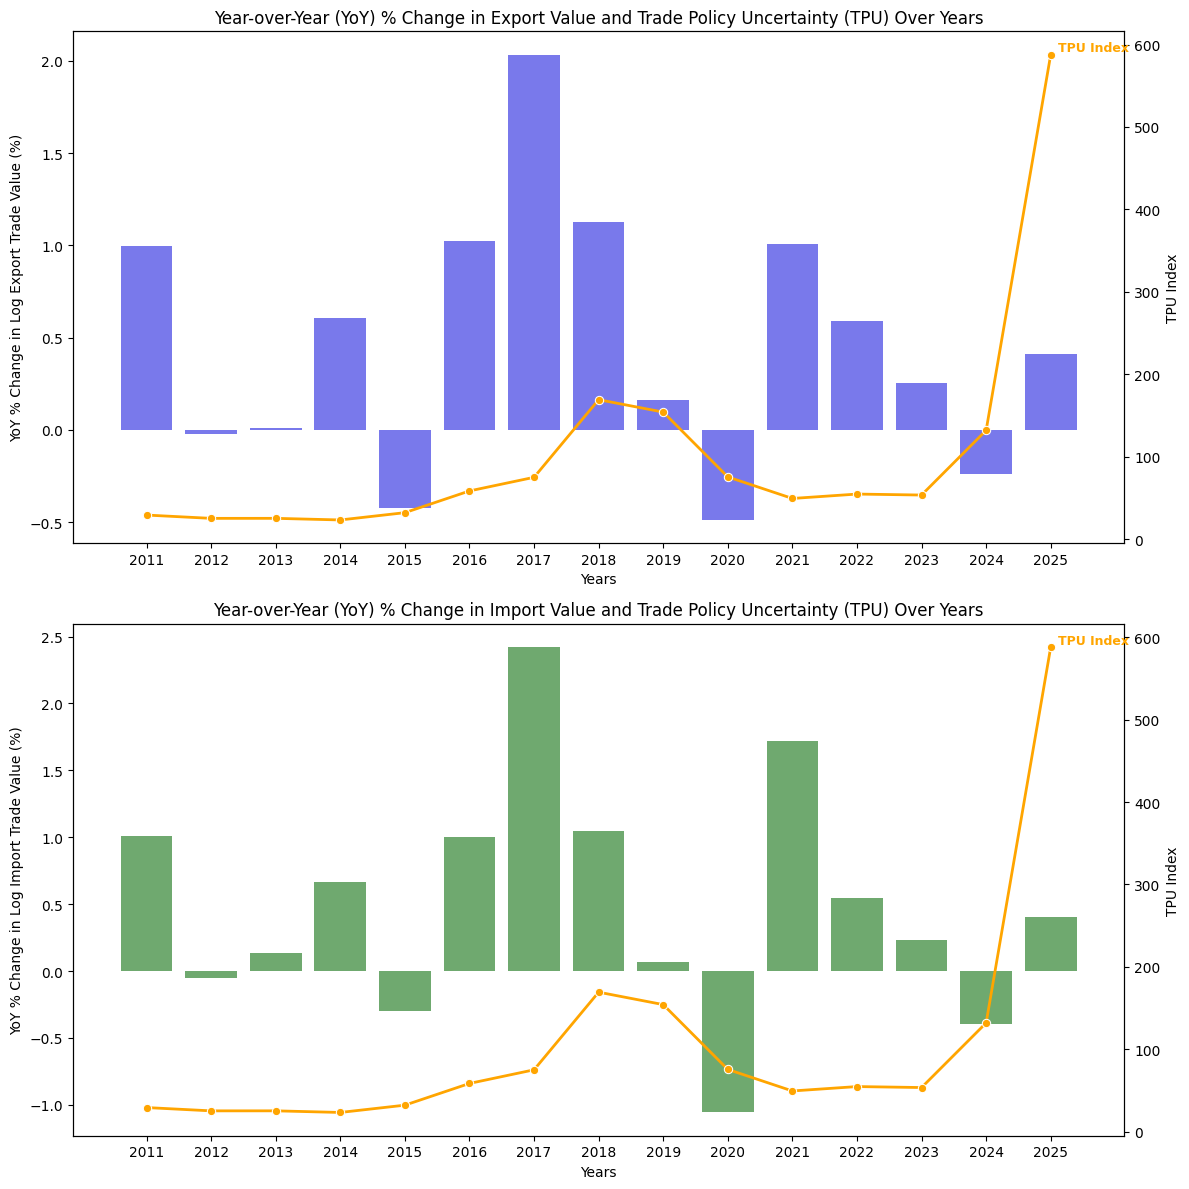

In [31]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

#sort exports and imports data by year

tpu_exports["Years"] = tpu_exports["date_x"].dt.year
tpu_imports["Years"] = tpu_imports["date_x"].dt.year

# Calculate YoY % change for exports
exports_yearly = tpu_exports.groupby('Years')['log_trade_value_usd'].mean()
exports_yoy = exports_yearly.pct_change() * 100

# Plot bars for YoY % change
years = exports_yoy.index[1:]  # Skip first NaN value
sns.barplot(x=years, y=exports_yoy.values[1:], ax=axs[0], color='blue', alpha=0.6)

# Create twin axis
axs2 = axs[0].twinx()

# Map the line plots to categorical positions
x_coords = np.arange(len(years))
tpu_values = tpu_exports.groupby('Years')['TPU'].mean()[1:]
sns.lineplot(x=x_coords, y=tpu_values.values, 
             ax=axs2, color='orange', marker='o', linewidth=2)

# Annotate lines directly
axs2.annotate('TPU Index', xy=(x_coords[-1], tpu_values.values[-1]), 
              xytext=(5, 5), textcoords='offset points',
              color='orange', fontweight='bold', va='center', ha='left', fontsize=9)

axs[0].set_title('Year-over-Year (YoY) % Change in Export Value and Trade Policy Uncertainty (TPU) Over Years')
axs[0].set_ylabel('YoY % Change in Log Export Trade Value (%)')
axs[0].set_xlabel('Years')
axs2.set_ylabel('TPU Index')

# Calculate YoY % change for imports
imports_yearly = tpu_imports.groupby('Years')['log_trade_value_usd'].mean()
imports_yoy = imports_yearly.pct_change() * 100

# Plot bars for YoY % change
years_imp = imports_yoy.index[1:]  # Skip first NaN value
sns.barplot(x=years_imp, y=imports_yoy.values[1:], ax=axs[1], color='green', alpha=0.6)

axs3 = axs[1].twinx()

# Apply the same coordinate mapping for imports
x_coords_imp = np.arange(len(years_imp))
tpu_values_imp = tpu_imports.groupby('Years')['TPU'].mean()[1:]
sns.lineplot(x=x_coords_imp, y=tpu_values_imp.values, 
             ax=axs3, color='orange', marker='o', linewidth=2)

# Annotate lines directly
axs3.annotate('TPU Index', xy=(x_coords[-1], tpu_values_imp.values[-1]), 
              xytext=(5, 5), textcoords='offset points',
              color='orange', fontweight='bold', va='center', ha='left', fontsize=9)

axs[1].set_title('Year-over-Year (YoY) % Change in Import Value and Trade Policy Uncertainty (TPU) Over Years')
axs[1].set_ylabel('YoY % Change in Log Import Trade Value (%)')
axs3.set_ylabel('TPU Index')
axs[1].set_xlabel('Years')



plt.tight_layout()
plt.show();

*Figure 1: Year-over-Year (YoY) % Change in Export Value and Import Value with Trade Policy Uncertainty (TPU) Over Years*

The 2018 TPU spike corresponded to a growth in trade value but declines 1-2 years later, likely corresponding to a strong delay in TPU shocks. In the medium-long run, trade grows again, likely as firms acclimatise to the new trade environment and adjust their strategies accordingly.

To enhance this comparison, I divide up the regions by US exposure to create a time-series plot of trade flows.


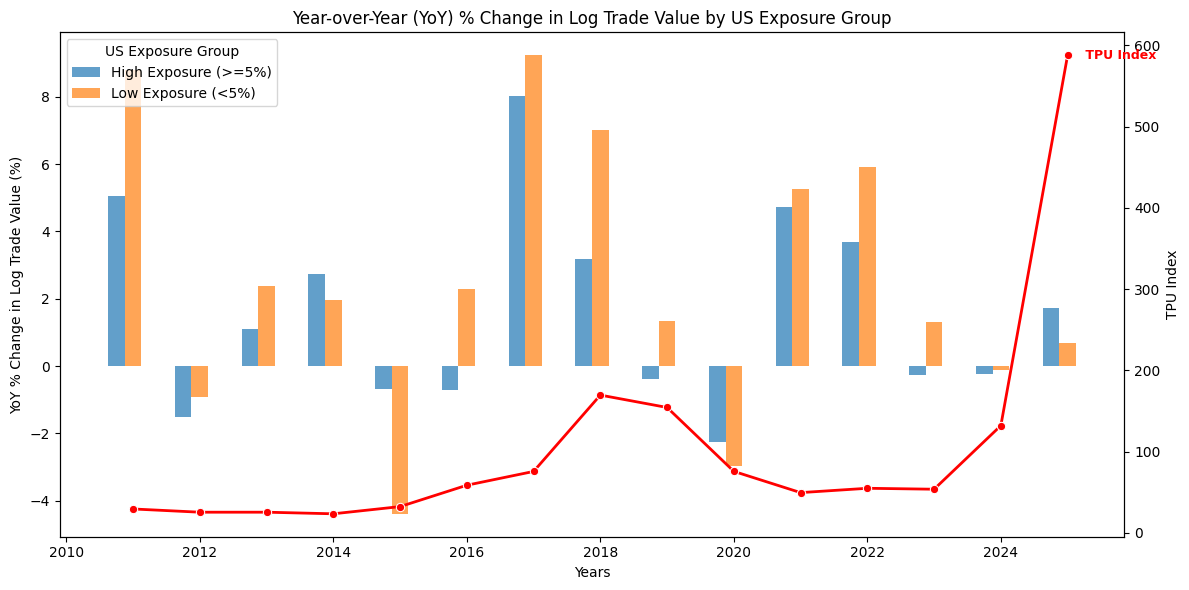

In [32]:
#recreate plot but divide up trade by US exposure groupings (5% threshold)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Create exposure groups based on 5% threshold (same as used in cell 28)
exposure_groups = [
    ('High Exposure (>=5%)', merged_full_data[merged_full_data['us_exposure_2013'] >= 0.05]),
    ('Low Exposure (<5%)', merged_full_data[merged_full_data['us_exposure_2013'] < 0.05])
]

for i, (group_name, group_data) in enumerate(exposure_groups):
    # Calculate yearly averages
    yearly_trade = group_data.groupby('Year')['Trade Value (Billions USD)'].mean()
    yearly_tpu = group_data.groupby('Year')['Trade Policy Uncertainty Index'].mean()
    
    # Apply arcsinh transformation and calculate YoY % change
    trade_arcsinh = np.arcsinh(yearly_trade)
    trade_yoy = trade_arcsinh.pct_change() * 100
    
    x_pos = trade_yoy.index[1:] + (i - 1) * 0.25  # Offset for bar positions
    
    # Plot trade YoY % change
    ax.bar(x_pos, trade_yoy.values[1:], width=0.25, label=group_name, alpha=0.7)
    
# Plot TPU line
years = trade_yoy.index[1:]
ax2 = ax.twinx()
sns.lineplot(x=years, y=yearly_tpu.values[1:], 
             ax=ax2, color='red', marker='o', linewidth=2)
ax2.text(years[-1] + 0.2, yearly_tpu.values[-1], ' TPU Index',
            color='red', fontweight='bold', va='center', ha='left', fontsize=9)
ax.set_title('Year-over-Year (YoY) % Change in Log Trade Value by US Exposure Group')
ax.set_ylabel('YoY % Change in Log Trade Value (%)')
ax.set_xlabel('Years')
ax2.set_ylabel('TPU Index')

ax.legend(title='US Exposure Group', loc='upper left')
# Show plot
plt.tight_layout()
plt.show();

*Figure 2: Year-over-Year (YoY) % Change in Trade versus Trade Policy Uncertainty (TPU) Divided by Level of US Involvement*

There is a noticeable time-lag associated with trade but US-exposed countries see an earlier and more significant decline compared to non-US-exposed countries: US-exposed trade, for example, more than halved from 2017-2018 and went negative only a year later, which is earlier and at a greater magnitude than the non-US group.



I next consider a plot to visualise TPU against log Trade Value. I do this using a scatter plot with a fitted line to visualise the correlation between TPU and trade value. Policy uncertainty impacts real economic variables with a lag, so I lag TPU variables at 0, 12, and 24 months to test that.

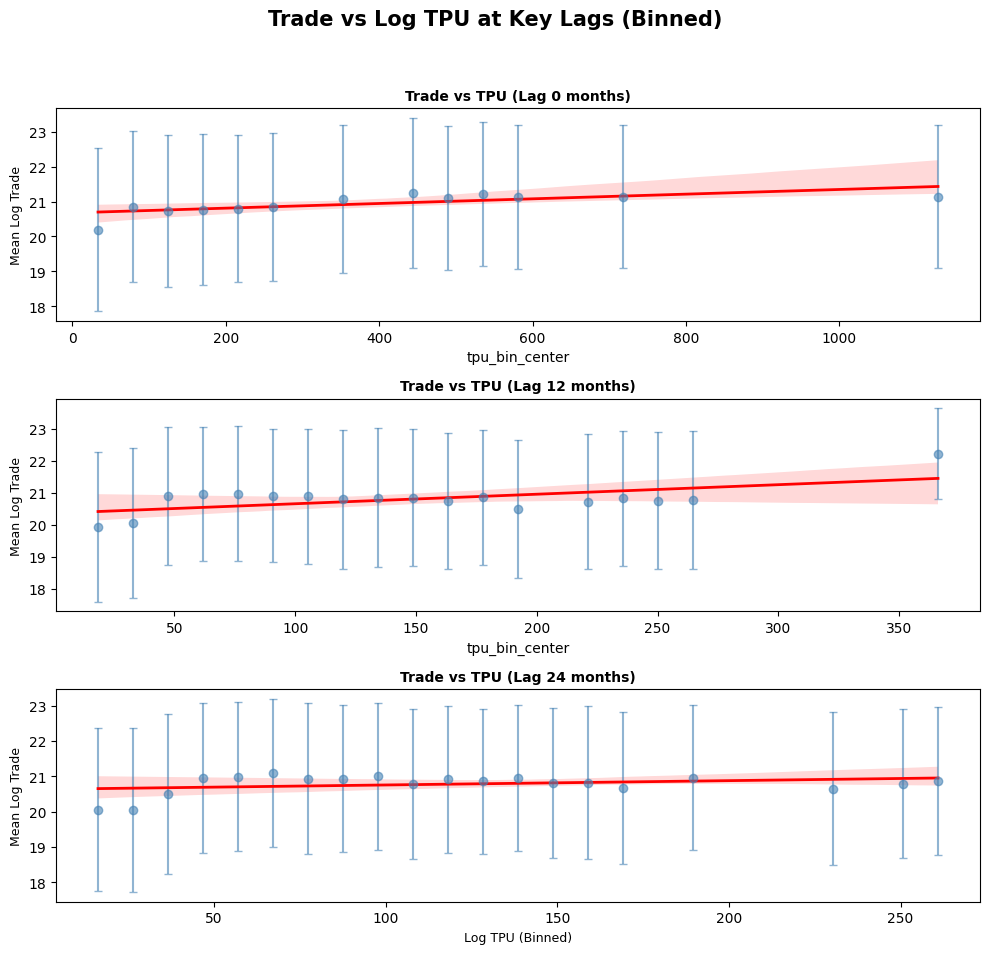

In [33]:
tpu_exports_sorted = tpu_exports.sort_index()
tpu_imports_sorted = tpu_imports.sort_index()

# Create year-month for grouping
tpu_exports_sorted['year_month'] = tpu_exports_sorted.index
tpu_imports_sorted['year_month'] = tpu_imports_sorted.index

# Group by country pair and shift
for df in [tpu_exports_sorted, tpu_imports_sorted]:
    df['TPU_lag_0'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x)
    df['TPU_lag_6m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(6))
    df['TPU_lag_12m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(12))
    df['TPU_lag_18m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(18))
    df['TPU_lag_24m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(24))

# Create 3x1 subplot for trade at key lags
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle('Trade vs Log TPU at Key Lags (Binned)', 
             fontsize=15, fontweight='bold', y=0.98)

# Define the 3 key lags for trade
trade_lag_periods = [('TPU_lag_0', '0 months'), ('TPU_lag_12m', '12 months'), ('TPU_lag_24m', '24 months')]

# --- TRADE PLOTS ---
for idx, (lag_col, lag_label) in enumerate(trade_lag_periods):
    exp_mask = tpu_exports_sorted[lag_col].notna() & tpu_exports_sorted['log_trade_value_usd'].notna()
    imp_mask = tpu_imports_sorted[lag_col].notna() & tpu_imports_sorted['log_trade_value_usd'].notna()
    
    combined = pd.concat([
        tpu_exports_sorted.loc[exp_mask, [lag_col, 'log_trade_value_usd']],
        tpu_imports_sorted.loc[imp_mask, [lag_col, 'log_trade_value_usd']]
    ]).rename(columns={'log_trade_value_usd': 'trade_value'})
    
    combined['tpu_bin'] = pd.cut(combined[lag_col], bins=25)
    combined['tpu_bin_center'] = combined['tpu_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)
    
    binned = combined.groupby('tpu_bin_center', observed=True).agg({
        'trade_value': ['mean', 'std']
    }).reset_index()
    binned.columns = ['tpu_bin_center', 'trade_mean', 'trade_std']
    binned = binned.dropna()
    
    axs[idx].errorbar(binned['tpu_bin_center'], binned['trade_mean'], 
                         yerr=binned['trade_std'], fmt='o', alpha=0.6, capsize=3, 
                         markersize=6, color='steelblue')
    sns.regplot(x=binned['tpu_bin_center'], y=binned['trade_mean'], ax=axs[idx], 
                scatter=False, color='red', line_kws={'linewidth': 2})

    axs[idx].set_title(f'Trade vs TPU (Lag {lag_label})', fontsize=10, fontweight='bold')
    axs[idx].set_ylabel('Mean Log Trade', fontsize=9)
    if idx == 2: axs[idx].set_xlabel('Log TPU (Binned)', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show(); # Semicolon suppresses technical object text

*Figure 3: Trade Policy Uncertainty (TPU) versus Standard Deviation from Mean of Trade Values*

Trade correlation with TPU starts positive and correlated in the first 12 months, but becomes near-flat by month 24. Thus, we see that trade spikes immediately as TPU rises but goes negative as more time passes post-shock, supporting the interpretation of a delayed TPU reaction.


I next consider the relationship between business confidence and trade policy uncertainty. To do this, I create a time-series plot to compare the progression of BCI and TPU over time. I also plot trade with BCI to visualise the relationship between business confidence and trade flows.

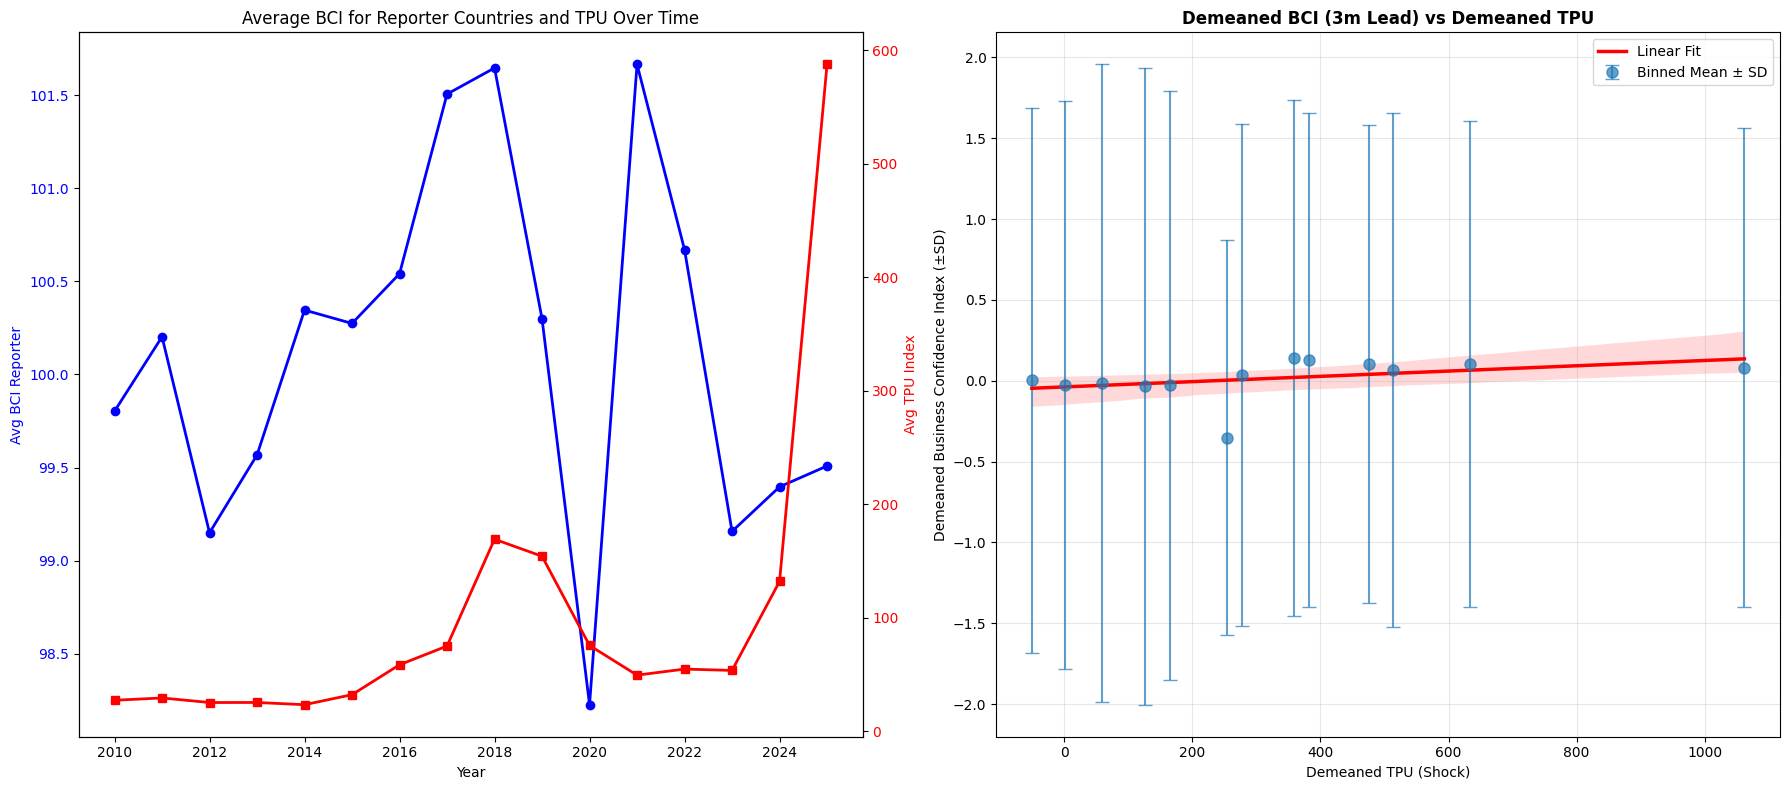

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# LEFT PLOT: BCI and TPU over time
bci_reporter = tpu_exports.groupby('Years')['bci_reporter'].mean()
ax1_left = ax1
ax1_left.plot(bci_reporter.index, bci_reporter.values, color='blue', linewidth=2, marker='o', label='Avg BCI Reporter')
ax1_left.set_xlabel('Year')
ax1_left.set_ylabel('Avg BCI Reporter', color='blue')
ax1_left.tick_params(axis='y', labelcolor='blue')

ax1_right = ax1.twinx()
tpu_avg = tpu_exports.groupby('Years')['TPU'].mean()
ax1_right.plot(tpu_avg.index, tpu_avg.values, color='red', linewidth=2, marker='s', label='Avg TPU Index')
ax1_right.set_ylabel('Avg TPU Index', color='red')
ax1_right.tick_params(axis='y', labelcolor='red')
ax1.set_title('Average BCI for Reporter Countries and TPU Over Time')

# --- RIGHT PLOT: Demeaned BCI vs Demeaned TPU (Monthly Resolution) ---
# We use the tpu_exports dataframe to keep consistency
trade_lag = tpu_exports.copy()

# Shift BCI forward by 3 months to see if TPU today predicts confidence 3 months out
# (Since trade is monthly, a 3-month lead/lag is more standard than the FDI 2-year lag)
trade_lag['bci_lead'] = trade_lag.groupby(['iso3reporter', 'iso3partner'])['bci_reporter'].shift(-3)

# Demeaning to isolate the "Shock" variation
trade_lag['bci_demeaned'] = trade_lag['bci_lead'] - trade_lag['bci_lead'].mean()
trade_lag['tpu_demeaned'] = trade_lag['TPU'] - trade_lag['TPU'].mean()

# Binning the TPU shock into 20 buckets for visualization
trade_lag['tpu_bin'] = pd.cut(trade_lag['tpu_demeaned'], bins=20)
binned_data = trade_lag.groupby('tpu_bin', observed=True).agg({
    'tpu_demeaned': 'mean',
    'bci_demeaned': ['mean', 'std', 'count']
}).reset_index()

binned_data.columns = ['tpu_bin', 'tpu_demeaned_mean', 'bci_demeaned_mean', 'bci_demeaned_std', 'count']
binned_data = binned_data.dropna()

# Plotting the relationship
ax2.errorbar(binned_data['tpu_demeaned_mean'], binned_data['bci_demeaned_mean'], 
             yerr=binned_data['bci_demeaned_std'], fmt='o', alpha=0.7, capsize=5, markersize=8, label='Binned Mean ± SD')

sns.regplot(x=binned_data['tpu_demeaned_mean'], y=binned_data['bci_demeaned_mean'],
            scatter=False, color='red', line_kws={'linewidth': 2.5}, ax=ax2, label='Linear Fit')

ax2.set_title('Demeaned BCI (3m Lead) vs Demeaned TPU', fontweight='bold')
ax2.set_xlabel('Demeaned TPU (Shock)')
ax2.set_ylabel('Demeaned Business Confidence Index (±SD)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


*Figure 4: Business Confidence Index (BCI) versus Log Trade Policy Uncertainty (TPU) Over Years*


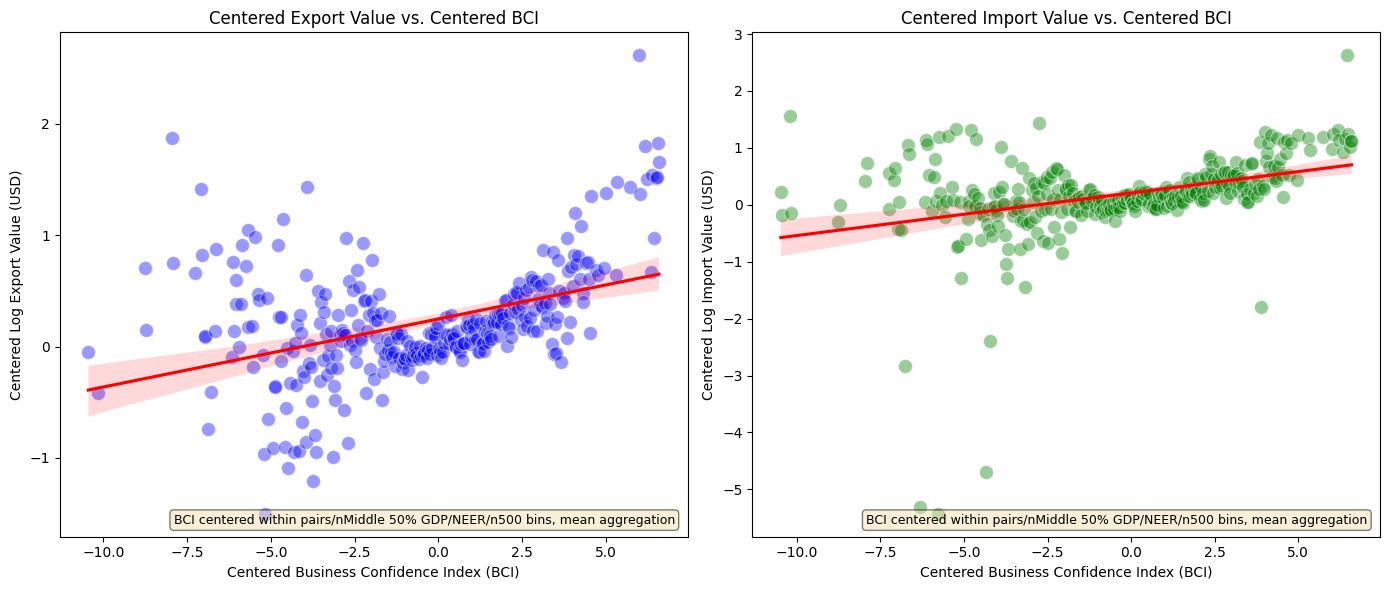

In [35]:
# 1. Clean and Prepare Trade Data
trade_cols = ['bci_reporter', 'log_trade_value_usd', 'iso3reporter', 'iso3partner']

tpu_exports_clean = tpu_exports.dropna(subset=trade_cols).copy()
tpu_imports_clean = tpu_imports.dropna(subset=trade_cols).copy()

tpu_exports_clean = tpu_exports_clean.sort_index()
tpu_imports_clean = tpu_imports_clean.sort_index()

# 2. Within-pair centering (Fixed Effects proxy)
for df in [tpu_exports_clean, tpu_imports_clean]:
    df['bci_centered'] = df['bci_reporter'] - df.groupby(['iso3reporter', 'iso3partner'])['bci_reporter'].transform('mean')
    df['trade_centered'] = df['log_trade_value_usd'] - df.groupby(['iso3reporter', 'iso3partner'])['log_trade_value_usd'].transform('mean')

# Drop rows created by centering/missing values
tpu_exports_clean = tpu_exports_clean.dropna(subset=['bci_centered', 'trade_centered'])
tpu_imports_clean = tpu_imports_clean.dropna(subset=['bci_centered', 'trade_centered'])

# 3. Control Filters (GDP/NEER via middle-50% binning)
def middle_slice(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return (series >= q1) & (series <= q3)

for df in [tpu_exports_clean, tpu_imports_clean]:
    df['gdp_mean'] = (df['ln_gdp_reporter'] + df['ln_gdp_partner']) / 2
    df['neer_mean'] = (df['neer_reporter'] + df['neer_partner']) / 2

tpu_exports_ctrl = tpu_exports_clean.dropna(subset=['gdp_mean', 'neer_mean'])
tpu_imports_ctrl = tpu_imports_clean.dropna(subset=['gdp_mean', 'neer_mean'])

tpu_exports_ctrl = tpu_exports_ctrl[middle_slice(tpu_exports_ctrl['gdp_mean']) & middle_slice(tpu_exports_ctrl['neer_mean'])]
tpu_imports_ctrl = tpu_imports_ctrl[middle_slice(tpu_imports_ctrl['gdp_mean']) & middle_slice(tpu_imports_ctrl['neer_mean'])]

# 4. Binning for Visualization (Binscatter approach)
bins = 500
tpu_exports_ctrl['bci_binned'] = pd.cut(tpu_exports_ctrl['bci_centered'], bins=bins)
tpu_imports_ctrl['bci_binned'] = pd.cut(tpu_imports_ctrl['bci_centered'], bins=bins)

binned_exports_bci = tpu_exports_ctrl.groupby('bci_binned', observed=True).agg({'bci_centered': 'mean', 'trade_centered': 'mean'}).reset_index()
binned_imports_bci = tpu_imports_ctrl.groupby('bci_binned', observed=True).agg({'bci_centered': 'mean', 'trade_centered': 'mean'}).reset_index()

# 5. Plotting (2-Panel Layout)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Exports
sns.scatterplot(data=binned_exports_bci, x='bci_centered', y='trade_centered', ax=axs[0], color='blue', s=100, alpha=0.4)
sns.regplot(data=binned_exports_bci, x='bci_centered', y='trade_centered', ax=axs[0], scatter=False, color='red')
axs[0].set_title('Centered Export Value vs. Centered BCI')
axs[0].set_xlabel('Centered Business Confidence Index (BCI)')
axs[0].set_ylabel('Centered Log Export Value (USD)')
axs[0].text(0.98, 0.02, 'BCI centered within pairs/nMiddle 50% GDP/NEER/n500 bins, mean aggregation',
            transform=axs[0].transAxes, fontsize=9, verticalalignment='bottom',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 2: Imports
sns.scatterplot(data=binned_imports_bci, x='bci_centered', y='trade_centered', ax=axs[1], color='green', s=100, alpha=0.4)
sns.regplot(data=binned_imports_bci, x='bci_centered', y='trade_centered', ax=axs[1], scatter=False, color='red')
axs[1].set_title('Centered Import Value vs. Centered BCI')
axs[1].set_xlabel('Centered Business Confidence Index (BCI)')
axs[1].set_ylabel('Centered Log Import Value (USD)')
axs[1].text(0.98, 0.02, 'BCI centered within pairs/nMiddle 50% GDP/NEER/n500 bins, mean aggregation',
            transform=axs[1].transAxes, fontsize=9, verticalalignment='bottom',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show();

*Figure 5: Business Confidence Index (BCI) versus Standard Deviation from Mean of Trade Values*

We see a strong positive correlation between BCI and trade values, confirming that business confidence plays a role in trade behaviour. The correlation between BCI and TPU, however, seems to be positive or insignificant, which is surprising. I formally test this using a mediation analysis in the next section, but this suggests that business confidence cannot fully explain the relationship between TPU and trade, and that other mechanisms may be at play, aligning with Amiti, Redding, and Weinstein (2020).

# **Project 2**

## 2.1 The Message

The 2018 US trade policy uncertainty shock caused longer-run general trend of trade stagnation post-2018, affecting US-exposed traders more than non-US-exposed ones.

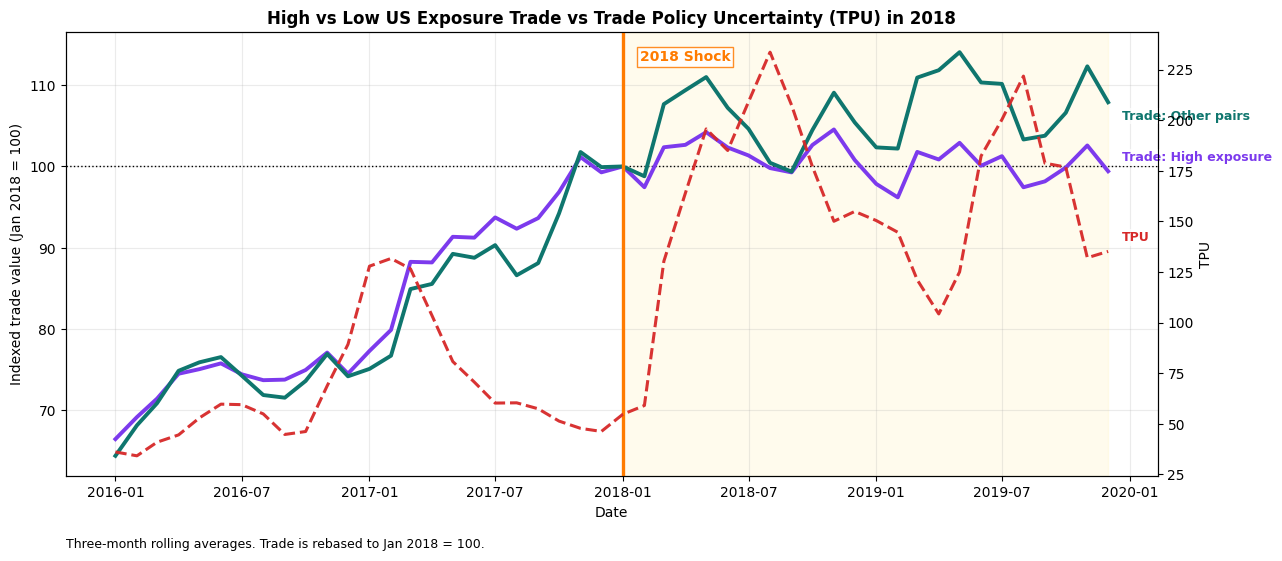

In [36]:
# Single main figure: high vs low US exposure trade with one global TPU line

tpu_exports.reset_index(inplace=True)
tpu_imports.reset_index(inplace=True)

plot_start = pd.Timestamp('2016-01-01')
plot_end = pd.Timestamp('2019-12-01')
shock_date = pd.Timestamp('2018-01-01')

exports_plot = tpu_exports.loc[(tpu_exports["date_x"] >= plot_start) & (tpu_exports["date_x"] <= plot_end)].copy()
imports_plot = tpu_imports.loc[(tpu_imports["date_x"] >= plot_start) & (tpu_imports["date_x"] <= plot_end)].copy()

def rebase_to_date(series, base_date):
    return series.div(series.loc[base_date]).mul(100)

def annotate_last(ax, x, y, text, color, x_offset=10, y_offset=0):
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        color=color,
        fontsize=9,
        fontweight='bold',
        va='center',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2)
    )

date_col = 'DATE' if 'DATE' in exports_plot.columns else 'date_x'

# Build global TPU series (same regardless of exposure group), smoothed
macro_monthly = (
    pd.concat(
        [
            exports_plot[[date_col, 'iso3reporter', 'TPU']].drop_duplicates([date_col, 'iso3reporter']),
            imports_plot[[date_col, 'iso3reporter', 'TPU']].drop_duplicates([date_col, 'iso3reporter'])
        ],
        ignore_index=True
    )
    .drop_duplicates([date_col, 'iso3reporter'])
    .groupby(date_col)
    .agg(avg_tpu=('TPU', 'mean'))
    .sort_index()
    .rolling(3, min_periods=1).mean()
 )

# Build exposure-group aggregate trade series, smoothed and rebased
combined_trade = pd.concat(
    [
        exports_plot[[date_col, 'trade_value_usd', 'us_exposure']].assign(flow='Exports'),
        imports_plot[[date_col, 'trade_value_usd', 'us_exposure']].assign(flow='Imports')
    ],
    ignore_index=True
 )
combined_trade['exposure_group'] = np.where(
    combined_trade['us_exposure'] > 0.05,
    'High US exposure (> 5%)',
    'Other pairs (<= 5%)'
 )

exposure_grouped = (
    combined_trade
    .groupby([date_col, 'exposure_group'])
    .agg(total_trade=('trade_value_usd', 'sum'))
    .reset_index()
    .sort_values(['exposure_group', date_col])
 )
exposure_grouped['trade_3m'] = exposure_grouped.groupby('exposure_group')['total_trade'].transform(
    lambda series: series.rolling(3, min_periods=1).mean()
 )

group_order = ['High US exposure (> 5%)', 'Other pairs (<= 5%)']
trade_colors = {
    'High US exposure (> 5%)': '#7c3aed',
    'Other pairs (<= 5%)': '#0f766e'
}

fig, ax_exposure = plt.subplots(figsize=(13, 6))
ax_exposure.axvspan(shock_date, plot_end, color='#fff3bf', alpha=0.28)
ax_exposure.axvline(shock_date, color='#ff7b00', linestyle='-', linewidth=2.4, zorder=3)
ax_exposure.axhline(100, color='black', linestyle=':', linewidth=1)
ax_exposure.grid(True, alpha=0.25)

ax_exposure_right = ax_exposure.twinx()

for group_name in group_order:
    group_data = exposure_grouped[exposure_grouped['exposure_group'] == group_name].copy()
    group_trade_indexed = rebase_to_date(group_data.set_index(date_col)['trade_3m'], shock_date)

    ax_exposure.plot(
        group_trade_indexed.index,
        group_trade_indexed.values,
        color=trade_colors[group_name],
        linewidth=2.8
    )

    trade_label = 'Trade: High exposure' if 'High' in group_name else 'Trade: Other pairs'
    trade_offset = 10 if 'High' in group_name else -10
    annotate_last(
        ax_exposure,
        group_trade_indexed.index[-1],
        group_trade_indexed.iloc[-1],
        trade_label,
        trade_colors[group_name],
        y_offset=trade_offset
    )

ax_exposure_right.plot(
    macro_monthly.index,
    macro_monthly['avg_tpu'],
    color='#d62828',
    linewidth=2.2,
    linestyle='--',
    alpha=0.95
 )
annotate_last(
    ax_exposure_right,
    macro_monthly.index[-1],
    macro_monthly['avg_tpu'].iloc[-1],
    'TPU',
    '#d62828',
    y_offset=10
 )

ax_exposure.annotate(
    '2018 Shock',
    xy=(shock_date, ax_exposure.get_ylim()[1] - 0.8),
    xytext=(12, -16),
    textcoords='offset points',
    color='#ff7b00',
    fontsize=10,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='#ff7b00', pad=2)
 )

ax_exposure.set_title('High vs Low US Exposure Trade vs Trade Policy Uncertainty (TPU) in 2018', fontweight='bold')
ax_exposure.set_ylabel('Indexed trade value (Jan 2018 = 100)')
ax_exposure_right.set_ylabel('TPU')
ax_exposure.set_xlabel('Date')

fig.text(
    0.08,
    0.04,
    'Three-month rolling averages. Trade is rebased to Jan 2018 = 100.',
    fontsize=9
 )

fig.subplots_adjust(top=0.90, bottom=0.16, left=0.08, right=0.92)
plt.show()

*Figure 6: Monthly Year-over-Year (YoY) % Change in Trade and Trade Policy Uncertainty (TPU) Divided by Level of US InvolvementMonthly Year-over-Year (YoY) % Change in Trade and Trade Policy Uncertainty (TPU) Divided by Level of US Involvement*

We see that aggregate trade stagnates post-2018 compared to a strong positive growth pre-shock. This effect is more pronounced for US-exposed traders, which see a stronger trend than their non-exposed counterparts. The implication is that US-trade policy uncertainty shocks have strong spillovers on global trade, but that the effect is much stronger for those who are reliant on the US as a trading partner.

# 2.2 Maps and Interpretation

I present several maps to visualise the geographical distribution of trade changes post-2018, with a focus on US-exposure. 

First, I use a heat map to visualise the concentration of trade across the dataset.

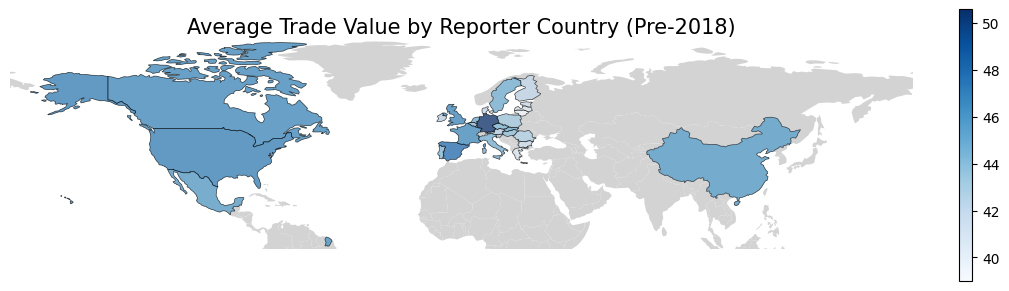

In [37]:
world = gpd.read_file("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/ne_110m_admin_0_countries.shp")
map_key = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'



#create a map of averaged import and exports by country to visualize overall trade patterns
#we want each unique country to only appear once, so we aggregate by reporter country first, then merge with shapefile
trade_agg_exports = tpu_exports.groupby('iso3reporter')['trade_value_usd'].mean().reset_index()
trade_agg_imports = tpu_imports.groupby('iso3reporter')['trade_value_usd'].mean().reset_index()

#log transform for better visualization
trade_agg_exports['trade_value_usd'] = np.log(trade_agg_exports['trade_value_usd'].clip(lower=1e-9))
trade_agg_imports['trade_value_usd'] = np.log(trade_agg_imports['trade_value_usd'].clip(lower=1e-9))

trade_agg_total = trade_agg_exports.merge(trade_agg_imports, on='iso3reporter', how='outer', suffixes=('_exports', '_imports'))
trade_agg_total['trade_value_total'] = trade_agg_total[['trade_value_usd_exports', 'trade_value_usd_imports']].sum(axis=1)
trade_agg_total = trade_agg_total.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
trade_agg_total = trade_agg_total[trade_agg_total['geometry'].notna()].copy()
gdf_trade = gpd.GeoDataFrame(trade_agg_total, geometry='geometry')

# Use the same south cutoff as the exposure map cell (south of Malaysia removed)
south_cutoff_lat = 1.0
cropped_world = world[world.geometry.bounds.maxy >= south_cutoff_lat].copy()
xmin, ymin, xmax, ymax = cropped_world.total_bounds
ymin = max(ymin, south_cutoff_lat)

# Match figure size to map bounds to minimize excess white space
map_ratio = (xmax - xmin) / (ymax - ymin)
fig_width = 10
fig_height = max(2.8, fig_width / map_ratio)
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), constrained_layout=True)

cropped_world.plot(ax=ax, color='lightgray')
gdf_trade_valid = gdf_trade[gdf_trade['trade_value_total'].notna()]
gdf_trade_valid.plot(ax=ax, column='trade_value_total', cmap='Blues', legend=True, alpha=0.7, edgecolor='k', linewidth=0.5)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.margins(0)
ax.set_title('Average Trade Value by Reporter Country (Pre-2018)', fontsize=15)
ax.set_axis_off()
plt.show()

We see that the dataset is heavily concentrated in the EU. The implication, however, is that several large US partners, such as Japan, are not represented in the dataset. However, the inclusion other major traders, such as the UK and Canada, ensures that the results are still relatively representative of a variety of US-exposure levels.

We next consider the spread of US-exposures across the dataset.

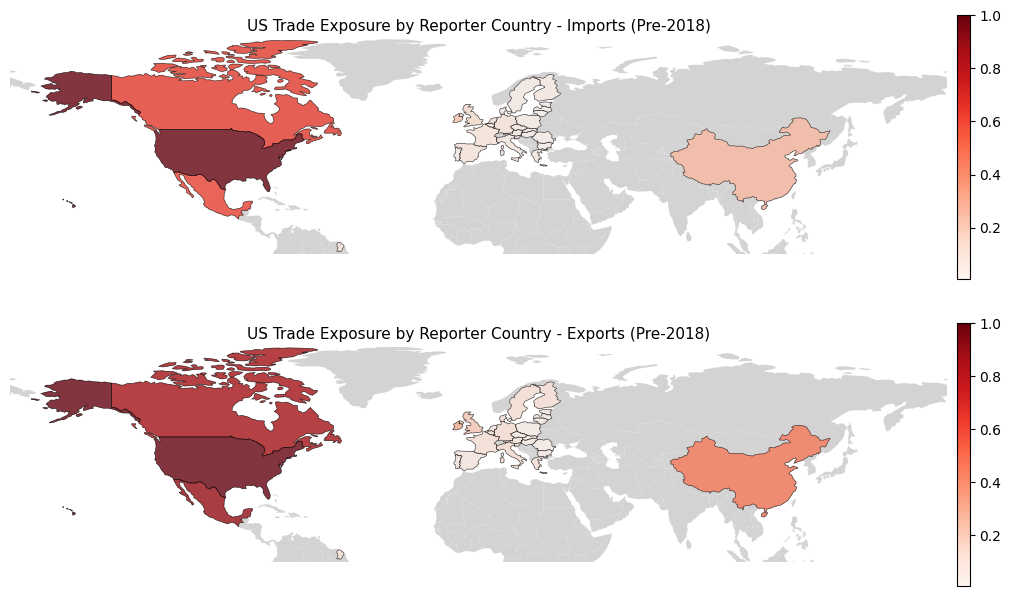

In [38]:
# Map of US exposure for reporter countries using imports and exports (pre-2018)
date_col = 'DATE' if 'DATE' in tpu_imports.columns else 'date'

# ----- Imports exposure -----
map_data = tpu_imports.reset_index(drop=True).copy()
map_data[date_col] = pd.to_datetime(map_data[date_col], errors='coerce')
map_data = map_data[map_data[date_col].dt.year < 2018].copy()
map_data['us_trade_value'] = np.where(
    map_data['iso3partner'] == 'USA',
    map_data['trade_value_usd'],
    0
)

monthly = (
    map_data
    .groupby(['iso3reporter', date_col], as_index=False)
    .agg(
        reporter_total_trade=('trade_value_usd', 'sum'),
        us_trade_reporter=('us_trade_value', 'sum')
    )
)

imports_map = (
    monthly
    .groupby('iso3reporter', as_index=False)
    .agg(
        reporter_total_trade=('reporter_total_trade', 'sum'),
        us_trade_reporter=('us_trade_reporter', 'sum')
    )
)

imports_map['us_exposure_ratio'] = (
    imports_map['us_trade_reporter'].abs() / imports_map['reporter_total_trade'].abs()
)
imports_map.loc[imports_map['iso3reporter'] == 'USA', 'us_exposure_ratio'] = 1.0
imports_map = imports_map.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
imports_map = imports_map[imports_map['geometry'].notna()].copy()
gdf_imports = gpd.GeoDataFrame(imports_map, geometry='geometry')

# ----- Exports exposure -----
map_data_exports = tpu_exports.reset_index(drop=True).copy()
map_data_exports[date_col] = pd.to_datetime(map_data_exports[date_col], errors='coerce')
map_data_exports = map_data_exports[map_data_exports[date_col].dt.year < 2018].copy()
map_data_exports['us_trade_value'] = np.where(
    map_data_exports['iso3partner'] == 'USA',
    map_data_exports['trade_value_usd'],
    0
)

monthly_exports = (
    map_data_exports
    .groupby(['iso3reporter', date_col], as_index=False)
    .agg(
        reporter_total_trade=('trade_value_usd', 'sum'),
        us_trade_reporter=('us_trade_value', 'sum')
    )
)

exports_map = (
    monthly_exports
    .groupby('iso3reporter', as_index=False)
    .agg(
        reporter_total_trade=('reporter_total_trade', 'sum'),
        us_trade_reporter=('us_trade_reporter', 'sum')
    )
)

exports_map['us_exposure_ratio'] = (
    exports_map['us_trade_reporter'].abs() / exports_map['reporter_total_trade'].abs()
)
exports_map.loc[exports_map['iso3reporter'] == 'USA', 'us_exposure_ratio'] = 1.0
exports_map = exports_map.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
exports_map = exports_map[exports_map['geometry'].notna()].copy()
gdf_exports = gpd.GeoDataFrame(exports_map, geometry='geometry')

# Keep the same color scale across both maps for comparability
all_ratios = pd.concat([
    gdf_imports['us_exposure_ratio'],
    gdf_exports['us_exposure_ratio']
], ignore_index=True)
vmin, vmax = all_ratios.min(), all_ratios.max()

# Exclude everything south of Malaysia (~1 degree north) and tightly fit map frame
south_cutoff_lat = 1.0
cropped_world = world[world.geometry.bounds.maxy >= south_cutoff_lat].copy()
xmin, ymin, xmax, ymax = cropped_world.total_bounds
ymin = max(ymin, south_cutoff_lat)

map_ratio = (xmax - xmin) / (ymax - ymin)
fig_width = 10
single_height = max(3.0, fig_width / map_ratio)
fig, axes = plt.subplots(2, 1, figsize=(fig_width, single_height * 2.05), constrained_layout=True)

def draw_on_ax(ax, gdf, title):
    cropped_world.plot(ax=ax, color='lightgray')
    gdf_valid = gdf[gdf['us_exposure_ratio'].notna()]
    gdf_valid.plot(
        ax=ax,
        column='us_exposure_ratio',
        cmap='Reds',
        legend=True,
        legend_kwds={'shrink': 0.88, 'pad': 0.01},
        alpha=0.75,
        edgecolor='k',
        linewidth=0.45,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    ax.margins(0)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

draw_on_ax(axes[0], gdf_imports, 'US Trade Exposure by Reporter Country - Imports (Pre-2018)')
draw_on_ax(axes[1], gdf_exports, 'US Trade Exposure by Reporter Country - Exports (Pre-2018)')

plt.show()

Canada and Mexico are the most US-exposed trading partners. Exports tends to see higher levels of US-exposure than imports, which may be due to the strength of the US dollar and its influence as a global export market for many countries. We thus expect exports to be more sensitive to US trade policy uncertainty shocks than imports.

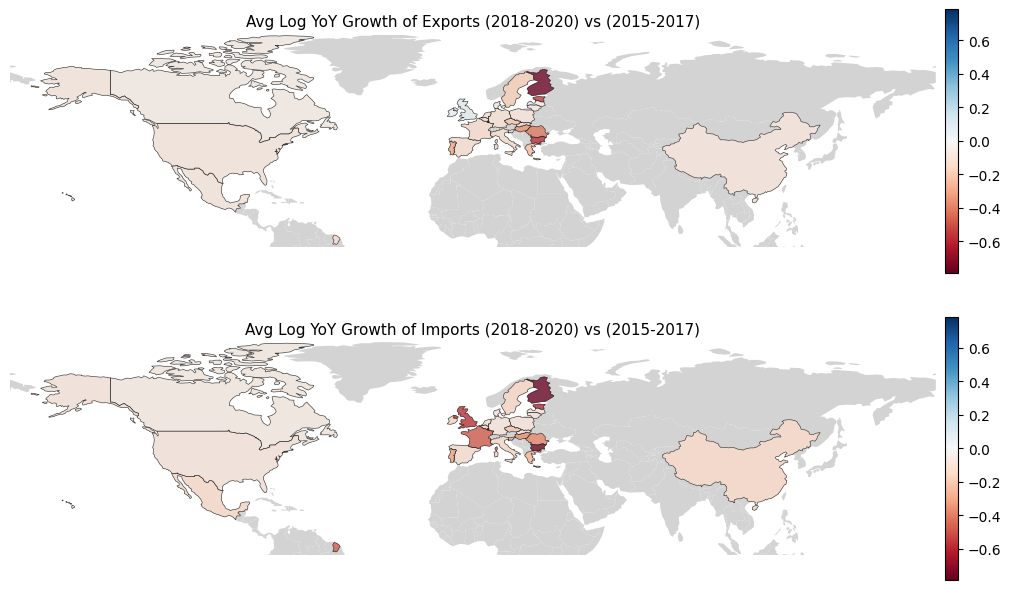

In [39]:
# YoY Growth Rate Analysis: Compare growth trajectory pre-2018 vs post-2018
world = gpd.read_file("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/ne_110m_admin_0_countries.shp")
map_key = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
date_col = 'DATE' if 'DATE' in tpu_exports.columns else 'date'

# Ensure date columns are datetime
tpu_exports = tpu_exports.copy()
tpu_imports = tpu_imports.copy()
tpu_exports[date_col] = pd.to_datetime(tpu_exports[date_col])
tpu_imports[date_col] = pd.to_datetime(tpu_imports[date_col])

tpu_exports['Year'] = tpu_exports[date_col].dt.year
tpu_imports['Year'] = tpu_imports[date_col].dt.year

# Function to calculate average YoY growth rate for a period
def calc_yoy_growth(df, years):
    """Calculate average year-over-year growth rate for given years"""
    df_sub = df[df['Year'].isin(years)].copy()

    # Get yearly averages
    yearly = df_sub.groupby(['iso3reporter', 'Year'], as_index=False)['trade_value_usd'].mean()

    # Calculate YoY growth rates
    yearly['log_trade'] = np.log(yearly['trade_value_usd'].clip(lower=1e-9))
    yearly['log_yoy_growth'] = yearly.groupby('iso3reporter')['log_trade'].diff()

    # Average YoY growth within period (exclude first year which has NaN)
    avg_growth = yearly[yearly['log_yoy_growth'].notna()].groupby('iso3reporter')['log_yoy_growth'].mean().reset_index()
    avg_growth.columns = ['iso3reporter', 'avg_yoy_growth']

    return avg_growth

# Calculate pre-2018 growth (2015-2017)
pre_years = [2015, 2016, 2017]
exports_pre_growth = calc_yoy_growth(tpu_exports, pre_years)
imports_pre_growth = calc_yoy_growth(tpu_imports, pre_years)

# Calculate post-2018 growth (2018-2020)
post_years = [2018, 2019, 2020]
exports_post_growth = calc_yoy_growth(tpu_exports, post_years)
imports_post_growth = calc_yoy_growth(tpu_imports, post_years)

# Merge and calculate growth rate change for exports
exports_growth = exports_pre_growth.merge(exports_post_growth, on='iso3reporter', how='inner', suffixes=('_pre', '_post'))
exports_growth['growth_deceleration'] = np.log(exports_growth['avg_yoy_growth_post'] + 1) - np.log(exports_growth['avg_yoy_growth_pre'] + 1)
exports_growth = exports_growth.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
exports_growth = exports_growth[exports_growth['geometry'].notna()].copy()
gdf_exports_growth = gpd.GeoDataFrame(exports_growth, geometry='geometry')

# Merge and calculate growth rate change for imports
imports_growth = imports_pre_growth.merge(imports_post_growth, on='iso3reporter', how='inner', suffixes=('_pre', '_post'))
imports_growth['growth_deceleration'] = np.log(imports_growth['avg_yoy_growth_post'] + 1) - np.log(imports_growth['avg_yoy_growth_pre'] + 1)
imports_growth = imports_growth.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
imports_growth = imports_growth[imports_growth['geometry'].notna()].copy()
gdf_imports_growth = gpd.GeoDataFrame(imports_growth, geometry='geometry')

# Use the same map design as Cell 55: crop south of Malaysia and fit bounds
south_cutoff_lat = 1.0
cropped_world = world[world.geometry.bounds.maxy >= south_cutoff_lat].copy()
xmin, ymin, xmax, ymax = cropped_world.total_bounds
ymin = max(ymin, south_cutoff_lat)

# Shared symmetric color scale across both maps for comparability
all_growth = pd.concat([
    gdf_exports_growth['growth_deceleration'],
    gdf_imports_growth['growth_deceleration']
], ignore_index=True).dropna()

abs_cap = np.nanpercentile(np.abs(all_growth), 95) if len(all_growth) > 0 else np.nan
if not np.isfinite(abs_cap) or abs_cap == 0:
    abs_cap = 0.01

# Match figure geometry/formatting from Cell 55
map_ratio = (xmax - xmin) / (ymax - ymin)
fig_width = 10
single_height = max(3.0, fig_width / map_ratio)
fig, axes = plt.subplots(2, 1, figsize=(fig_width, single_height * 2.05), constrained_layout=True)

def draw_growth_map(ax, gdf, title):
    cropped_world.plot(ax=ax, color='lightgray')
    gdf_valid = gdf[gdf['growth_deceleration'].notna()]
    gdf_valid.plot(
        ax=ax,
        column='growth_deceleration',
        cmap='RdBu',
        legend=True,
        legend_kwds={'shrink': 0.88, 'pad': 0.01},
        vmin=-abs_cap,
        vmax=abs_cap,
        alpha=0.75,
        edgecolor='k',
        linewidth=0.45
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    ax.margins(0)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

draw_growth_map(axes[0], gdf_exports_growth, 'Avg Log YoY Growth of Exports (2018-2020) vs (2015-2017)')
draw_growth_map(axes[1], gdf_imports_growth, 'Avg Log YoY Growth of Imports (2018-2020) vs (2015-2017)')

plt.show()

I visualise the change in yearly trade growth post-2018 across the world compared to the pre-trend of 2014-2016 (2017 is excluded to avoid anticipation behaviour). We see that, in general, global trade growth decelerated post-2018, more so for exports. It is difficult to tell if US-exposed traders are more affected than non-US-exposed ones, so that will require formal testing.

Finally, in support of the mechanism of business confidence, I visualise the change in business confidence post-2018 across the world compared to the pre-trend of 2015-2017.

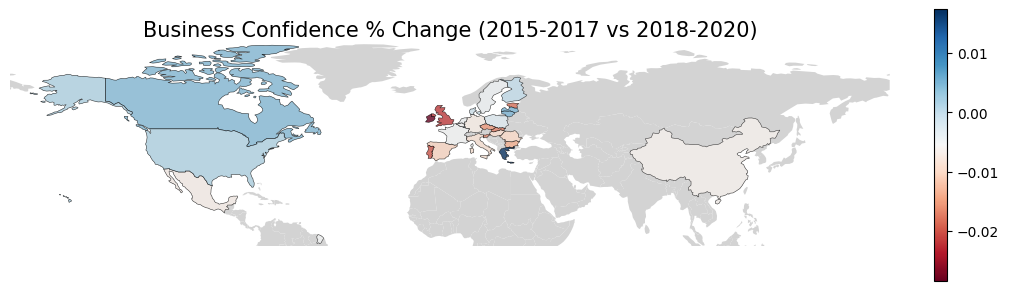

In [40]:
bci_panel = pd.concat(
    [
        tpu_exports.reset_index()[['DATE', 'iso3reporter', 'bci_reporter']],
        tpu_imports.reset_index()[['DATE', 'iso3reporter', 'bci_reporter']]
    ],
    ignore_index=True
).drop_duplicates(['DATE', 'iso3reporter'])

bci_panel['DATE'] = pd.to_datetime(bci_panel['DATE'])
bci_panel['window'] = pd.Series(index=bci_panel.index, dtype='object')
bci_panel.loc[
    (bci_panel['DATE'].dt.year >= 2015) & (bci_panel['DATE'].dt.year <= 2017),
    'window'
] = '2015-2017'
bci_panel.loc[
    (bci_panel['DATE'].dt.year >= 2018) & (bci_panel['DATE'].dt.year <= 2020),
    'window'
] = '2018-2020'
bci_panel = bci_panel.dropna(subset=['window'])

bci_change = (
    bci_panel
    .groupby(['iso3reporter', 'window'], as_index=False)['bci_reporter']
    .mean()
    .pivot(index='iso3reporter', columns='window', values='bci_reporter')
    .reset_index()
)
bci_change['bci_pct_change'] = (
    bci_change['2018-2020'] - bci_change['2015-2017']
) / bci_change['2015-2017'].clip(lower=1e-9)

bci_map = bci_change.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
bci_map = bci_map[bci_map['geometry'].notna()].copy()
gdf_bci = gpd.GeoDataFrame(bci_map, geometry='geometry')

# Match Cell 53 map design: crop south of Malaysia and fit bounds tightly
south_cutoff_lat = 1.0
cropped_world = world[world.geometry.bounds.maxy >= south_cutoff_lat].copy()
xmin, ymin, xmax, ymax = cropped_world.total_bounds
ymin = max(ymin, south_cutoff_lat)

map_ratio = (xmax - xmin) / (ymax - ymin)
fig_width = 10
fig_height = max(2.8, fig_width / map_ratio)
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), constrained_layout=True)

cropped_world.plot(ax=ax, color='lightgray')
gdf_bci_valid = gdf_bci[gdf_bci['bci_pct_change'].notna()]
gdf_bci_valid.plot(
    ax=ax,
    column='bci_pct_change',
    cmap='RdBu',
    legend=True,
    alpha=0.75,
    edgecolor='k',
    linewidth=0.4
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.margins(0)
ax.set_title('Business Confidence % Change (2015-2017 vs 2018-2020)', fontsize=15)
ax.set_axis_off()
plt.show()

For most countries, business confidence saw a slight decline post-2018, suggesting 2018 trade policy uncertainty shock had a negative impact, if not strongly. It is possible that BCI is highly delayed, thus hiding its full effect.

## 2.3. Regression Analysis

To capture the relationship between trade policy uncertainty and trade values, I first run a simple panel regression with time and country fixed effects, using the log of trade value as the dependent variable and the log of TPU as the independent variable. I then add controls for GDP and NEER to account for other macroeconomic factors that may influence trade values, before adding lags to capture time dynamics.

In [41]:
# Run baseline/controls/lags panel regressions for exports and imports
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings

# Suppress PanelOLS warnings
warnings.filterwarnings('ignore')

# Ensure lags are created
for lag in [6, 12, 18, 24]:
    tpu_imports[f'ln_TPU_lag_{lag}m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(lag)
    tpu_exports[f'ln_TPU_lag_{lag}m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(lag)


def prepare_panel_data(df):
    """Convert to panel format with MultiIndex (entity, time)."""
    df_panel = df.copy().reset_index(drop=False)
    df_panel['entity'] = df_panel['iso3reporter'] + '_' + df_panel['iso3partner']
    if 'DATE' not in df_panel.columns:
        df_panel['DATE'] = df_panel.index
    df_panel['time'] = df_panel['DATE']
    df_panel = df_panel.set_index(['entity', 'time'])
    df_panel['log_trade_value'] = np.log(df_panel['trade_value_usd'])
    return df_panel


# Prepare data
tpu_imports_panel = prepare_panel_data(tpu_imports)
tpu_exports_panel = prepare_panel_data(tpu_exports)

# Cluster at country-pair level
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# Base models
imports_base = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_base = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Models with controls
imports_controls = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_controls = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Models with controls and lags
imports_controls_lags = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_controls_lags = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Mega table: Exports/Imports side-by-side by specification
stargazer_trade_baseline_mega = Stargazer([
    exports_base, imports_base,
    exports_controls, imports_controls,
    exports_controls_lags, imports_controls_lags
])
stargazer_trade_baseline_mega.title("Trade Regression Results: Baseline -> Controls -> Controls + Lags")
stargazer_trade_baseline_mega.custom_columns([
    'Exports Baseline', 'Imports Baseline',
    'Exports Controls', 'Imports Controls',
    'Exports Controls + Lags', 'Imports Controls + Lags'
], [1, 1, 1, 1, 1, 1])
stargazer_trade_baseline_mega.covariate_order([
    'ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])


display(HTML(stargazer_trade_baseline_mega.render_html()))

We see that a 1% increase in TPU results in a 4.9% increase in both export and imports, remaining positive and significant at a 1% level in years 1 and 2. However, this model suffers from endogeneity and does not account for proximity to the US, which may bias the results.

To address this, I implement country-pair and year fixed effects, which control for time-invariant factors associated with each country pair and year. 

In [42]:
# Fit models with different fixed-effects combinations using panelOLS
# Specifications: No FE, Entity FE, Time FE, Entity + Time FE

exog_vars = [
    'ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]

# Cluster at the country-pair level for all specifications
imports_fe_clusters = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index
)
exports_fe_clusters = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index
)

# Explicit monthly FE for columns that used time FE
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)

# Imports models
imports_no_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_pair_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    entity_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_time_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_both_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Exports models
exports_no_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_pair_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    entity_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_time_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_both_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

# Mega table: Exports/Imports side-by-side by FE specification
stargazer_fe_mega = Stargazer([
    exports_no_fe, imports_no_fe,
    exports_pair_fe, imports_pair_fe,
    exports_time_fe, imports_time_fe,
    exports_both_fe, imports_both_fe
])
stargazer_fe_mega.title('Trade Regression Results with Different Fixed Effects')

#add custom column names to represent the FEs added
stargazer_fe_mega.custom_columns([
    'Exports No FE', 'Imports No FE',
    'Exports Pair FE', 'Imports Pair FE',
    'Exports Monthly FE', 'Imports Monthly FE',
    'Exports Entity + Monthly FE', 'Imports Entity + Monthly FE'
], [1, 1, 1, 1, 1, 1, 1, 1])
stargazer_fe_mega.covariate_order([
    'ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])
#rename variable names for better readability
stargazer_fe_mega.rename_covariates({
    'ln_TPU': 'ln(TPU)',
    'ln_TPU_lag_6m': 'ln(TPU) Lag 6m',
    'ln_TPU_lag_12m': 'ln(TPU) Lag 12m',
    'ln_TPU_lag_18m': 'ln(TPU) Lag 18m',
    'ln_TPU_lag_24m': 'ln(TPU) Lag 24m',
    'gdp_reporter_std': 'GDP Reporter',
    'gdp_partner_std': 'GDP Partner',
    'neer_reporter_std': 'NEER Reporter',
    'neer_partner_std': 'NEER Partner'
})

display(HTML(f'<div style="font-size: calc(1em - 6px); transform: scaleX(0.8); transform-origin: top;">{stargazer_fe_mega.render_html()}</div>'))

We see that the coefficient for ln(TPU) becomes smaller the more fixed effects we add, becoming insignificant with both country-pair and time FEs. We see that the positive trend seems driven more by country and time-specific trends than TPU itself.

However, the survival of lag coefficients suggests TPU has an effect on trade but only after a year. We observe that, due to the positive coefficient, frontloading does take place for exports after the first year before declining and that imports dip in year 1 but recover, aligning with Bloom (2019) and Lu and Malikov (2026)'s findings.

Finally, I interact TPU with US-exposure to test whether US-exposure amplifies the effect of TPU. Theoretically, countries with higher US-exposure are more directly impacted by US TPU shocks versus those with lower US-exposure, who are more insulated. I first use a binary variable set at 5% exposure, then a continuous variable to capture marginal effects.

In [43]:
# Heterogeneous effects by US exposure group using interaction dummies: Control + Lags model
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings

warnings.filterwarnings('ignore')

# Ensure exposure variable exists and create high exposure dummy
for df in [tpu_imports, tpu_exports]:
    if 'us_exposure_2013' not in df.columns:
        df['us_exposure_2013'] = 0.0
    # Create dummy: 1 = high exposure (>= 0.05), 0 = low exposure
    df['high_exposure'] = (df['us_exposure_2013'] >= 0.05).astype(int)

# Ensure additional lag columns exist for 6/18 months
for lag in [6, 18]:
    lag_col = f'ln_TPU_lag_{lag}m'
    if lag_col not in tpu_imports.columns:
        tpu_imports[lag_col] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(lag)
    if lag_col not in tpu_exports.columns:
        tpu_exports[lag_col] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(lag)

# Create interaction terms for both imports and exports
for df in [tpu_imports, tpu_exports]:
    df['high_exp_X_ln_tpu'] = df['high_exposure'] * df['ln_TPU']
    df['high_exp_X_ln_tpu_lag6'] = df['high_exposure'] * df['ln_TPU_lag_6m']
    df['high_exp_X_ln_tpu_lag12'] = df['high_exposure'] * df['ln_TPU_lag_12m']
    df['high_exp_X_ln_tpu_lag18'] = df['high_exposure'] * df['ln_TPU_lag_18m']
    df['high_exp_X_ln_tpu_lag24'] = df['high_exposure'] * df['ln_TPU_lag_24m']

# Prepare panel data
def prepare_panel_data(df):
    """Convert to panel format with MultiIndex (entity, time)."""
    df_panel = df.copy().reset_index(drop=False)
    df_panel['entity'] = df_panel['iso3reporter'] + '_' + df_panel['iso3partner']
    if 'DATE' not in df_panel.columns:
        df_panel['DATE'] = df_panel.index
    df_panel['time'] = df_panel['DATE']
    df_panel = df_panel.set_index(['entity', 'time'])
    df_panel['log_trade_value'] = np.log(df_panel['trade_value_usd'])
    return df_panel

# Convert to panel format
tpu_imports_panel = prepare_panel_data(tpu_imports)
tpu_exports_panel = prepare_panel_data(tpu_exports)

# Create cluster variables
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# Monthly FE for FE specification (replacing time FE only where used)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)

# ===== Model 1: Without Fixed Effects =====
# Run models with interaction terms: Control + Lags + Interactions
imports_interactions = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag6', 'high_exp_X_ln_tpu_lag12',
                       'high_exp_X_ln_tpu_lag18', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_interactions = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag6', 'high_exp_X_ln_tpu_lag12',
                       'high_exp_X_ln_tpu_lag18', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# ===== Model 2: With Country-Pair and Year Fixed Effects =====
# Run models with FE: Control + Lags + Interactions + Country-Pair FE + Monthly FE
imports_interactions_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag6', 'high_exp_X_ln_tpu_lag12',
                       'high_exp_X_ln_tpu_lag18', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_interactions_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag6', 'high_exp_X_ln_tpu_lag12',
                       'high_exp_X_ln_tpu_lag18', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Combined comparison table: All models side-by-side
stargazer_exposure_combined = Stargazer([
    exports_interactions, imports_interactions,
    exports_interactions_fe, imports_interactions_fe
])
stargazer_exposure_combined.title("Trade Regressions with US Exposure Interactions: With and Without Country-Pair & Monthly FE")
stargazer_exposure_combined.custom_columns([
    'Exports (No FE)', 'Imports (No FE)', 'Exports (With FE)', 'Imports (With FE)'
], [1, 1, 1, 1])
stargazer_exposure_combined.covariate_order([
    'ln_TPU', 'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
    'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag6', 'high_exp_X_ln_tpu_lag12',
    'high_exp_X_ln_tpu_lag18', 'high_exp_X_ln_tpu_lag24',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])

display(HTML(f'<div style="font-size: calc(1em - 6px);">{stargazer_exposure_combined.render_html()}</div>'))


In [44]:
# Create combined comparison table: specifications without vs with US-exposure interactions

# Ensure required lag and interaction columns exist in panel data for 0/6/12/18/24-month specs
for panel_df in [tpu_exports_panel, tpu_imports_panel]:
    entity_ids = panel_df.index.get_level_values('entity')

    if 'ln_TPU_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_x_us_exp'] = panel_df['ln_TPU'] * panel_df['us_exposure_2013']

    for lag in [6, 12, 18, 24]:
        lag_col = f'ln_TPU_lag_{lag}m'
        int_col = f'{lag_col}_x_us_exp'
        if lag_col not in panel_df.columns:
            panel_df[lag_col] = panel_df.groupby(entity_ids)['ln_TPU'].shift(lag)
        if int_col not in panel_df.columns:
            panel_df[int_col] = panel_df[lag_col] * panel_df['us_exposure_2013']

# Explicit monthly fixed effects (replace any time_effects=True usage)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)

# Shared exogenous sets
lag_exog = [
    'ln_TPU',
    'ln_TPU_lag_6m', 'ln_TPU_lag_12m', 'ln_TPU_lag_18m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]

us_exp_exog = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]

# Columns 1-2: controls + 0/6/12/18/24 lags
exports_controls_lags = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[lag_exog],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

imports_controls_lags = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[lag_exog],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Columns 3-4: entity FE + monthly FE with same lag set
exports_both_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[lag_exog],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

imports_both_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[lag_exog],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Columns 5-6: add US-exposure interactions, keep entity FE + monthly FE
exports_controls_lags_us_exp = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[us_exp_exog],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

imports_controls_lags_us_exp = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[us_exp_exog],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Mega table: Exports/Imports side-by-side by specification
stargazer_full_spec_mega = Stargazer([
    exports_controls_lags, imports_controls_lags,
    exports_both_fe, imports_both_fe,
    exports_controls_lags_us_exp, imports_controls_lags_us_exp,
])
stargazer_full_spec_mega.title('Trade Regression Results: Full Specification Comparison')
stargazer_full_spec_mega.custom_columns([
    'Exports Controls + Lags', 'Imports Controls + Lags',
    'Exports Entity + Monthly FE', 'Imports Entity + Monthly FE',
    'Exports + US Exposure (Monthly FE)', 'Imports + US Exposure (Monthly FE)'
], [1, 1, 1, 1, 1, 1])

preferred_order = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]
available_covs = set(stargazer_full_spec_mega.cov_names)
ordered_covs = [c for c in preferred_order if c in available_covs]
if ordered_covs:
    stargazer_full_spec_mega.covariate_order(ordered_covs)

display(HTML(f'<div style="font-size: calc(1em - 6px);">{stargazer_full_spec_mega.render_html()}</div>'))

In [45]:
# Robustness check for Cell 69 Columns 5 & 6: 6/12/18/24-month lags + monthly FE
from stargazer.stargazer import Stargazer

# Build required lag and interaction terms on panel data
lag_terms = [6, 12, 18, 24]

def add_lags_and_interactions(panel_df, lags):
    panel_df = panel_df.sort_index()
    entity_ids = panel_df.index.get_level_values('entity')
    for lag in lags:
        lag_col = f'ln_TPU_lag_{lag}m'
        int_col = f'{lag_col}_x_us_exp'
        if lag_col not in panel_df.columns:
            panel_df[lag_col] = panel_df.groupby(entity_ids)['ln_TPU'].shift(lag)
        panel_df[int_col] = panel_df[lag_col] * panel_df['us_exposure_2013']
    return panel_df

tpu_exports_panel = add_lags_and_interactions(tpu_exports_panel, lag_terms)
tpu_imports_panel = add_lags_and_interactions(tpu_imports_panel, lag_terms)

# Explicit monthly fixed effects (instead of year FE)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)

us_exp_exog_robust = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
 ]

exports_us_exp_monthfe_robust = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[us_exp_exog_robust],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

imports_us_exp_monthfe_robust = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[us_exp_exog_robust],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

stargazer_us_exp_monthfe_robust = Stargazer([
    exports_us_exp_monthfe_robust, imports_us_exp_monthfe_robust
])
stargazer_us_exp_monthfe_robust.title(
    'Robustness: US-Exposure Models with 6/12/18/24-Month TPU Lags and Monthly FE'
 )
stargazer_us_exp_monthfe_robust.custom_columns([
    'Exports + US Exposure (Monthly FE)', 'Imports + US Exposure (Monthly FE)'
], [1, 1])

preferred_order = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
 ]
available_covs = set(stargazer_us_exp_monthfe_robust.cov_names)
ordered_covs = [c for c in preferred_order if c in available_covs]
if ordered_covs:
    stargazer_us_exp_monthfe_robust.covariate_order(ordered_covs)

display(HTML(f'<div style="font-size: calc(1em - 6px);">{stargazer_us_exp_monthfe_robust.render_html()}</div>'))

Both models show similar results, but the continuous model allows us to capture the marginal effect of US-exposure across different levels, which is more informative.

For a doubling of TPU, a country with 10 points higher US-exposure sees an additional 2.3% contraction in exports compared to non-exposed peers, while imports sees only a 0.5% declin and only after a one year lag. This confirms our hypothesis that US-exposure amplifies the negative effects of TPU, especially for exports. The effect of US-exposure evens out over time, with the interaction term becoming insignificant by year 2 for export, while imports sees a bump of significant change in year 1 but none by year 2, implying levelling out by the longer-run. 

Therefore, I select the following model as the main specification:

$$\ln(trade) = \beta_0 + \beta_1 \ln(TPU) + \beta_2 US\text{-}exposure + \beta_3 \ln(TPU) \times US\text{-}exposure + \beta_4 \ln(GDP)_{1} \\ + \beta_5 \ln(NEER)_{1}
 + \beta_6 \ln(GDP)_{2} + \beta_7 \ln(NEER)_{2} + FE(\text{country-pair}) + FE(\text{year}) + /epsilon$$

The primary specification identifies the TPU impact on trade values while controlling for continuous US-exposure, lagged macroeconomic factors, and unobserved heterogeneity.


We now use a continuous DiD design to further test the effect of US-exposure on trade values post-2018, using a shift-share variable that interacts the 2018 US trade shock with the fixed 2013 US-exposure ratio. This allows us to see how US-exposure amplifies that effect. I also include a placebo 2015 shock to test for pre-trends. 

I use the equation

$\ln(trade) = \beta_{0} + \beta_{1} Shock_{2018} \times US\text{-}exposure + Controls + FE(\text{country-pair}) + FE(\text{year}) + \epsilon$

I also include 2015 as a placebo shock to test for pre-trends.

In [46]:
# DiD Analysis with 2013-constant US exposure variable
# All models use clustered standard errors at the country-pair level

# Create treatment indicators for shocks
tpu_imports['post_shock_2015'] = (tpu_imports['Year'] >= 2015).astype(int)
tpu_exports['post_shock_2015'] = (tpu_exports['Year'] >= 2015).astype(int)

if 'post_shock_2018' not in tpu_imports.columns:
    tpu_imports['post_shock_2018'] = (tpu_imports['Year'] >= 2018).astype(int)
    tpu_exports['post_shock_2018'] = (tpu_exports['Year'] >= 2018).astype(int)


def add_constant_exposure(df, key_cols, year_col, base_year=2013, source_col='us_exposure', target_col='us_exposure_2013'):
    df_reset = df.reset_index()
    index_col = df_reset.columns[0]

    cleanup_cols = [c for c in [target_col, f'{target_col}_x', f'{target_col}_y'] if c in df_reset.columns]
    if cleanup_cols:
        df_reset = df_reset.drop(columns=cleanup_cols)

    base_vals = (
        df_reset[df_reset[year_col] == base_year][key_cols + [source_col]]
        .drop_duplicates(subset=key_cols)
        .rename(columns={source_col: target_col})
    )
    df_reset = df_reset.merge(base_vals, on=key_cols, how='left', validate='many_to_one')
    df_reset[target_col] = df_reset[target_col].fillna(df_reset[source_col])
    return df_reset.set_index(index_col)


# Apply to imports/exports (updates original dataframes while preserving current index)
tpu_imports = add_constant_exposure(
    tpu_imports,
    key_cols=['iso3reporter', 'iso3partner'],
    year_col='Year'
)
tpu_exports = add_constant_exposure(
    tpu_exports,
    key_cols=['iso3reporter', 'iso3partner'],
    year_col='Year'
)

# Add post-shock indicators from panel time index
imports_time = pd.DatetimeIndex(tpu_imports_panel.index.get_level_values('time'))
exports_time = pd.DatetimeIndex(tpu_exports_panel.index.get_level_values('time'))

tpu_imports_panel['post_2015'] = (imports_time.year >= 2015).astype(int)
tpu_exports_panel['post_2015'] = (exports_time.year >= 2015).astype(int)

tpu_imports_panel['post_2018'] = (imports_time.year >= 2018).astype(int)
tpu_exports_panel['post_2018'] = (exports_time.year >= 2018).astype(int)

# Add interaction terms to panel data for DiD
tpu_imports_panel['us_exp_2013_x_post_2015'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2015']
tpu_exports_panel['us_exp_2013_x_post_2015'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2015']

tpu_imports_panel['us_exp_2013_x_post_2018'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018']
tpu_exports_panel['us_exp_2013_x_post_2018'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018']

# Explicit monthly fixed effects
imports_month_fe = pd.DataFrame({
    'month_fe': imports_time.to_period('M').astype(str)
}, index=tpu_imports_panel.index)
exports_month_fe = pd.DataFrame({
    'month_fe': exports_time.to_period('M').astype(str)
}, index=tpu_exports_panel.index)

# Cluster at country-pair level
clusters_imports = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index,
    name='cluster'
)
clusters_exports = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index,
    name='cluster'
)

# Control variables
control_vars = ['gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']

# Placebo DiD (2015)
placebo_did_exports_2013 = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015'] + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

placebo_did_imports_2013 = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015'] + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Real DiD (2018)
did_exports_2013 = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

did_imports_2013 = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Keep rows that survived absorption in at least one model
all_covariates = ['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars
mega_covariates = [
    name for name in all_covariates
    if any(name in m.params.index for m in [placebo_did_exports_2013, placebo_did_imports_2013, did_exports_2013, did_imports_2013])
]

# Mega table: placebo + real, each with exports/imports side-by-side
stargazer_did_mega = Stargazer([
    placebo_did_exports_2013, placebo_did_imports_2013,
    did_exports_2013, did_imports_2013
])
stargazer_did_mega.title("DiD with 2013-Constant US Exposure: Placebo vs Real Shock")
stargazer_did_mega.custom_columns([
    'Exports Placebo (2015)', 'Imports Placebo (2015)',
    'Exports Real (2018)', 'Imports Real (2018)'
], [1, 1, 1, 1])
stargazer_did_mega.covariate_order(mega_covariates)
stargazer_did_mega.add_line('Shock Year', ['2015', '2015', '2018', '2018'])
stargazer_did_mega.add_line('SE Type', [
    'Clustered (Country-Pair)', 'Clustered (Country-Pair)',
    'Clustered (Country-Pair)', 'Clustered (Country-Pair)'
])

display(HTML(stargazer_did_mega.render_html()))

# Short-term vs long-term effects (models kept for downstream use)
tpu_imports_panel['post_2018_short'] = ((imports_time.year >= 2018) & (imports_time.year < 2021)).astype(int)
tpu_imports_panel['post_2018_long'] = (imports_time.year >= 2021).astype(int)
tpu_exports_panel['post_2018_short'] = ((exports_time.year >= 2018) & (exports_time.year < 2021)).astype(int)
tpu_exports_panel['post_2018_long'] = (exports_time.year >= 2021).astype(int)
tpu_imports_panel['us_exp_2013_x_post_2018_short'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018_short']
tpu_imports_panel['us_exp_2013_x_post_2018_long'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018_long']
tpu_exports_panel['us_exp_2013_x_post_2018_short'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018_short']
tpu_exports_panel['us_exp_2013_x_post_2018_long'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018_long']

did_imports_2013_short_long = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[[
        'us_exposure_2013', 'post_2018_short', 'post_2018_long',
        'us_exp_2013_x_post_2018_short', 'us_exp_2013_x_post_2018_long'
    ] + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

A 10 point increase in US-exposure is associated with a 6.5% decline in exports post-2018, while the effect on imports is insignificant. Therefore, US-exposure significantly amplifies the negative effect of the 2018 shock on exports, but not imports. Imports, however, saw a strong positive pre-trend turn insignificant post-2018, suggesting a shift in trend did occur. So while 2018 was a significant turning point in trade, the effect of US TPU exposure is asymmetric.

To break down the specific post-2018 effects, I use a lagged version of the DiD design: 

$$\ln(trade) = \beta_{0} + \beta_{1} Shock_{2018} \times US\text{-}exposure + \beta_{2} Shock_{2018 + 1} \times US\text{-}exposure \\ + \beta_{3} Shock_{2018 + 2} \times US\text{-}exposure + \beta_{4} Shock_{\text{Post-2021}} \times US \text{-}exposure + Controls \\ + FE(\text{country-pair}) + FE(\text{year}) + \epsilon$$

In [47]:
# Lagged DiD Analysis: On-impact year (2018) plus lags to assess persistence
# Extended to include a persistent post period bucket: 2021+
# Specification update: use monthly fixed effects instead of year FE

# Extract year directly from panel's time index and create year indicators
panel_years_imports = tpu_imports_panel.index.get_level_values('time').year
tpu_imports_panel['year_2018'] = (panel_years_imports == 2018).astype(int)
tpu_imports_panel['year_2019'] = (panel_years_imports == 2019).astype(int)
tpu_imports_panel['year_2020'] = (panel_years_imports == 2020).astype(int)
tpu_imports_panel['year_2021_plus'] = (panel_years_imports >= 2021).astype(int)

panel_years_exports = tpu_exports_panel.index.get_level_values('time').year
tpu_exports_panel['year_2018'] = (panel_years_exports == 2018).astype(int)
tpu_exports_panel['year_2019'] = (panel_years_exports == 2019).astype(int)
tpu_exports_panel['year_2020'] = (panel_years_exports == 2020).astype(int)
tpu_exports_panel['year_2021_plus'] = (panel_years_exports >= 2021).astype(int)

# Create interaction terms: US_exposure_2013 x year indicators
tpu_imports_panel['us_exp_2013_x_2018'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2018']
tpu_imports_panel['us_exp_2013_x_2019'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2019']
tpu_imports_panel['us_exp_2013_x_2020'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2020']
tpu_imports_panel['us_exp_2013_x_2021_plus'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2021_plus']

tpu_exports_panel['us_exp_2013_x_2018'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2018']
tpu_exports_panel['us_exp_2013_x_2019'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2019']
tpu_exports_panel['us_exp_2013_x_2020'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2020']
tpu_exports_panel['us_exp_2013_x_2021_plus'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2021_plus']

control_vars = ['gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']
lag_terms = ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']

# Build explicit monthly FE (YYYY-MM)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)

# Cluster at country-pair level
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# Clustered lagged DiD models with entity FE + monthly FE
lagged_did_exports_2013_clustered = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013'] + lag_terms + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

lagged_did_imports_2013_clustered = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013'] + lag_terms + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Mega table: Exports then Imports
stargazer_lagged_did_clustered = Stargazer([
    lagged_did_exports_2013_clustered,
    lagged_did_imports_2013_clustered
])
stargazer_lagged_did_clustered.title("Lagged DiD: Clustered SE Models (2013-Constant US Exposure, Monthly FE)")
stargazer_lagged_did_clustered.custom_columns(['Exports (Clustered SE)', 'Imports (Clustered SE)'], [1, 1])
stargazer_lagged_did_clustered.covariate_order(lag_terms + control_vars)
stargazer_lagged_did_clustered.add_line('Fixed Effects', ['Entity + Monthly', 'Entity + Monthly'])

display(HTML(stargazer_lagged_did_clustered.render_html()))

Exports see a persistent negative coefficient post-2018, suggesting that proximity to the US post-US TPU shock had a negative effect on exports compared to distant peers even years post-shock. Imports, however, sees a muted effect, with US-exposure being insignificant, implying that higher exposure to the US TPU shock did not have a significant effect on imports.

Finally, I run an event study to test for parallel trends. The 2015 placebo being statistically significant for imports suggests a violation, so we formally confirm.

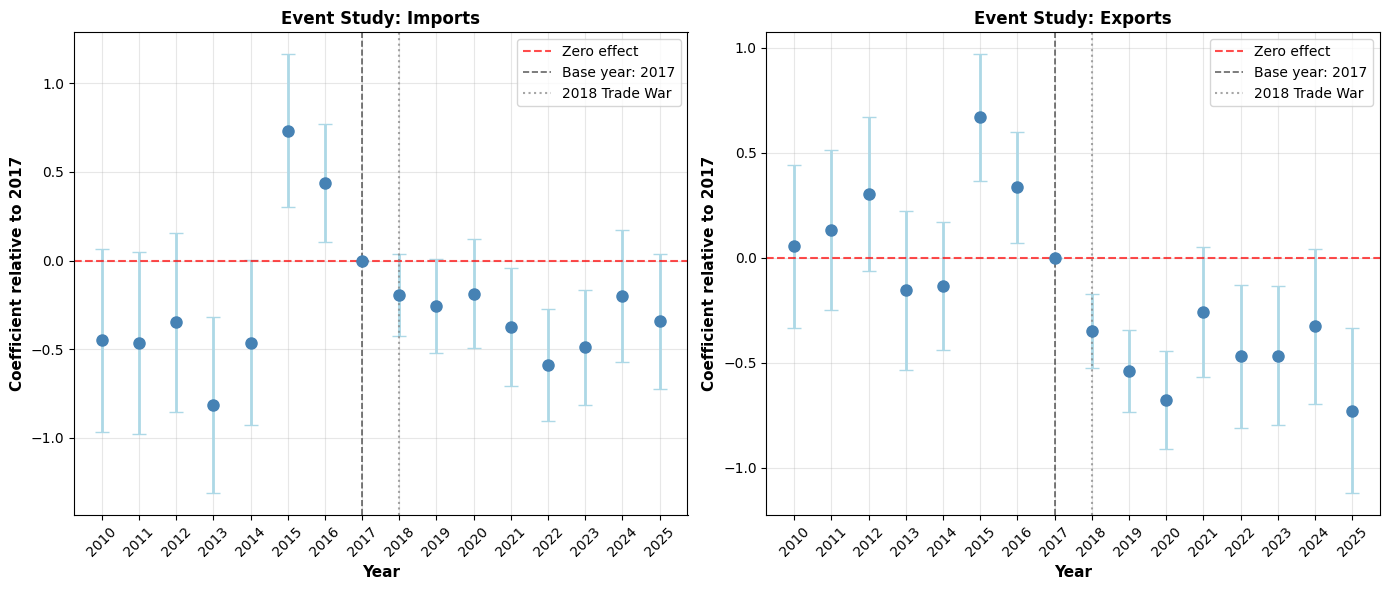

In [48]:
# Event Study: pooled year interactions with 2013-constant US exposure
# Estimate year-specific differential exposure effects relative to an omitted base year

# Get unique years and choose a reference year
years_list = sorted(tpu_imports_panel.index.get_level_values('time').year.unique())
base_year = 2017 if 2017 in years_list else years_list[0]
interaction_years = [year for year in years_list if year != base_year]

# Add year interaction columns to both panels
for year in interaction_years:
    col = f'us_exp_2013_x_year_{year}'
    imports_year_mask = (tpu_imports_panel.index.get_level_values('time').year == year).astype(int)
    exports_year_mask = (tpu_exports_panel.index.get_level_values('time').year == year).astype(int)
    tpu_imports_panel[col] = tpu_imports_panel['us_exposure_2013'] * imports_year_mask
    tpu_exports_panel[col] = tpu_exports_panel['us_exposure_2013'] * exports_year_mask

interaction_cols = [f'us_exp_2013_x_year_{year}' for year in interaction_years]

# Cluster at the country-pair level for panel-consistent inference
clusters_imports_event = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index,
    name='cluster'
)
clusters_exports_event = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index,
    name='cluster'
)

# Explicit monthly FE in place of time FE
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)

imports_event_model = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[interaction_cols + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports_event)

exports_event_model = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[interaction_cols + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports_event)

# Collect coefficients and confidence intervals for plotting
event_study_results = {'Imports': {}, 'Exports': {}}
imports_event_coefs = {base_year: 0.0}
imports_event_ci_lower = {base_year: 0.0}
imports_event_ci_upper = {base_year: 0.0}
exports_event_coefs = {base_year: 0.0}
exports_event_ci_lower = {base_year: 0.0}
exports_event_ci_upper = {base_year: 0.0}

for year in interaction_years:
    coef_name = f'us_exp_2013_x_year_{year}'
    if coef_name in imports_event_model.params.index:
        coef = imports_event_model.params[coef_name]
        ci = imports_event_model.conf_int().loc[coef_name]
        imports_event_coefs[year] = coef
        imports_event_ci_lower[year] = ci.iloc[0]
        imports_event_ci_upper[year] = ci.iloc[1]
        event_study_results['Imports'][year] = {'coef': coef, 'ci_lower': ci.iloc[0], 'ci_upper': ci.iloc[1]}
    if coef_name in exports_event_model.params.index:
        coef = exports_event_model.params[coef_name]
        ci = exports_event_model.conf_int().loc[coef_name]
        exports_event_coefs[year] = coef
        exports_event_ci_lower[year] = ci.iloc[0]
        exports_event_ci_upper[year] = ci.iloc[1]
        event_study_results['Exports'][year] = {'coef': coef, 'ci_lower': ci.iloc[0], 'ci_upper': ci.iloc[1]}

# Plot the event-study coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_event_study(ax, coefs, ci_lower, ci_upper, title, base_year, shock_year=2018):
    years = sorted(coefs.keys())
    coef_vals = [coefs[y] for y in years]
    errors_lower = [coefs[y] - ci_lower[y] for y in years]
    errors_upper = [ci_upper[y] - coefs[y] for y in years]

    ax.errorbar(
        years,
        coef_vals,
        yerr=[errors_lower, errors_upper],
        fmt='o',
        capsize=5,
        markersize=8,
        color='steelblue',
        ecolor='lightblue',
        linewidth=2
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero effect')
    ax.axvline(base_year, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Base year: {base_year}')
    ax.axvline(shock_year, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'{shock_year} Trade War')
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Coefficient relative to {base_year}', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)

plot_event_study(ax1, imports_event_coefs, imports_event_ci_lower, imports_event_ci_upper,
                 'Event Study: Imports', base_year=base_year, shock_year=2018)
plot_event_study(ax2, exports_event_coefs, exports_event_ci_lower, exports_event_ci_upper,
                 'Event Study: Exports', base_year=base_year, shock_year=2018)

plt.tight_layout()
plt.show()

Using the event study plot, we reject parallel trends for both exports and imports due to pre-trends, most evidently in 2015. Therefore, the main model going forward will be the TPU lagged model, and we do not conclude causality from this analysis.

Finally, I run a Baron & Kenny mediation analysis to test the mechanism of business confidence. I first test the effect of TPU on BCI, then the effect of BCI on trade values, and finally the effect of TPU on trade values controlling for BCI. I do this for both parties of bilateral pairs, as the effect of TPU on business confidence may differ for exporters and importers.

In [49]:
# Mediation Analysis: Does Business Confidence (BCI) mediate the TPU -> Trade relationship?
# Heterogeneous mediation: ln_TPU x us_exposure_2013 tests whether the channel is stronger for US-exposed pairs.

# Build BCI variables
if 'bci_reporter' in tpu_imports_panel.columns:
    tpu_imports_panel['ln_bci_reporter'] = np.log(tpu_imports_panel['bci_reporter'].clip(lower=0.1))
    tpu_exports_panel['ln_bci_reporter'] = np.log(tpu_exports_panel['bci_reporter'].clip(lower=0.1))
else:
    bci_values_imp = tpu_imports.loc[tpu_imports_panel.index.get_level_values('time'), 'bci_reporter']
    bci_values_exp = tpu_exports.loc[tpu_exports_panel.index.get_level_values('time'), 'bci_reporter']
    tpu_imports_panel['ln_bci_reporter'] = np.log(bci_values_imp.values.clip(lower=0.1))
    tpu_exports_panel['ln_bci_reporter'] = np.log(bci_values_exp.values.clip(lower=0.1))

if 'bci_partner' in tpu_imports_panel.columns:
    tpu_imports_panel['ln_bci_partner'] = np.log(tpu_imports_panel['bci_partner'].clip(lower=0.1))
    tpu_exports_panel['ln_bci_partner'] = np.log(tpu_exports_panel['bci_partner'].clip(lower=0.1))
else:
    try:
        bci_partner_imp = tpu_imports.loc[tpu_imports_panel.index.get_level_values('time'), 'bci_partner']
        bci_partner_exp = tpu_exports.loc[tpu_exports_panel.index.get_level_values('time'), 'bci_partner']
        tpu_imports_panel['ln_bci_partner'] = np.log(bci_partner_imp.values.clip(lower=0.1))
        tpu_exports_panel['ln_bci_partner'] = np.log(bci_partner_exp.values.clip(lower=0.1))
    except Exception:
        tpu_imports_panel['ln_bci_partner'] = tpu_imports_panel['ln_bci_reporter']
        tpu_exports_panel['ln_bci_partner'] = tpu_exports_panel['ln_bci_reporter']

# Build interaction: ln_TPU x us_exposure_2013
tpu_imports_panel['ln_TPU_x_us_exp'] = tpu_imports_panel['ln_TPU'] * tpu_imports_panel['us_exposure_2013']
tpu_exports_panel['ln_TPU_x_us_exp'] = tpu_exports_panel['ln_TPU'] * tpu_exports_panel['us_exposure_2013']

# Build explicit monthly FE (YYYY-MM)
exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_exports_panel.index)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).to_period('M').astype(str)
}, index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)

med_vars_base = ['ln_TPU', 'ln_TPU_x_us_exp'] + control_vars

# Stage 1: ln_TPU (+ interaction) -> ln_BCI
stage1_reporter = PanelOLS(
    tpu_imports_panel['ln_bci_reporter'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage1_partner = PanelOLS(
    tpu_imports_panel['ln_bci_partner'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

# Stage 2a: ln_TPU (+ interaction) -> Trade (total effect)
stage2a_exports = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[med_vars_base],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

stage2a_imports = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Stage 2b: ln_TPU (+ interaction) + ln_BCI -> Trade (direct effect)
stage2b_exports_reporter = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter'] + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

stage2b_imports_reporter = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter'] + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

stage2b_exports_partner = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_partner'] + control_vars],
    entity_effects=True,
    other_effects=exports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

stage2b_imports_partner = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_partner'] + control_vars],
    entity_effects=True,
    other_effects=imports_month_fe,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Mega mediation table
stargazer_mediation_mega = Stargazer([
    stage1_reporter,
    stage1_partner,
    stage2a_exports,
    stage2a_imports,
    stage2b_exports_reporter,
    stage2b_imports_reporter,
    stage2b_exports_partner,
    stage2b_imports_partner
])
stargazer_mediation_mega.title('Mediation Analysis')
stargazer_mediation_mega.custom_columns([
    'S1 Reporter BCI',
    'S1 Partner BCI',
    'S2a Exports',
    'S2a Imports',
    'S2b Exports (Reporter BCI)',
    'S2b Imports (Reporter BCI)',
    'S2b Exports (Partner BCI)',
    'S2b Imports (Partner BCI)'
], [1, 1, 1, 1, 1, 1, 1, 1])
preferred_order = [
    'ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter', 'ln_bci_partner'
] + control_vars
available_covs = set(stargazer_mediation_mega.cov_names)
ordered_covs = [c for c in preferred_order if c in available_covs]
if ordered_covs:
    stargazer_mediation_mega.covariate_order(ordered_covs)
stargazer_mediation_mega.add_line('Fixed Effects', ['Entity', 'Entity', 'Entity + Monthly', 'Entity + Monthly', 'Entity + Monthly', 'Entity + Monthly', 'Entity + Monthly', 'Entity + Monthly'])


display(HTML(f'<div style="transform: scaleX(0.85); transform-origin: left; display: inline-block;">{stargazer_mediation_mega.render_html()}</div>'))

While Stage 1 and 2 confirm BCI as a mechanism for exports, explaining around 20% of the TPU and trade relationship, we reject it for imports. In fact, BCI acts as a suppressor variable for imports, suggesting that when sentiments are low, firms may increase the trade value of imports during times of high TPU. It could be that firms are importing more to stockpile inventory in response to uncertainty or that other mechanisms are more relevant. 

# Project 3

## 3.1 Web-Scraping

To address endogeneity concerns on the impact of real trade barriers versus the psychological impact of uncertainty, the main focus of this paper, I use the Global Trade Alert API, a web API that tracks trade policy changes: https://api.globaltradealert.org/api/v2/gta/data/. I filter for trade policies that would impact real trade values, such as tariffs and trade quotas, and remove any "dirty pairings" from the main data that may be skewed by real barrier changes before rerunning my models. I also filter to policies that are in-force.

The main challenge with web-scraping this data are a) the mass amounts of information that this API can output, b) the daily limit of 1000 pulls, and c) the proprietary IDs used by the API. To resolve these, I run strict filters to isolate for only desired trade policies and run year segments at a time to ensure I do not exceed the API limit. I also create a map

In [50]:
import requests
import pandas as pd
import time

# ==========================================
# 1. API CONFIGURATION & AUTHENTICATION
# ==========================================
API_TOKEN = "5ba07aa9b082b91ee4f7c445fed29daf4130b75c"
BASE_URL = "https://api.globaltradealert.org/api/v2/gta/data/"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"APIKey {API_TOKEN}"
}

# 1. Pull the mappings
mapping_payload = {"keys": ["jurisdictions"]}
map_res = requests.post("https://api.globaltradealert.org/api/v1/gta/mappings/", 
                        headers=headers, json=mapping_payload)

jurisdictions = map_res.json().get('jurisdictions', [])

# 2. Create the lookup using 'iso_code' and 'id'
# We normalize to upper() to ensure "USA" matches "usa"
id_lookup = {
    str(j['iso_code']).strip().upper(): j['id'] 
    for j in jurisdictions 
    if j.get('iso_code') and j.get('id')
}

# 3. Build your targets from the panel
my_targets = sorted(
    set(tpu_exports_panel['iso3reporter'].dropna().astype(str).str.upper().str.strip())
    | set(tpu_exports_panel['iso3partner'].dropna().astype(str).str.upper().str.strip())
)

# 4. Map to IDs
target_ids = [id_lookup[iso] for iso in my_targets if iso in id_lookup]

print(f"Success! Mapped {len(target_ids)} countries to IDs.")
print(f"IDs for your RF model: {target_ids[:10]}...")

# ==========================================
# 2. DEFINING "CONCRETE" TRADE BARRIERS
# ==========================================
# Mapped from the GTA Documentation and UN MAST Correspondence.
# These focus on physical/legal friction rather than financial support.
HARD_BARRIER_IDS = [
    47,  # Import tariff
    45,  # Import quota
    22,  # Import ban
    49,  # Technical barrier to trade (TBT)
    36,  # Import licensing requirement
    51,  # Anti-dumping
    52   # Safeguard
]

# ==========================================
# 3. TARGET PARAMETERS
# ==========================================
# Using the 2016-2020 window for the before/after structural break test.
# 'target_ids' must be the list of numeric jurisdiction IDs previously mapped.
years = ["2010", "2011", "2012", "2013", "2022", "2023", "2024", "2025", "2016", "2017", "2018", "2019", "2020", "2014", "2015", "2021"]
all_observations = []

# ==========================================
# 4. EXECUTION LOOP (QUOTA-AWARE)
# ==========================================
for year in years:
    print(f"--- Fetching {year} Concrete Barriers ---")
    
    # We pull 200 per year to ensure a balanced panel and stay under the 1k daily cap
    payload = {
        "limit": 200,
        "offset": 0,
        "request_data": {
            "implementer": target_ids,
            "gta_evaluation": [1],           # Red (Harmful) only
            "implementation_period": [f"{year}-01-01", f"{year}-12-31"],
            "intervention_types": HARD_BARRIER_IDS,
            "keep_intervention_types": True
        }
    }
    
    try:
        response = requests.post(BASE_URL, headers=headers, json=payload)
        
        if response.status_code == 200:
            batch = response.json()
            # Handle the top-level list structure from the V2 endpoint
            current_batch = batch if isinstance(batch, list) else batch.get('results', [])
            all_observations.extend(current_batch)
            print(f"Success: Added {len(current_batch)} observations for {year}.")
        else:
            print(f"Error {response.status_code} for {year}: {response.text}")
            
    except Exception as e:
        print(f"Request failed for {year}: {e}")
    
    # Pause to be gentle on the API and prevent soft-bans
    time.sleep(1.5)

combined_barriers = pd.DataFrame(all_observations)

Success! Mapped 29 countries to IDs.
IDs for your RF model: [40, 56, 100, 124, 156, 203, 276, 208, 724, 233]...
--- Fetching 2010 Concrete Barriers ---
Success: Added 5 observations for 2010.
--- Fetching 2011 Concrete Barriers ---
Success: Added 5 observations for 2011.
--- Fetching 2012 Concrete Barriers ---
Success: Added 5 observations for 2012.
--- Fetching 2013 Concrete Barriers ---
Success: Added 5 observations for 2013.
--- Fetching 2022 Concrete Barriers ---
Success: Added 89 observations for 2022.
--- Fetching 2023 Concrete Barriers ---
Success: Added 91 observations for 2023.
--- Fetching 2024 Concrete Barriers ---
Success: Added 114 observations for 2024.
--- Fetching 2025 Concrete Barriers ---
Success: Added 200 observations for 2025.
--- Fetching 2016 Concrete Barriers ---
Success: Added 5 observations for 2016.
--- Fetching 2017 Concrete Barriers ---
Success: Added 81 observations for 2017.
--- Fetching 2018 Concrete Barriers ---
Success: Added 153 observations for 2018.

I merge the data into my main datasets on date of announcement and implementing/affected juristiction. I also convert the dataset to months only to fit my monthly dataset.

I then visualise the scraped data. First, I visualise a time-series plot of trade volumes vs number of restrictions implemented.

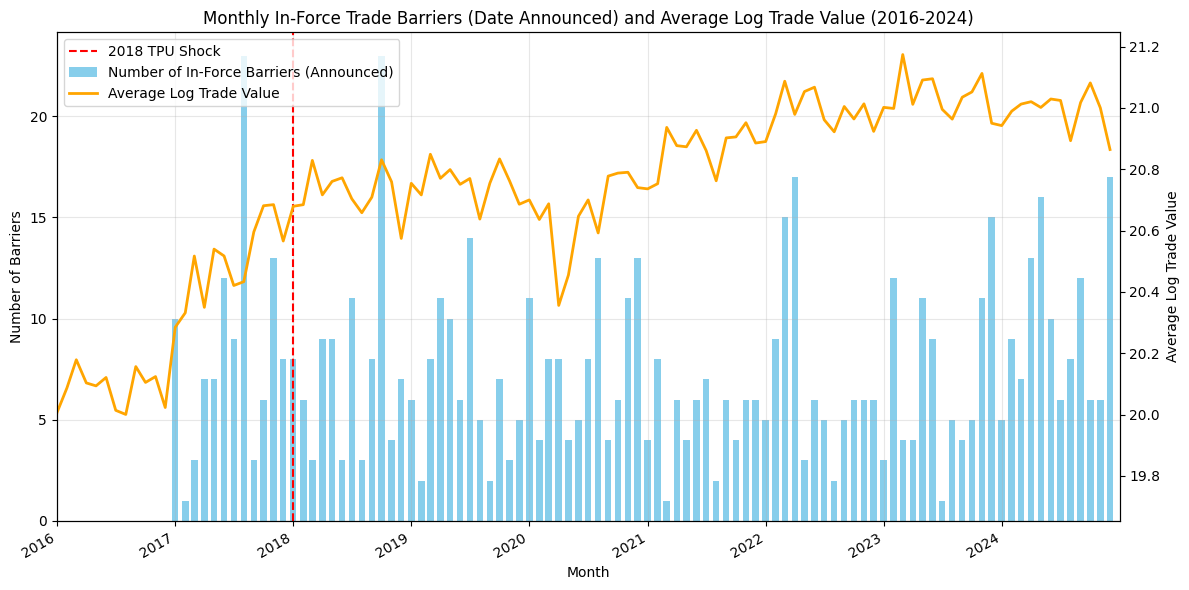

In [ ]:
# Create a monthly barriers-vs-trade plot (2016-2024).
import numpy as np

# 1) Prepare barriers data using announcement date and only in-force measures
barriers_plot = combined_barriers.copy()
barriers_plot['date_announced'] = pd.to_datetime(barriers_plot['date_announced'], errors='coerce')
barriers_plot = barriers_plot[barriers_plot['date_announced'].notna()].copy()
barriers_plot = barriers_plot[barriers_plot['is_in_force'] == 1].copy()
barriers_plot['month'] = barriers_plot['date_announced'].dt.to_period('M').dt.to_timestamp()

def extract_iso3(jurisdiction):
    if isinstance(jurisdiction, list) and len(jurisdiction) > 0 and isinstance(jurisdiction[0], dict):
        return jurisdiction[0].get('iso')
    if isinstance(jurisdiction, dict):
        return jurisdiction.get('iso')
    return None

barriers_plot['iso3'] = barriers_plot['implementing_jurisdictions'].apply(extract_iso3)
barriers_plot['iso3'] = barriers_plot['iso3'].astype('string').str.upper()

# 2) Prepare exports panel data without mutating original
exports_plot = tpu_exports_panel.copy()

if 'month' not in exports_plot.columns:
    if 'time' in exports_plot.columns:
        exports_plot['month'] = pd.to_datetime(exports_plot['time'], errors='coerce').dt.to_period('M').dt.to_timestamp()
    elif 'date' in exports_plot.columns:
        exports_plot['month'] = pd.to_datetime(exports_plot['date'], errors='coerce').dt.to_period('M').dt.to_timestamp()
    else:
        raise ValueError("Need a time/date column in tpu_exports_panel to build monthly series.")

if 'iso3reporter' in exports_plot.columns:
    exports_plot['iso3'] = exports_plot['iso3reporter'].astype('string').str.upper()
elif 'iso3' in exports_plot.columns:
    exports_plot['iso3'] = exports_plot['iso3'].astype('string').str.upper()
else:
    raise ValueError("Need iso3reporter or iso3 in tpu_exports_panel.")

# 3) Build monthly series
bar_data = barriers_plot.groupby('month').size().sort_index()

# Use direct monthly trade average to avoid merge-driven weighting artifacts
line_data = exports_plot.groupby('month')['log_trade_value'].mean().sort_index()

# 4) Truncate x-axis to 2016-2024
full_months = pd.date_range('2015-01-01', '2024-12-01', freq='MS')
bar_data = bar_data.reindex(full_months, fill_value=0).astype(float)
line_data = line_data.reindex(full_months)

# Keep actual trade levels and smooth missing gaps
line_data = line_data.interpolate(method='time', limit_direction='both')

# 5) Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(bar_data.index, bar_data.values, color='skyblue', width=20, label='Number of In-Force Barriers (Announced)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Barriers')
ax1.set_xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2024-12-31'))

ax2 = ax1.twinx()
ax2.plot(line_data.index, line_data.values, color='orange', linewidth=2, label='Average Log Trade Value')
ax2.set_ylabel('Average Log Trade Value')

shock_date = pd.to_datetime('2018-01-01')
ax1.axvline(shock_date, color='red', linestyle='--', linewidth=1.5, label='2018 TPU Shock')

ax1.set_title('Monthly In-Force Trade Barriers (Date Announced) and Average Log Trade Value (2016-2024)')
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

We notice several major elements. First, there is a sudden uptick of trade restrictions starting already in 2017 and the number of barriers remain high since then. That both offers an explaination of why TPU was so high post-2018. The second is that the increasing number of barriers occurs as trade volumes begin stagnating post-2018 as previously discussed: this plot suggests an environment of new restrictive trade, or at least the perception of it, creates anxiety among firms. 

But two questions remain: 1) is this stagnation a result of the real trade barrier impacts instead of uncertainty? 2) where are all these restrictions concentrated? To address 2), I plot a map to show where the barrier implementing countries are.

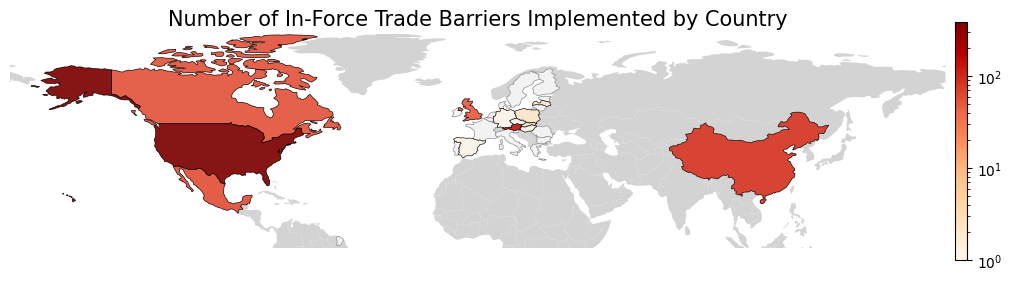

In [ ]:
# Make a geopandas map of countries with the most in-force barriers by ISO3
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors

# 1) Build ISO3 from implementing_jurisdictions and count in-force barriers
def extract_iso3(jurisdiction):
    if isinstance(jurisdiction, list) and len(jurisdiction) > 0 and isinstance(jurisdiction[0], dict):
        return jurisdiction[0].get('iso')
    if isinstance(jurisdiction, dict):
        return jurisdiction.get('iso')
    return None

def get_iso3_reporter_series(df):
    if 'iso3reporter' in df.columns:
        return df['iso3reporter']
    if hasattr(df.index, 'names') and 'iso3reporter' in list(df.index.names):
        return pd.Series(df.index.get_level_values('iso3reporter'), index=df.index)
    return pd.Series(dtype='string')

barriers_for_map = combined_barriers.copy()
if 'is_in_force' in barriers_for_map.columns:
    barriers_for_map = barriers_for_map[barriers_for_map['is_in_force'] == 1].copy()

barriers_for_map['iso3'] = barriers_for_map['implementing_jurisdictions'].apply(extract_iso3)
barriers_for_map['iso3'] = barriers_for_map['iso3'].astype('string').str.upper()

barriers_by_country = (
    barriers_for_map.dropna(subset=['iso3'])
    .groupby('iso3')
    .size()
    .reset_index(name='barrier_count')
)

# 2) Use the country universe from Cell 60 (TPU exports/imports reporters) + force include France
countries = pd.concat(
    [
        get_iso3_reporter_series(tpu_exports),
        get_iso3_reporter_series(tpu_imports),
        pd.Series(['FRA'])
    ],
    ignore_index=True
).dropna().astype('string').str.upper().drop_duplicates()

countries = pd.DataFrame({'iso3': countries})
countries = countries.merge(barriers_by_country, on='iso3', how='left')
countries['barrier_count'] = countries['barrier_count'].fillna(0).astype(int)

# 3) Load world shapefile
world = gpd.read_file("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/ne_110m_admin_0_countries.shp")

# 4) Build a robust ISO3 key row-wise so countries like France are not dropped by -99 codes
iso_candidates = ['ADM0_A3', 'SOV_A3', 'ISO_A3', 'iso_a3', 'ISO_A3_EH']
available_iso_cols = [c for c in iso_candidates if c in world.columns]
if not available_iso_cols:
    raise KeyError(f"No ISO3-like columns found in shapefile columns: {list(world.columns)}")

def pick_iso3(row):
    for col in available_iso_cols:
        val = row[col]
        if pd.isna(val):
            continue
        code = str(val).upper().strip()
        if len(code) == 3 and code != '-99':
            return code
    return pd.NA

world['iso3'] = world.apply(pick_iso3, axis=1).astype('string')
world_barriers = world.merge(countries, on='iso3', how='inner')
world_barriers['barrier_count'] = world_barriers['barrier_count'].fillna(0).astype(int)

gdf_barriers = gpd.GeoDataFrame(world_barriers, geometry='geometry')
gdf_zero = gdf_barriers[gdf_barriers['barrier_count'] == 0].copy()
gdf_positive = gdf_barriers[gdf_barriers['barrier_count'] > 0].copy()

# 5) Match Cell 60 map design: crop south of Malaysia and fit bounds tightly
south_cutoff_lat = 1.0
cropped_world = world[world.geometry.bounds.maxy >= south_cutoff_lat].copy()
xmin, ymin, xmax, ymax = cropped_world.total_bounds
ymin = max(ymin, south_cutoff_lat)

map_ratio = (xmax - xmin) / (ymax - ymin)
fig_width = 10
fig_height = max(2.8, fig_width / map_ratio)
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), constrained_layout=True)

cropped_world.plot(ax=ax, color='lightgray')

# Plot zeros in a neutral color so they are visually separate
if not gdf_zero.empty:
    gdf_zero.plot(
        ax=ax,
        color='#f2f2f2',
        edgecolor='#8f8f8f',
        linewidth=0.5
    )

# Plot positive counts with stronger contrast among low values
if not gdf_positive.empty:
    vmax = max(1, int(gdf_positive['barrier_count'].max()))
    gdf_positive.plot(
        ax=ax,
        column='barrier_count',
        cmap='OrRd',
        norm=colors.LogNorm(vmin=1, vmax=vmax),
        legend=True,
        legend_kwds={'shrink': 0.88, 'pad': 0.01},
        alpha=0.9,
        edgecolor='k',
        linewidth=0.5
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.margins(0)
ax.set_title('Number of In-Force Trade Barriers Implemented by Country', fontsize=15)
ax.set_axis_off()
plt.show()

As expected, the biggest culprit of the post-2017/2018 trend in greater trade barriers come from the United States, with double the barriers announced and implemented compared to the next highest. This fact thus further confirms the validity of using US Trade Policy Uncertainty: the US has been the biggest user of trade restrictions and thus also the biggest cause of global policy uncertainty, both due to the volume of barriers and their position as the world's largest economy. 

To address concern 1), I re-run the lagged regression model but excluding the polluted pairings.

In [ ]:
# Exclude all pairings that appear in GTA barriers, then re-run the Cell 107-style robustness model on the cleaned sample.
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display


def extract_iso3(jurisdiction):
    if isinstance(jurisdiction, list) and len(jurisdiction) > 0 and isinstance(jurisdiction[0], dict):
        return jurisdiction[0].get('iso')
    if isinstance(jurisdiction, dict):
        return jurisdiction.get('iso')
    return None


def ensure_panel_index(df):
    out = df.copy()

    if isinstance(out.index, pd.MultiIndex) and set(['entity', 'time']).issubset(set(out.index.names)):
        return out.sort_index()

    if 'entity' not in out.columns:
        out['entity'] = out['iso3reporter'].astype('string') + '_' + out['iso3partner'].astype('string')

    if 'time' not in out.columns:
        if 'DATE' in out.columns:
            out['time'] = out['DATE']
        elif pd.api.types.is_datetime64_any_dtype(out.index):
            out['time'] = out.index
        else:
            raise KeyError("Could not find a time column to build panel index.")

    out['time'] = pd.to_datetime(out['time'], errors='coerce')
    out = out.dropna(subset=['time'])
    return out.set_index(['entity', 'time']).sort_index()


# 1) Build exclusion set of (reporter, partner) from GTA barriers
barriers_for_exclusion = combined_barriers.copy()
barriers_for_exclusion['reporter_iso3'] = barriers_for_exclusion['implementing_jurisdictions'].apply(extract_iso3)
barriers_for_exclusion['partner_iso3'] = barriers_for_exclusion['affected_jurisdictions'].apply(extract_iso3)
barriers_for_exclusion['reporter_iso3'] = barriers_for_exclusion['reporter_iso3'].astype('string').str.upper()
barriers_for_exclusion['partner_iso3'] = barriers_for_exclusion['partner_iso3'].astype('string').str.upper()

exclusion_pairs = set(
    barriers_for_exclusion.dropna(subset=['reporter_iso3', 'partner_iso3'])
    [['reporter_iso3', 'partner_iso3']]
    .itertuples(index=False, name=None),
)


def drop_dirty_pairs(panel_df):
    pair_tuples = list(zip(panel_df['iso3reporter'].astype('string').str.upper(), panel_df['iso3partner'].astype('string').str.upper()))
    keep_mask = pd.Series([pair not in exclusion_pairs for pair in pair_tuples], index=panel_df.index)
    return panel_df.loc[keep_mask].copy(), int((~keep_mask).sum())


clean_exports_raw, dropped_exp = drop_dirty_pairs(tpu_exports_panel)
clean_imports_raw, dropped_imp = drop_dirty_pairs(tpu_imports_panel)

clean_exports = ensure_panel_index(clean_exports_raw)
clean_imports = ensure_panel_index(clean_imports_raw)

print(f"Dropped dirty-pair rows: exports={dropped_exp:,}, imports={dropped_imp:,}")
print(f"Clean sample sizes: exports={len(clean_exports):,}, imports={len(clean_imports):,}")


def add_lags_and_interactions(panel_df, lags):
    panel_df = panel_df.sort_index()
    entity_ids = panel_df.index.get_level_values('entity')
    for lag in lags:
        lag_col = f'ln_TPU_lag_{lag}m'
        int_col = f'{lag_col}_x_us_exp'
        if lag_col not in panel_df.columns:
            panel_df[lag_col] = panel_df.groupby(entity_ids)['ln_TPU'].shift(lag)
        panel_df[int_col] = panel_df[lag_col] * panel_df['us_exposure_2013']
    return panel_df


# 2) Cell 107-style robustness specification on the cleaned sample
lag_terms = [6, 12, 18, 24]
clean_exports = add_lags_and_interactions(clean_exports, lag_terms)
clean_imports = add_lags_and_interactions(clean_imports, lag_terms)

exports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(clean_exports.index.get_level_values('time')).to_period('M').astype(str)
}, index=clean_exports.index)
imports_month_fe = pd.DataFrame({
    'month_fe': pd.to_datetime(clean_imports.index.get_level_values('time')).to_period('M').astype(str)
}, index=clean_imports.index)

us_exp_exog_robust = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
 ]

clean_exports_lag = clean_exports.dropna(subset=['log_trade_value'] + us_exp_exog_robust).copy()
clean_imports_lag = clean_imports.dropna(subset=['log_trade_value'] + us_exp_exog_robust).copy()

clusters_exports_lag = pd.Series(clean_exports_lag.index.get_level_values('entity'), index=clean_exports_lag.index)
clusters_imports_lag = pd.Series(clean_imports_lag.index.get_level_values('entity'), index=clean_imports_lag.index)

lagged_tpu_exports_clean = PanelOLS(
    clean_exports_lag['log_trade_value'],
    clean_exports_lag[us_exp_exog_robust],
    entity_effects=True,
    other_effects=exports_month_fe.loc[clean_exports_lag.index],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports_lag)

lagged_tpu_imports_clean = PanelOLS(
    clean_imports_lag['log_trade_value'],
    clean_imports_lag[us_exp_exog_robust],
    entity_effects=True,
    other_effects=imports_month_fe.loc[clean_imports_lag.index],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports_lag)


stargazer_lagged_tpu_clean = Stargazer([lagged_tpu_exports_clean, lagged_tpu_imports_clean])
stargazer_lagged_tpu_clean.title('Lagged TPU Model (Cleaned Pairs, Entity+Monthly FE, GDP+NEER controls)')
stargazer_lagged_tpu_clean.custom_columns(['Exports', 'Imports'], [1, 1])

preferred_order = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_6m', 'ln_TPU_lag_6m_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_18m', 'ln_TPU_lag_18m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
 ]
available_covs = set(stargazer_lagged_tpu_clean.cov_names)
ordered_covs = [c for c in preferred_order if c in available_covs]
if ordered_covs:
    stargazer_lagged_tpu_clean.covariate_order(ordered_covs)

display(HTML(stargazer_lagged_tpu_clean.render_html()))

Dropped dirty-pair rows: exports=10,186, imports=10,221
Clean sample sizes: exports=138,898, imports=140,706


We observe that removing the dirty-pairings still gives us a similar result to our baseline model: export dips for US-exposed partners immediately and imports reacting a year later due to stickiness. Thus, we can conclude that the results seen in our models represent a real uncertainty reaction rather than the impacts of real trade barriers.

## 3.2 Machine Learning

For my regression tree, I seek to maximise the MSE - the objective function - of my trade data in the splits of the data into regions. So, our objective function will be, for a split into regions R1, R2, 

$\sum{(y_{i} - \hat y_{R1})^2} + \sum{ (y_{i} - \hat y_{R1})^2}$

And we create the regions by splitting on the model's x-variables: ln(TPU), GDP, exchange rate, etc. to maximise the MSE per split.

Our regression tree additionally allows for several regularisation parameters to minimise overfitting. For this, we have three main tools

- Max Depth: how many splits the model is allowed to do. Too many splits can pick up on too much noise, too little may only focus on major shocks and miss the smaller details we are interested in.
- Min Sample Split: the minimum amount of observations needed before attempting a split. Increasing it can minimise noise via a higher n count, but can reduce the number of splits possible.
- Alpha: the minimum threshold of MSE reduction acceptable for a split. A higher alpha will only split if there are undeniable shocks; a lower alpha will split for the smallest MSE reductions (risking overfitting).

For my dataset, I employ a residualised approach to my regression trees, using the residuals after partialling out the time and country-pair fixed effects to examine only the deviations in trade throughout the time period.

Imports residualized tree MSE (in-sample): 0.35372359018539434
Imports residualized tree R-squared (in-sample): 0.013813714803684873
Imports sample size: 61,176 rows out of 122,351
Exports residualized tree MSE (in-sample): 0.28471229935932957
Exports residualized tree R-squared (in-sample): 0.027060726834457483
Exports sample size: 60,413 rows out of 120,826


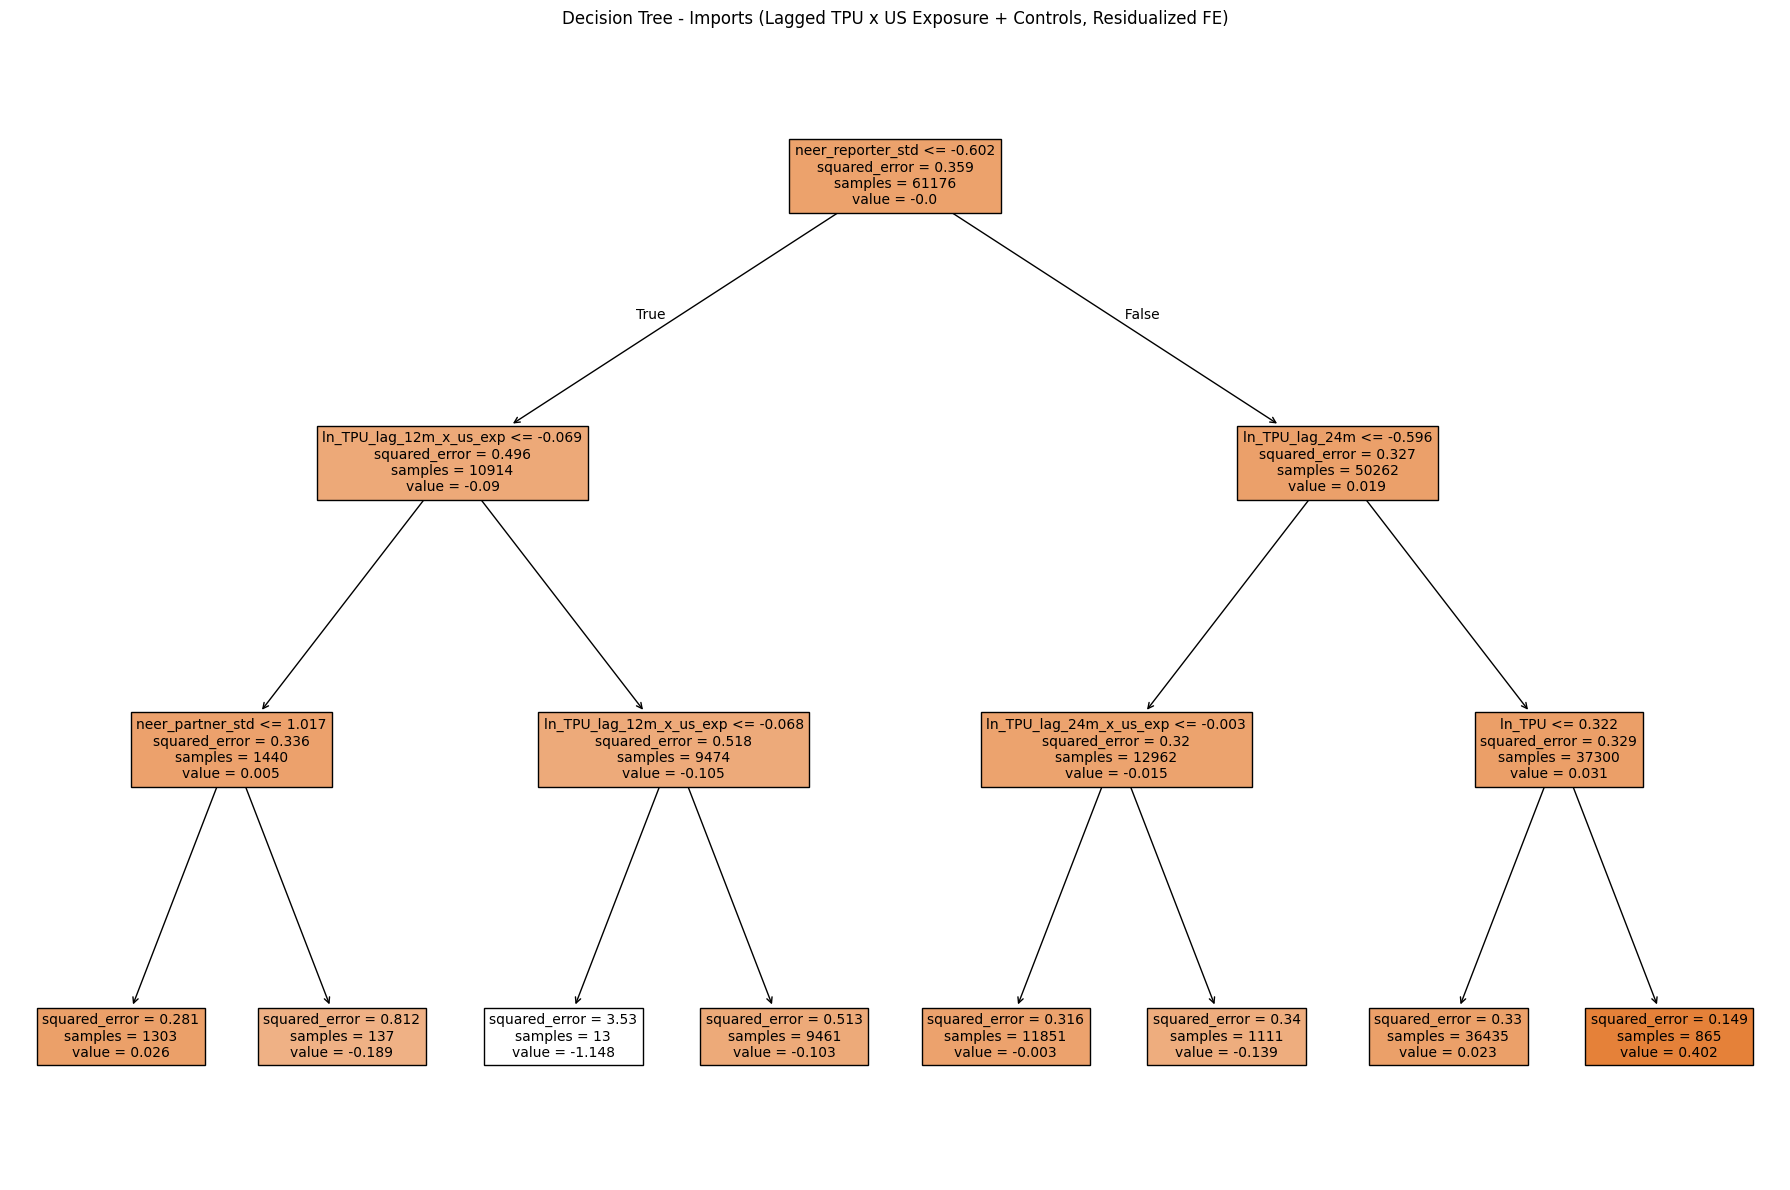

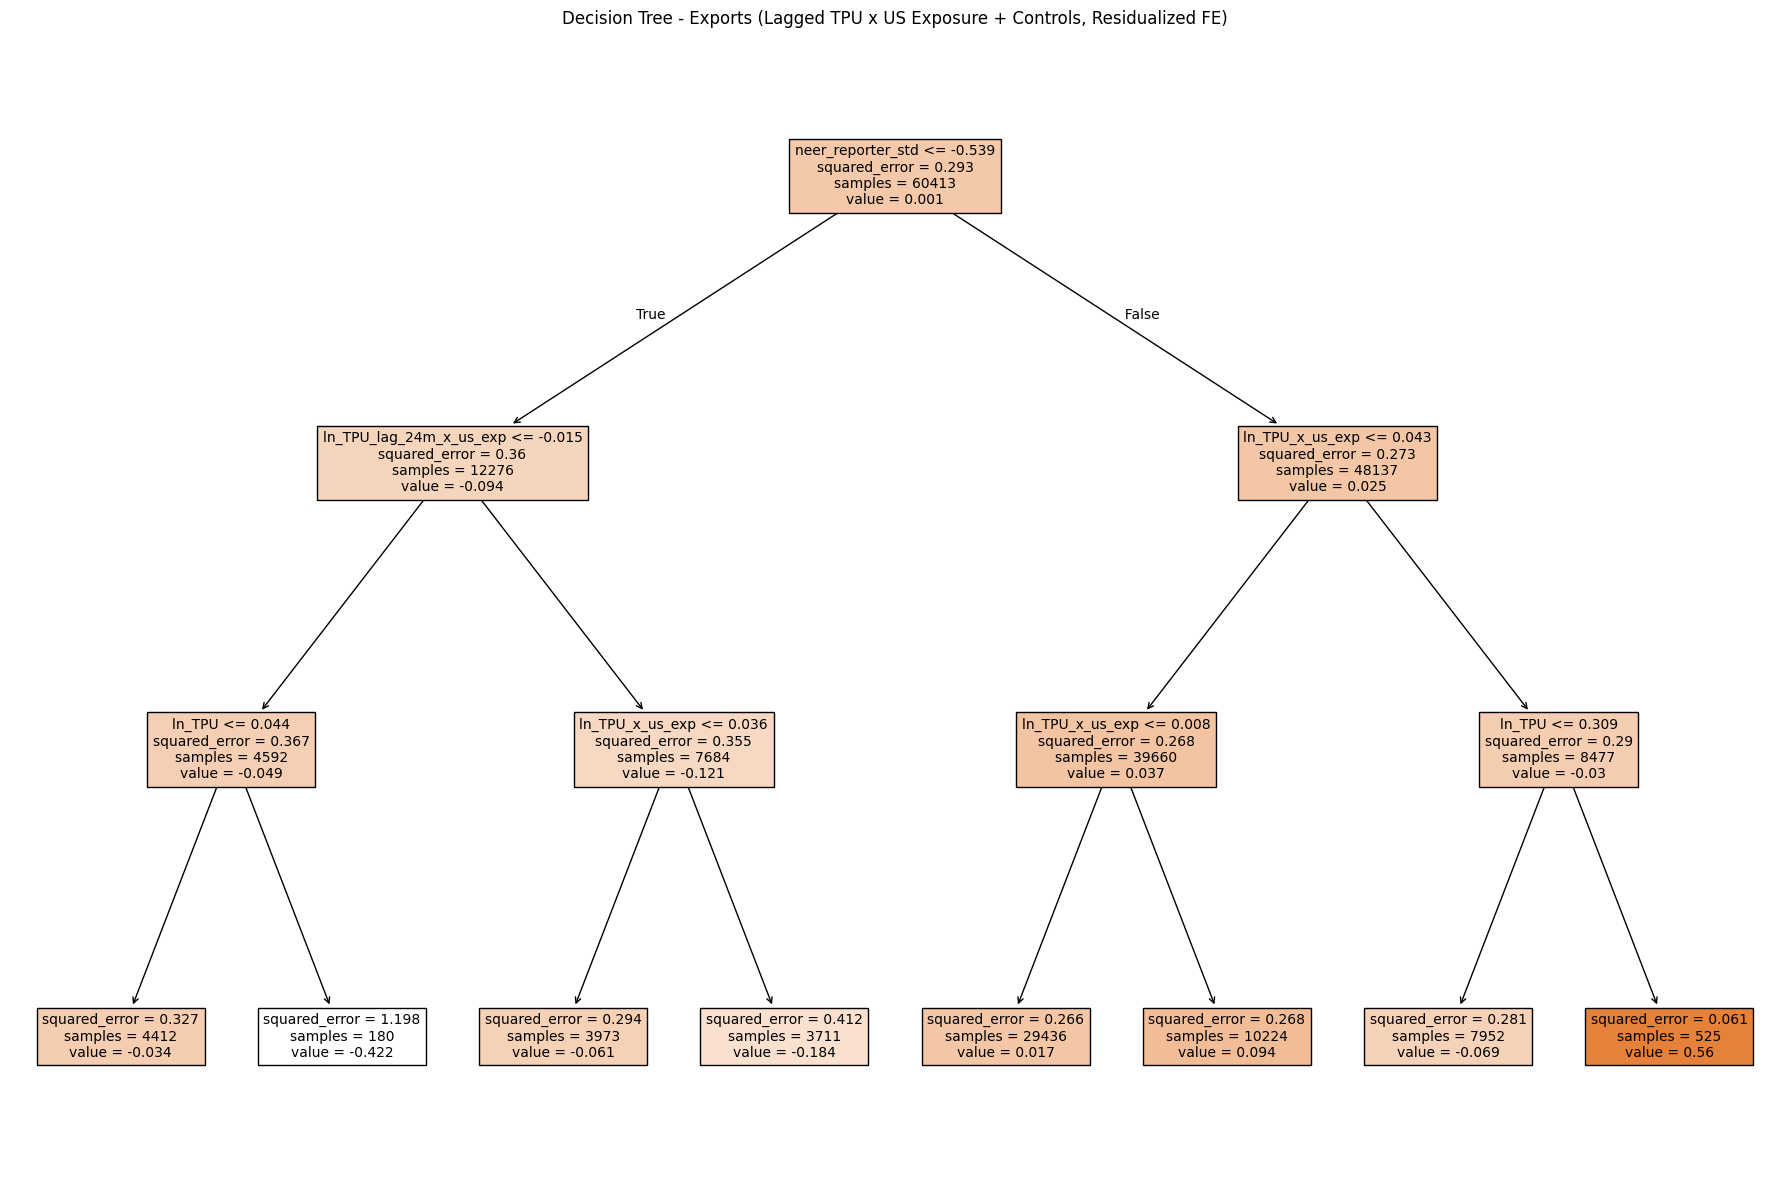

In [ ]:
from sklearn import tree, metrics
from sklearn.tree import plot_tree

# Use the same regressors as the lagged TPU FE model:
# ln_TPU and its 0/12/24-month interactions with US exposure + the same controls.
sample_frac = 0.5
random_state = 42


def residualize_two_way_fe(obj):
    """Double-demean numeric Series/DataFrame columns by entity and time."""
    if isinstance(obj, pd.Series):
        series = pd.to_numeric(obj, errors='coerce')
        series = series.sort_index()
        frame = series.to_frame(name=series.name or 'value')
        entity_means = frame.groupby(level=0).transform('mean')
        time_means = frame.groupby(level=1).transform('mean')
        resid = frame - entity_means - time_means + frame.mean()
        return resid.iloc[:, 0]

    frame = obj.copy()
    numeric_cols = frame.select_dtypes(include=['number']).columns
    numeric_part = frame[numeric_cols].sort_index()
    entity_means = numeric_part.groupby(level=0).transform('mean')
    time_means = numeric_part.groupby(level=1).transform('mean')
    resid_numeric = numeric_part - entity_means - time_means + numeric_part.mean()
    resid = frame.copy()
    resid[numeric_cols] = resid_numeric
    return resid


# Ensure lagged TPU interaction terms exist in the cleaned lagged-model datasets
for panel_df in [clean_exports_lag, clean_imports_lag]:
    if 'ln_TPU_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_x_us_exp'] = pd.to_numeric(panel_df['ln_TPU'], errors='coerce') * pd.to_numeric(panel_df['us_exposure_2013'], errors='coerce')
    if 'ln_TPU_lag_12m_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_lag_12m_x_us_exp'] = pd.to_numeric(panel_df['ln_TPU_lag_12m'], errors='coerce') * pd.to_numeric(panel_df['us_exposure_2013'], errors='coerce')
    if 'ln_TPU_lag_24m_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_lag_24m_x_us_exp'] = pd.to_numeric(panel_df['ln_TPU_lag_24m'], errors='coerce') * pd.to_numeric(panel_df['us_exposure_2013'], errors='coerce')

# Build tree design matrices from the same lagged TPU model regressors
req_imp = [c for c in lagged_imp_vars if c in clean_imports_lag.columns]
req_exp = [c for c in lagged_exp_vars if c in clean_exports_lag.columns]

X_imp = clean_imports_lag[req_imp].copy()
y_imp = clean_imports_lag['log_trade_value'].copy()
X_exp = clean_exports_lag[req_exp].copy()
y_exp = clean_exports_lag['log_trade_value'].copy()

# Residualize both X and y to partial out entity and time fixed effects before fitting trees.
X_imp_resid = residualize_two_way_fe(X_imp)
y_imp_resid = residualize_two_way_fe(y_imp)
X_exp_resid = residualize_two_way_fe(X_exp)
y_exp_resid = residualize_two_way_fe(y_exp)

# Imports tree
imp_idx = X_imp_resid.sample(frac=sample_frac, random_state=random_state).index
X_imp_sample = X_imp_resid.loc[imp_idx].copy()
y_imp_sample = y_imp_resid.loc[imp_idx].copy()
valid_imp = y_imp_sample.notna()
X_imp_sample = X_imp_sample[valid_imp]
y_imp_sample = y_imp_sample[valid_imp]

imp_tree = tree.DecisionTreeRegressor(
    max_depth=3,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state
)
imp_tree.fit(X_imp_sample, y_imp_sample)

imp_pred = imp_tree.predict(X_imp_sample)
print('Imports residualized tree MSE (in-sample):', metrics.mean_squared_error(y_imp_sample, imp_pred))
print('Imports residualized tree R-squared (in-sample):', metrics.r2_score(y_imp_sample, imp_pred))
print(f'Imports sample size: {len(X_imp_sample):,} rows out of {len(X_imp_resid):,}')

# Exports tree
exp_idx = X_exp_resid.sample(frac=sample_frac, random_state=random_state).index
X_exp_sample = X_exp_resid.loc[exp_idx].copy()
y_exp_sample = y_exp_resid.loc[exp_idx].copy()
valid_exp = y_exp_sample.notna()
X_exp_sample = X_exp_sample[valid_exp]
y_exp_sample = y_exp_sample[valid_exp]

exp_tree = tree.DecisionTreeRegressor(
    max_depth=3,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state
)
exp_tree.fit(X_exp_sample, y_exp_sample)

exp_pred = exp_tree.predict(X_exp_sample)
print('Exports residualized tree MSE (in-sample):', metrics.mean_squared_error(y_exp_sample, exp_pred))
print('Exports residualized tree R-squared (in-sample):', metrics.r2_score(y_exp_sample, exp_pred))
print(f'Exports sample size: {len(X_exp_sample):,} rows out of {len(X_exp_resid):,}')

fig, ax = plt.subplots(figsize=(18, 12))
plot_tree(imp_tree, feature_names=X_imp_sample.columns, filled=True, max_depth=3, ax=ax, fontsize=10)
ax.set_title('Decision Tree - Imports (Lagged TPU x US Exposure + Controls, Residualized FE)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(18, 12))
plot_tree(exp_tree, feature_names=X_exp_sample.columns, filled=True, max_depth=3, ax=ax, fontsize=10)
ax.set_title('Decision Tree - Exports (Lagged TPU x US Exposure + Controls, Residualized FE)')
plt.tight_layout()
plt.show()

The results from our regression trees fits neatly into the framework we have built so far. For exports, we see from our kitchen sink model that the first split occurs along the exposure x ln(TPU) interaction term, suggesting TPU interacted with US-trade dependence play a strong role in export outcomes, followed by exchange rates, business confidence, and the 2018 split. Imports tell an interesting story: the first split occurs on 2015, a firm reminder of the 2015 outlier year and a confirmation that parallel trends is not realistic. For imports, TPU is more of a second-order variable, which track with the import stickiness results we have found.


=== KITCHEN SINK: IMPORTS RANDOM FOREST ===
Kitchen sink random forest MSE (in-sample): 0.25739608908071543
Kitchen sink random forest R-squared (in-sample): 0.28951449773768734
Baseline R-squared for comparison: 0.013813714803684873

=== KITCHEN SINK: EXPORTS RANDOM FOREST ===
Kitchen sink random forest MSE (in-sample): 0.19465928298142687
Kitchen sink random forest R-squared (in-sample): 0.3301026372096276
Baseline R-squared for comparison: 0.027060726834457483


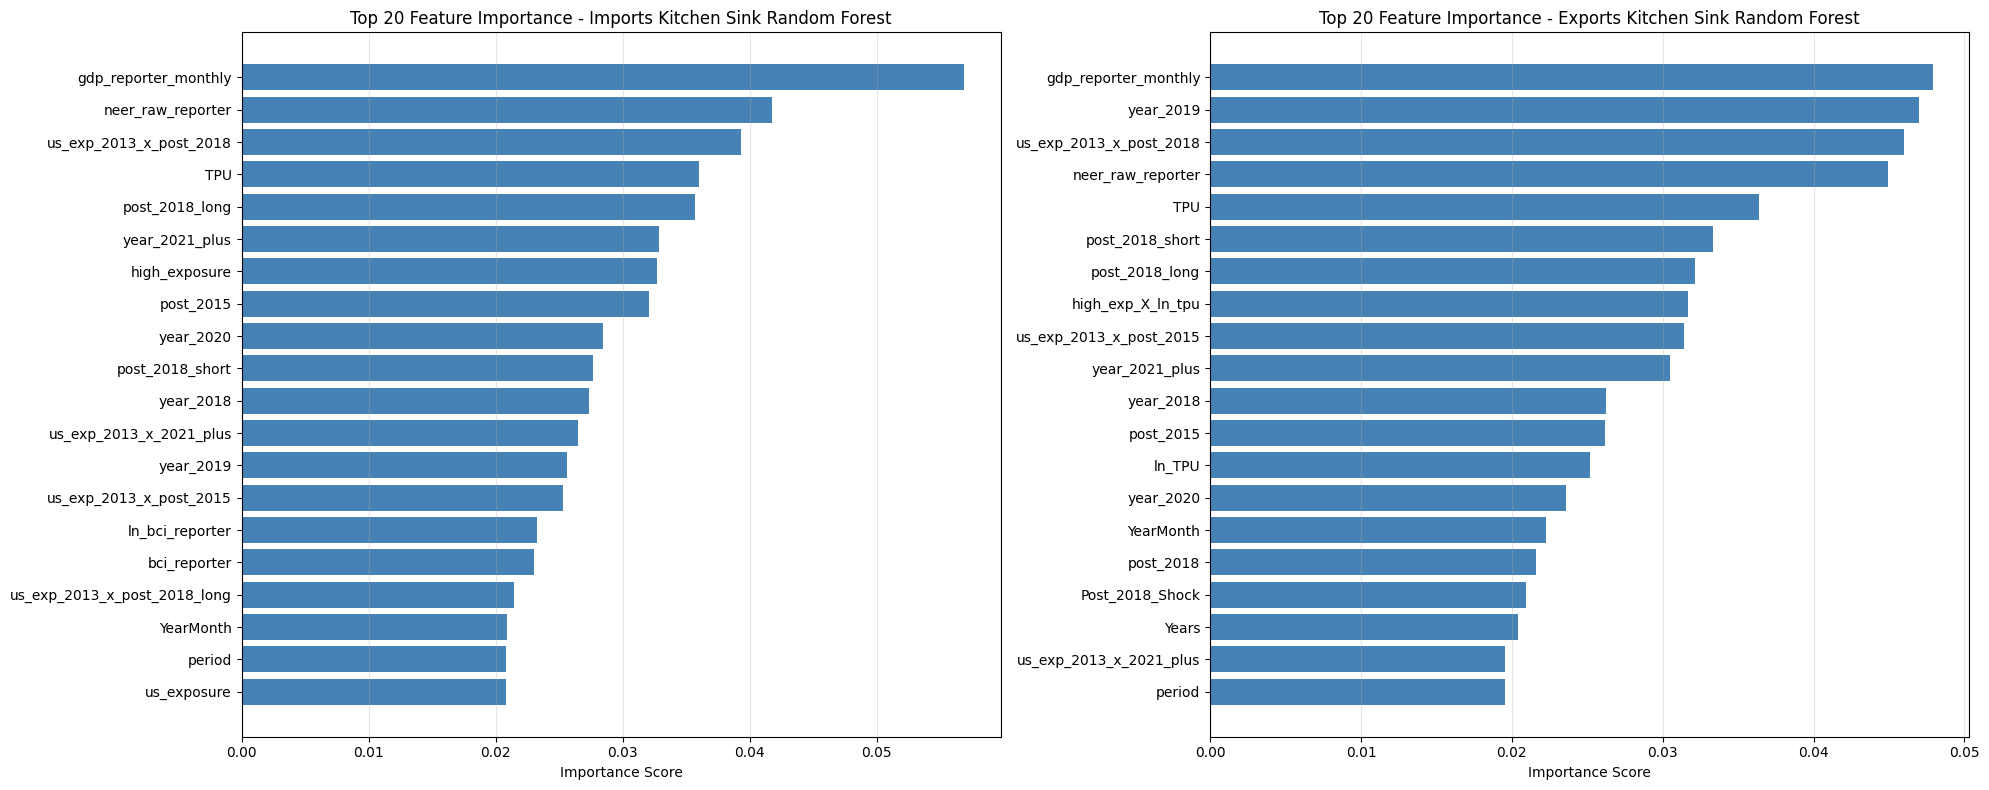

In [ ]:
#run a random forest with the same features to see if we get a similar importance ranking
from sklearn.ensemble import RandomForestRegressor

# Imports random forest
imp_rf_ks = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state,
    n_jobs=-1
)
imp_rf_ks.fit(X_imp_ks, y_imp_ks_sample)
imp_rf_pred_ks = imp_rf_ks.predict(X_imp_ks)
print('\n=== KITCHEN SINK: IMPORTS RANDOM FOREST ===')
print('Kitchen sink random forest MSE (in-sample):', metrics.mean_squared_error(y_imp_ks_sample, imp_rf_pred_ks))
print('Kitchen sink random forest R-squared (in-sample):', metrics.r2_score(y_imp_ks_sample, imp_rf_pred_ks))
print('Baseline R-squared for comparison:', metrics.r2_score(y_imp_sample, imp_pred))
imp_rf_importance = pd.DataFrame(
    {'feature': X_imp_ks.columns, 'importance': imp_rf_ks.feature_importances_}
).sort_values('importance', ascending=False).head(20)

# Exports random forest
exp_rf_ks = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state,
    n_jobs=-1
)
exp_rf_ks.fit(X_exp_ks, y_exp_ks_sample)
exp_rf_pred_ks = exp_rf_ks.predict(X_exp_ks)
print('\n=== KITCHEN SINK: EXPORTS RANDOM FOREST ===')
print('Kitchen sink random forest MSE (in-sample):', metrics.mean_squared_error(y_exp_ks_sample, exp_rf_pred_ks))
print('Kitchen sink random forest R-squared (in-sample):', metrics.r2_score(y_exp_ks_sample, exp_rf_pred_ks))
print('Baseline R-squared for comparison:', metrics.r2_score(y_exp_sample, exp_pred))
exp_rf_importance = pd.DataFrame(
    {'feature': X_exp_ks.columns, 'importance': exp_rf_ks.feature_importances_}
).sort_values('importance', ascending=False).head(20)

# Plot the importance matrices side-by-side in one figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.barh(imp_rf_importance['feature'], imp_rf_importance['importance'], color='steelblue')
ax1.set_title('Top 20 Feature Importance - Imports Kitchen Sink Random Forest')
ax1.set_xlabel('Importance Score')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

ax2.barh(exp_rf_importance['feature'], exp_rf_importance['importance'], color='steelblue')
ax2.set_title('Top 20 Feature Importance - Exports Kitchen Sink Random Forest')
ax2.set_xlabel('Importance Score')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

As expected, we see GDP and exchange rate at the top. But interestingly, we see 2019 at the very top of exports, suggesting that something structural about 2019 drove high volatility in exports - likely as economies structurally adapt to the post-2018 trade regime. We also see ln(TPU) interaction term in the top 10 confirming our findings about export sensitivity to US-TPU proximity. 

There are two stand out elements that are worth mentioning. 1) general US TPU (not interacted for trade dependency) is a strong variable in imports, suggesting that the overall "vibe" of the US TPU shock spills over significantly into international trade equally for all countries for imports (this could be due to the fact the US is a massive importer, and exporters worldwide are reacting). 2) post_2015 shows up as an important variable in both exports and imports, confirming our diagnosis earlier about 2015 being a unique outlier year that violates parallel trends. 

In comparison with the OLS results, the ML methods automate feature selection and allow for non-linear relationships to be captured. That allows for a strong ability to capture trends and patterns in the data OLS models may struggle to find. For example, the above model allowed us to capture the impact of specific variables (e.g. 2019 dummy) the OLS models missed and let us see the "hierarchy of impact" of exchange rates, GDP, and TPU on trade that are difficult to ascertain from OLS alone.


The downside is that interpretability of ML models is much more difficult than OLS, which have a simple linear $\beta$ slope alongside readable p-values. The OLS models thus provide us with elasticities and specific coefficients, while our ML models provide strong evidence of trends and the importance of our chosen X's.

## 6. Conclusions

This study investigates the impact of US trade policy uncertainty (TPU) on global trade, with a focus on the 2018 trade shock and the role of US-exposure as an amplifier. I find that while US TPU has a significant negative effect on trade volumes for countries with higher US-exposure, but quicker and more pronounced for exports versus imports. Thus, I confirm a strong spillover effect of US TPU based on trade proximity. 

The results also suggest that business confidence is a significant mechanism for exports, but not for imports. Therefore, firms follow Bloom (2009)'s wait-and-see, business sentiment approach in the short run for exports, but adjust their trading patterns in the medium run as uncertainty is accepted. For imports, firms follow Amiti et al. (2020)'s supply chain inelasticity effect, where firm behaviour remains resilient due to an inability to substitute imports.

The results underscore the significant spillover effects of US trade policy uncertainty on global trade, particularly for countries with higher exposure to the US market, presenting clear policy implications. However, the presence of pre-trends suggests caution in interpreting these results as causal. Future research could further explore the mechanisms by expanding the dataset and investigating medium-run indicators, such as FDI, and consider methods to account for outlier years, such as 2015, that may skew similar research designs.

## References

Amiti, Mary, Stephen Redding, and David Weinstein. 2020. “Who’s Paying for the US Tariffs? A Longer-Term Perspective.” NBER Working Papers, January. https://doi.org/10.3386/w26610. Bloom, Nicholas. 2009. “The Impact of Uncertainty Shocks.” Econometrica 77 (3): 623–85. https://doi.org/10.3982/ecta6248.

Baker, Scott R., Nicholas Bloom, and Steven J. Davis. 2016. “Measuring Economic Policy Uncertainty.” The Quarterly Journal of Economics 131 (4): 1593–1636. https://doi.org/10.1093/qje/qjw024. 

Bank for International Settlements. "Broad Effective Exchange Rate Series," retrieved from FRED, Federal Reserve Bank of St. Louis. Accessed January 28, 2026. https://fred.stlouisfed.org/.

Bloom, Nicholas. 2009. “The Impact of Uncertainty Shocks.” Econometrica 77 (3): 623–85. https://doi.org/10.3982/ecta6248.

Caldara, Dario, Matteo Iacoviello, Patrick Molligo, Andrea Prestipino, and Andrea Raffo. 2019. “The Economic Effects of Trade Policy Uncertainty.” Journal of Monetary Economics 109 (November): 38–59. https://doi.org/10.1016/j.jmoneco.2019.11.002. 

Carballo, Jeronimo, Kyle Handley, and Nuno Limmo. 2018. “Economic and Policy Uncertainty: Export Dynamics and the Value of Agreements.” SSRN Electronic Journal, January. https://doi.org/10.2139/ssrn.3199943. 

Chi-Wei, Su, Umar Muhammad, and Chang Hsu-Ling. 2022. “Nonlinear Dependence Between Economic Policy Uncertainty and FDI Inflows in China.” ECONOMIC COMPUTATION AND ECONOMIC CYBERNETICS STUDIES AND RESEARCH 56 (3/2022): 153–68. https://doi.org/10.24818/18423264/56.3.22.10. 

Country official statistics, National Statistical Organizations and/or Central Banks, National Accounts data files, Organisation for Economic Co-operation and Development (OECD), and Staff estimates, World Bank (WB). 2026. “World Development Indicators | DataBank.” Data set. World Bank Group. https://databank.worldbank.org/source/world-development-indicators.

Handley, Kyle, and Nuno Limão. 2013. “Policy Uncertainty, Trade and Welfare: Theory and Evidence for China and the U.S.” NBER Working Papers. https://doi.org/10.3386/w19376.

Lu, Jason, and Dimitre Milkov. 2026. “Understanding China’s 2024–25 Frontloading From the Lens of Product-Level Export Baskets.” IMF Working Paper 2026 (013): 1. https://doi.org/10.5089/9798229037877.001.

OECD. 2026. “FDI Flows by Counterpart Area.” Data set. Accessed January 28, 2026. https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_FDI%40DF_FDI_FLOW_CTRY&df[ag]=OECD.DAF.INV&dq=AUT%2BAUS%2BBEL%2BCZE%2BDNK%2BEST%2BFIN%2BLVA%2BLTU%2BLUX%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BGBR%2BCAN%2BUSA%2BDEU%2BFRA%2BGRC%2BHUN%2BIRL%2BMEX%2BNLD%2BPOL%2BITA.T_FA_F.USD_EXC..NET_FDI....AUS%2BAUT%2BBEL%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BIRL%2BITA%2BLVA%2BLTU%2BLUX%2BNLD%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BGBR%2BBGR%2BHRV%2BCYP%2BMLT%2BROU%2BEU28%2BCAN%2BMEX%2BUSA.IMC..A.&pd=2005%2C&to[TIME_PERIOD]=false&vw=ov.

Tam, Pui Sun. 2018. “Global Trade Flows and Economic Policy Uncertainty.” Applied Economics 50 (34–35): 3718–34. https://doi.org/10.1080/00036846.2018.1436151. 

UN Statistics Division. 2026. “UN Comtrade Data.” Data set, retrieved from API. Accessed January 24, 2026. https://comtradeplus.un.org/.

Yan, Huan, Weiguo Xiao, Qi Deng, and Sisi Xiong. 2022. “Analysis of the Impact of U.S. Trade Policy Uncertainty on China Based on Bayesian VAR Model.” Journal of Mathematics 2022 (1). https://doi.org/10.1155/2022/7124997. 

Zhang, Lidan, and Gonul Colak. 2022. “Foreign Direct Investment and Economic Policy Uncertainty in China.” Economic and Political Studies 10 (3): 279–89. https://doi.org/10.1080/20954816.2022.2090096. 

Zhou, Fengxiu, and Huwei Wen. 2022. “Trade Policy Uncertainty, Development Strategy, and Export Behavior: Evidence From Listed Industrial Companies in China.” Journal of Asian Economics 82 (July): 101528. https://doi.org/10.1016/j.asieco.2022.101528.


